In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.image import imread

import plotly.express as px
from tqdm.notebook import tqdm, trange

tqdm.pandas()

from scipy import stats
from scipy.spatial import Voronoi
from scipy.spatial import distance
from scipy.spatial import voronoi_plot_2d
from scipy.stats import logrank
from scipy.stats import pointbiserialr

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.compare import compare_survival

import shapely
from shapely.geometry import Point, Polygon

import statsmodels as sm
from statsmodels.discrete.discrete_model import Logit
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

In [ ]:
from lifelines import AalenAdditiveFitter
from lifelines import CoxPHFitter
from lifelines import KaplanMeierFitter
from lifelines.utils import restricted_mean_survival_time
from lifelines import WeibullAFTFitter
from sksurv.linear_model import CoxPHSurvivalAnalysis

In [ ]:
def create_nfl_field() -> np.ndarray:
    """creates a simplified image of a football field as a background for rendering

    Returns:
        np.ndarray: the image in form of a np.array of the shape (x, y, 3)
    """
    empty_field = np.zeros((533, 1200, 3), dtype=np.int16) + np.array([50, 130, 20])
    empty_field[:, 0:100] = 127
    empty_field[:, 1100:] = 127
    empty_field[:, 90:101] = 255
    empty_field[:, 1100:1111] = 255
    for i in range(150, 1051, 50):
        empty_field[:, i - 2 : i + 3] = 255
    for i in range(110, 1091, 10):
        empty_field[:10, i - 1 : i + 2] = 255
        empty_field[-10:, i - 1 : i + 2] = 255
        empty_field[197:208, i - 1 : i + 2] = 255
        empty_field[327:338, i - 1 : i + 2] = 255
    return empty_field

In [3]:
def snap_filter(df):
    """
    use to add new column that is True whenever ball was snapped and NaN or False otherwise
    """
    if "ball_snap" in df.event.unique():
        frame = df.loc[df.event == "ball_snap", "frameId"].iat[0]
        df["is_snapped"] = df.frameId.ge(frame)

        return df.groupby("frameId").agg({"is_snapped": "max"})
    else:
        df["is_snapped"] = 1
        return df.groupby("frameId").agg({"is_snapped": "max"})

In [ ]:
def add_snapped_filter_col(df):
    """add boolean indicating when ball was snapped"""
    snap_df = (
        df[["gameId", "playId", "nflId", "frameId", "event"]]
        .groupby(["gameId", "playId"])
        .apply(snap_filter)
        .reset_index()
    )
    if "is_snapped" in df.columns:
        df = df.drop(
            columns="is_snapped"
        )  # easiest way codewise, else merge will rename cols
    df = pd.merge(
        df,
        snap_df[["gameId", "playId", "frameId", "is_snapped"]],
        on=["gameId", "playId", "frameId"],
    )
    return df

In [ ]:
def calc_qb_space(fdf: pd.DataFrame, qb_clip0=0, qb_clip1=55) -> dict:
    """Compute the safe space around the QB. Is supposed to be used during df.groupby operations

    Args:
        fdf (pd.DataFrame): pandas dataframe containing tracking data and scouting data.
        qb_clip0(float) = Lower bound for qb y-coordinate. Defaults to 0.
        qb_clip1(float) = Upper bound for qb y-coordinate. Defaults to 55.

    Returns:
        Dictionary containing distance to closest rusher polygon, distance to clostest
        polygon corner, and binary flag whether qb is considered in danger.

    """
    points = np.stack(
        [
            fdf[fdf.pff_role.isin(["Pass Block", "Pass Rush"])].x.to_numpy(),
            fdf[fdf.pff_role.isin(["Pass Block", "Pass Rush"])].y.to_numpy(),
        ],
        axis=-1,
    )
    points = np.append(
        points, [[999, 999], [-999, 999], [999, -999], [-999, -999]], axis=0
    )
    vor = Voronoi(points)

    def_line_regions = (
        fdf[fdf.pff_role.isin(["Pass Block", "Pass Rush"])].pff_role == "Pass Rush"
    ).to_numpy()
    regions = vor.point_region[np.concatenate([def_line_regions, [False] * 4])]

    if len(regions) < 1:
        return {"qb_radius": 5.0, "qb_danger": False, "polydist": 5}

    def_pts = [
        [vor.vertices[vert] for vert in vor.regions[reg] if vert > -1]
        for reg in regions
        if len(vor.regions[reg]) > 0
    ]
    def_pts = np.concatenate(
        [np.stack(dpts, axis=0) for dpts in def_pts if len(dpts) > 0]
    )
    def_polys = []
    for reg in regions:
        if len(vor.regions[reg]) > 2:
            def_polys.append(Polygon([vor.vertices[vert] for vert in vor.regions[reg]]))

    qb_coords = np.stack(
        [
            fdf[fdf.pff_role == "Pass"].x.to_numpy(),
            np.clip(fdf[fdf.pff_role == "Pass"].y.to_numpy(), qb_clip0, qb_clip1),
        ]
    ).T
    radius = distance.cdist(qb_coords, def_pts).min()
    qb_danger = def_line_regions[distance.cdist(qb_coords, points).argmin()]

    if len(def_polys) < 1:
        print(fdf.gameId.iat[0], fdf.playId.iat[0], fdf.frameId.iat[0])
        return {"qb_radius": radius, "qb_danger": qb_danger, "polydist": 5}

    qb_pt = Point(qb_coords)
    polydist = min([poly.distance(qb_pt) for poly in def_polys])

    return {"qb_radius": radius, "qb_danger": qb_danger, "polydist": polydist}

### Some helper functions for pandas data wrangling. 

In [6]:
def mean_polydist(df):
    return df.polydist.mean()

In [ ]:
def pass_frame(df):
    if df.event.isin(["pass_forward", "autoevent_passforward"]).sum() > 0:
        return (
            df[
                (df.event == "pass_forward") | (df.event == "autoevent_passforward")
            ].frameId.min()
            - df[df.is_snapped == 1].frameId.min()
        )
    return -(df.frameId.max() - df[df.is_snapped == 1].frameId.min())

In [8]:
def min_frame(df):
    return df.frameId.min()


def poly_frame(df):
    if df.polydist.min() > 0.001:
        return -1
    return (
        df[df.polydist <= 0.001].frameId.min() - df.frameId.min()
    )  # inefficient but elegant

In [9]:
def surv_frame(df):
    if df.polydist.min() > 0.0:
        return df.frameId.max() - df.frameId.min()
    return df[df.polydist == 0.0].frameId.min() - df.frameId.min()

In [10]:
def pblockwin(df):
    snap = df.frameId.min()
    if df.polydist.min() < (0.001):
        collapse = df[df.polydist.le(0.001)].frameId.min()
        return collapse - snap >= 25
    return True

In [ ]:
# https://stackoverflow.com/questions/45033980/how-to-compute-aic-for-linear-regression-model-in-python
def llf_(y, X, pr):
    # return maximized log likelihood
    nobs = float(X.shape[0])
    nobs2 = nobs / 2.0
    nobs = float(nobs)
    resid = y - pr
    ssr = np.sum((resid) ** 2)
    llf = -nobs2 * np.log(2 * np.pi) - nobs2 * np.log(ssr / nobs) - nobs2
    return llf


def calc_aic(y, X, pr, p):
    # return aic metric
    llf = llf_(y, X, pr)
    return -2 * llf + 2 * p

## Modeling Pocket Dynamics accross space and time using Survival analysis

#### we are interested in pocket dynamics in pass plays, especially in the sense of how long are the linemen able to provide a safe space for their QB in case of the offense line and how quickly they can collapse the pocket in case of the defensive player in contrast to the time it takes the QB to throw the pass. In order to achieve this, we use frame level spatial analysis and combine it with survival analysis for temporal analysis. First, we create the voronoi tesselation of all players that are pass rushing or pass blocking. The pocket size is defined as the euclidean distance between the QB and the voronoi region of a pass rusher. The pocket is considered collapsed once the distance reaches 0, i.e. QB is in a pass rushers voronoi region, the QB is no longer safe. 

#### The data we are using is from passing plays of the first 8 weeks of the 2021 NFL regular season. We only consider plays with 4-8 defenders in the box, no JUMBO or WILDCARD formations, No designed runs and no 4th downs. This leaves us with over 8000 passing plays of various teams, players and game situations.  

In [ ]:
scouting = pd.read_parquet(
    "nfl-big-data-bowl-2023/scouting.parquet", engine="fastparquet"
)
games = pd.read_parquet("nfl-big-data-bowl-2023/games.parquet", engine="fastparquet")
players = pd.read_parquet(
    "nfl-big-data-bowl-2023/players.parquet", engine="fastparquet"
)
plays = pd.read_parquet("nfl-big-data-bowl-2023/plays.parquet", engine="fastparquet")


try:
    week = pd.read_parquet(
        "nfl-big-data-bowl-2023/tracking.parquet", engine="fastparquet"
    )
    week_wscout = pd.read_parquet(
        "nfl-big-data-bowl-2023/tracking_wscout.parquet", engine="fastparquet"
    )
except FileNotFoundError:  # if parquet file does not exists.
    weeks = [pd.read_csv(f"nfl-big-data-bowl-2023/week{i}.csv") for i in trange(1, 9)]
    week = pd.concat([add_snapped_filter_col(wk) for wk in weeks], ignore_index=True)
    week.to_parquet("nfl-bid-data-bowl-2023/tracking.parquet", engine="fastparquet")

    week_wscout = pd.merge(
        week[week.nflId.notna()], scouting, on=["gameId", "playId", "nflId"]
    )
    week.to_parquet(
        "nfl-bid-data-bowl-2023/tracking_wscout.parquet", engine="fastparquet"
    )

In [13]:
nflverse_pbp = pd.read_parquet(
    "nfl-big-data-bowl-2023/play_by_play_2021.parquet",
    engine="fastparquet",
    columns=[
        "play_id",
        "old_game_id",
        "touchdown",
        "air_yards",
        "ep",
        "epa",
        "qb_epa",
        "xyac_epa",
        "xyac_mean_yardage",
        "xyac_success",
        "xyac_fd",
        "xpass",
        "pass_oe",
    ],
)
nflverse_pbp["old_game_id"] = pd.to_numeric(
    nflverse_pbp["old_game_id"], downcast="integer"
)
nflverse_pbp["play_id"] = pd.to_numeric(nflverse_pbp["play_id"], downcast="integer")
plays = pd.merge(
    plays,
    nflverse_pbp,
    how="left",
    left_on=["gameId", "playId"],
    right_on=["old_game_id", "play_id"],
)

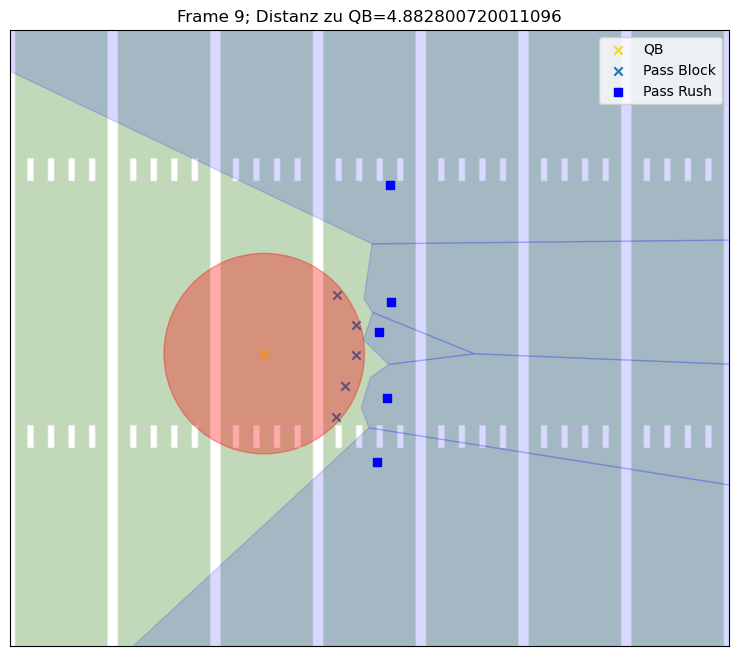

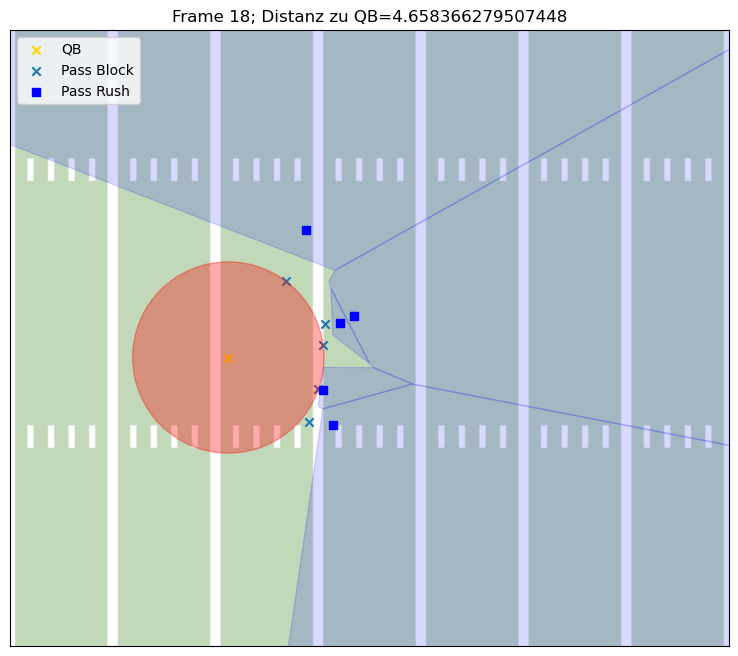

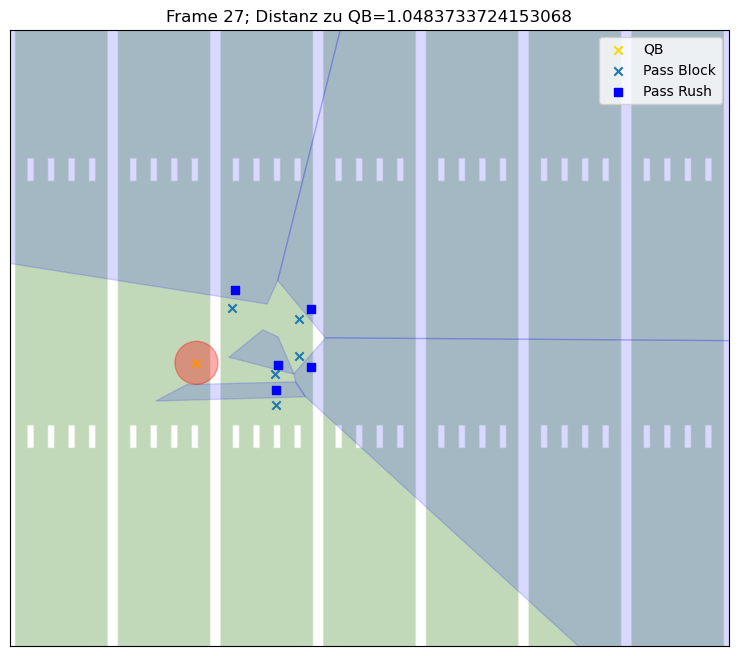

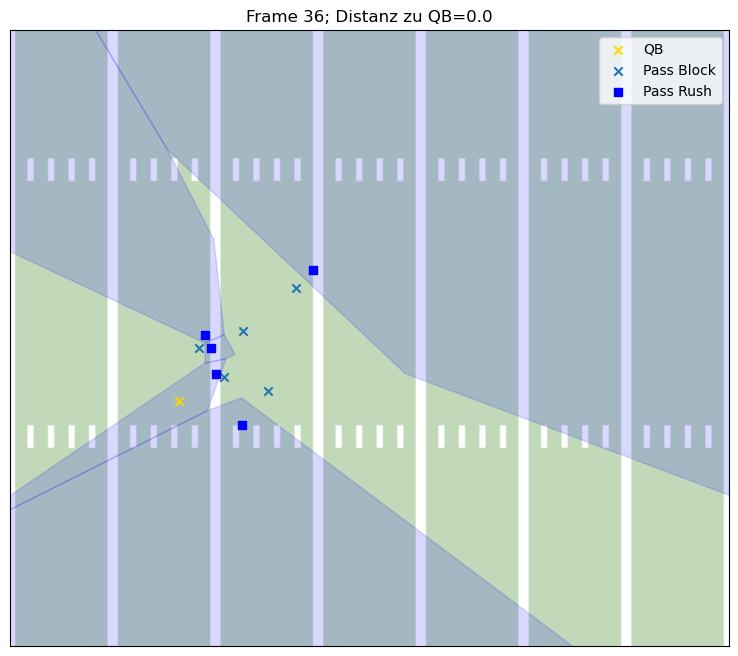

In [14]:
gameId = 2021090900
playId = 97

pdf = week_wscout[
    (week_wscout.gameId == gameId)
    & (week_wscout.playId == playId)
    & (week_wscout.pff_role.isin(["Pass", "Pass Rush", "Pass Block"]))
]

radii = []
pdists = []
for frameId in range(pdf.frameId.min(), pdf.frameId.max()):
    fdf = pdf[pdf.frameId == frameId]
    points = np.stack(
        [
            fdf[fdf.pff_role.isin(["Pass Block", "Pass Rush"])].x.to_numpy(),
            fdf[fdf.pff_role.isin(["Pass Block", "Pass Rush"])].y.to_numpy(),
        ],
        axis=-1,
    )

    # add dummy points for coloring
    points = np.append(
        points, [[999, 999], [-999, 999], [999, -999], [-999, -999]], axis=0
    )
    vor = Voronoi(points)
    # include dummy booleans for array shape to work
    def_line_regions = (
        fdf[fdf.pff_role.isin(["Pass Block", "Pass Rush"])].pff_role == "Pass Rush"
    ).to_numpy()
    regions = vor.point_region[np.concatenate([def_line_regions, [False] * 4])]

    def_pts = [[vor.vertices[vert] for vert in vor.regions[reg]] for reg in regions]
    def_pts = np.concatenate([np.stack(dpts, axis=0) for dpts in def_pts])

    def_polys = []
    for reg in regions:
        if len(vor.regions[reg]) > 2:
            def_polys.append(Polygon([vor.vertices[vert] for vert in vor.regions[reg]]))

    qb_coords = np.stack(
        [
            fdf[fdf.pff_role == "Pass"].x.to_numpy(),
            np.clip(fdf[fdf.pff_role == "Pass"].y.to_numpy(), 18, 35),
        ]
    ).T

    radius = distance.cdist(qb_coords, def_pts).min()
    qb_danger = def_line_regions[distance.cdist(qb_coords, points).argmin()]

    qb_pt = Point(qb_coords)
    polydist = min([poly.distance(qb_pt) for poly in def_polys])

    pdists.append(polydist)
    if qb_danger:
        radii.append(0.0)
    else:
        radii.append(radius)

    circle1 = plt.Circle(qb_coords[0] * 10, polydist * 10, color="r", alpha=0.33)

    if frameId % 9 == 0:
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.imshow(create_nfl_field(), alpha=0.3)
        # voronoi_plot_2d(vor, ax=ax)

        for reg in regions:
            ax.fill(
                [vor.vertices[vert][0] * 10 for vert in vor.regions[reg] if vert > -1],
                [vor.vertices[vert][1] * 10 for vert in vor.regions[reg] if vert > -1],
                alpha=0.15,
                color="blue",
            )

        ax.scatter(
            fdf[fdf.pff_role == "Pass"].x.to_numpy() * 10,
            fdf[fdf.pff_role == "Pass"].y.to_numpy() * 10,
            marker="x",
            label="QB",
            color="gold",
        )
        ax.scatter(
            fdf[fdf.pff_role == "Pass Block"].x.to_numpy() * 10,
            fdf[fdf.pff_role == "Pass Block"].y.to_numpy() * 10,
            marker="x",
            label="Pass Block",
        )
        ax.scatter(
            fdf[fdf.pff_role == "Pass Rush"].x.to_numpy() * 10,
            fdf[fdf.pff_role == "Pass Rush"].y.to_numpy() * 10,
            color="b",
            marker="s",
            label="Pass Rush",
        )
        ax.add_patch(circle1)
        plt.title(
            # f" frame {frameId}; radius: {radius:.4} yards; QB in danger: {qb_danger or radius<1.0}, polydist={polydist}"
            f"Frame {frameId}; Distanz zu QB={polydist}"
        )
        plt.xlim(250, 600)
        plt.ylim(100, 400)
        plt.xticks([])
        plt.yticks([])

        plt.legend()
        plt.show()

#### As we can see in the pictures, the dynamic of a collapsing pocket are represented in the Voronoi region. While Voronoi diagrams do not consider player speed or orientation, in this case this is a acceptable simplification as the players are not usually moving independently of each other but rather blockers try to get actively in the way of rushers leading to a dynamic where the main question is: can the blocker stay between the QB and the rusher. The Voronoi diagram maps this as "between" means closer -> Blocker is between iff the QB is in the blockers voronoi region rather than the rushers. 
#### If we check the history of the pocket size over the course of the play in the next plot, there is also an opportunity for more analysis in the temporal dynamics. 

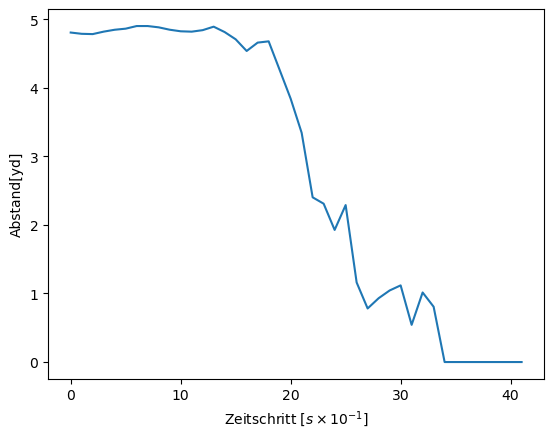

In [15]:
plt.plot(radii)
plt.xlabel(r"Zeitschritt [$s \times 10^{-1}$]")
plt.ylabel("Abstand[yd]")
plt.show()

In [16]:
if True:
    qb_spaces = pd.read_parquet("nfl-big-data-bowl-2023/qb_spaces_pre_noclip.parquet")
else:
    qb_spaces = (
        week_wscout[week_wscout.is_snapped == 1]
        .groupby(["gameId", "playId", "frameId"])
        .progress_apply(calc_qb_space)
        .reset_index()
    )
    qb_spaces["qb_radius"] = qb_spaces[0].progress_apply(lambda x: x["qb_radius"])
    qb_spaces["qb_danger"] = qb_spaces[0].progress_apply(lambda x: x["qb_danger"])
    qb_spaces["polydist"] = qb_spaces[0].progress_apply(lambda x: x["polydist"])
    qb_spaces = qb_spaces.drop(columns=0)
    qb_spaces.to_parquet("nfl-big-data-bowl-2023/qb_spaces_pre_noclip.parquet")

In [17]:
pass_abs_frames = (
    week_wscout[
        (week_wscout.event == "pass_forward")
        | ((week_wscout.event == "autoevent_passforward"))
    ]
    .drop_duplicates(["gameId", "playId"])[["gameId", "playId", "frameId"]]
    .rename(columns={"frameId": "pass_absolute_frame"})
)

In [18]:
poly_times = (
    qb_spaces.groupby(["gameId", "playId"])
    .apply(poly_frame)
    .reset_index()
    .rename(columns={0: "poly_frame"})
)

C:\Users\mschilling\AppData\Local\Temp\ipykernel_21088\550963575.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(poly_frame)


In [19]:
min_frames = (
    qb_spaces.groupby(["gameId", "playId"])
    .apply(min_frame)
    .reset_index()
    .rename(columns={0: "min_frame"})
)

C:\Users\mschilling\AppData\Local\Temp\ipykernel_21088\3324145867.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(min_frame)


In [20]:
pass_frames = (
    week_wscout.groupby(["gameId", "playId"])
    .apply(pass_frame)
    .reset_index()
    .rename(columns={0: "pass_frame"})
)

C:\Users\mschilling\AppData\Local\Temp\ipykernel_21088\652141453.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(pass_frame)


In [21]:
surv_time = (
    qb_spaces.groupby(["gameId", "playId"])
    .progress_apply(surv_frame)
    .reset_index()
    .rename(columns={0: "surv_frame"})
)

  0%|          | 0/8557 [00:00<?, ?it/s]

In [22]:
pwin = (
    qb_spaces.groupby(["gameId", "playId"])
    .progress_apply(pblockwin)
    .reset_index()
    .rename(columns={0: "p_blockwin"})
)

  0%|          | 0/8557 [00:00<?, ?it/s]

In [23]:
mean_polydists = (
    qb_spaces.groupby(["gameId", "playId"])
    .polydist.mean()
    .reset_index()
    .rename(columns={"polydist": "mean_polydists"})
)

In [24]:
plays_with_collapse = pd.merge(
    mean_polydists,
    plays[
        (plays.defendersInBox.between(4, 8))  ## pff true pass set
        & (plays.down < 4)
        & ~plays.offenseFormation.isin(["JUMBO", "WILDCAT"])
        & ~plays.dropBackType.isin(["DESIGNED_RUN", "UNKNOWN"])
    ][
        [
            "gameId",
            "playId",
            "playDescription",
            "pff_playAction",
            "passResult",
            "prePenaltyPlayResult",
            "defendersInBox",
            "personnelO",
            "personnelD",
            "dropBackType",
            "pff_passCoverage",
            "pff_passCoverageType",
            "offenseFormation",
            "yardsToGo",
            "down",
            "possessionTeam",
            "defensiveTeam",
            "ep",
            "epa",
            "qb_epa",
            "touchdown",
            "air_yards",
        ]
    ],
    how="inner",
    on=["gameId", "playId"],
)

In [ ]:
plays_with_collapse["complete"] = plays_with_collapse.passResult == "C"
plays_with_collapse["incomplete"] = plays_with_collapse.passResult == "I"
plays_with_collapse["sack"] = plays_with_collapse.passResult == "S"

plays_with_collapse = plays_with_collapse.merge(
    pass_abs_frames, how="left", on=["gameId", "playId"]
)

plays_with_collapse = plays_with_collapse.merge(
    min_frames, how="left", on=["gameId", "playId"]
)

plays_with_collapse = plays_with_collapse.merge(
    poly_times, how="left", on=["gameId", "playId"]
)

plays_with_collapse = plays_with_collapse.merge(
    surv_time, how="left", on=["gameId", "playId"]
)

plays_with_collapse = plays_with_collapse.merge(
    pass_frames, how="left", on=["gameId", "playId"]
)

plays_with_collapse = pd.merge(
    plays_with_collapse,
    qb_spaces[["gameId", "playId", "frameId", "polydist", "qb_radius"]],
    left_on=["gameId", "playId", "pass_absolute_frame"],
    right_on=["gameId", "playId", "frameId"],
    how="left",
)

plays_with_collapse = plays_with_collapse.merge(pwin, on=["gameId", "playId"])

In [ ]:
max_frames = (
    qb_spaces.groupby(["gameId", "playId"])
    .frameId.max()
    .reset_index()
    .rename(columns={"frameId": "max_frame"})
)
plays_with_collapse = plays_with_collapse.merge(
    max_frames, on=["gameId", "playId"], how="left"
)

In [ ]:
plays_with_collapse["survived"] = (
    plays_with_collapse.poly_frame == -1
)  ## it survieved iff no collapse frame
plays_with_collapse["pass_thrown"] = plays_with_collapse.pass_frame > 0
plays_with_collapse["pocket_end_event"] = (
    1 - plays_with_collapse["survived"]
) | plays_with_collapse["pass_frame"].le(plays_with_collapse["surv_frame"])
plays_with_collapse["pocket_end"] = plays_with_collapse[
    ["surv_frame", "pass_frame"]
].min(axis=1)

plays_with_collapse["pocket_vol"] = (
    plays_with_collapse["mean_polydists"] * plays_with_collapse["surv_frame"]
)

In [ ]:
plays_with_collapse["down1"] = plays_with_collapse.down == 1
plays_with_collapse["down2"] = plays_with_collapse.down == 2
plays_with_collapse["down3"] = plays_with_collapse.down == 3
down_cols = ["down2", "down3"]
plays_with_collapse["zone"] = plays_with_collapse.pff_passCoverageType == "Zone"
plays_with_collapse["man"] = plays_with_collapse.pff_passCoverageType == "Man"
mz_cols = ["zone", "man"]
plays_with_collapse["Cover-3"] = plays_with_collapse.pff_passCoverage == "Cover-3"
plays_with_collapse["Cover-1"] = plays_with_collapse.pff_passCoverage == "Cover-1"
plays_with_collapse["Cover-2"] = plays_with_collapse.pff_passCoverage == "Cover-2"
plays_with_collapse["Quarters"] = plays_with_collapse.pff_passCoverage == "Quarters"
plays_with_collapse["Cover-6"] = plays_with_collapse.pff_passCoverage == "Cover-6"
plays_with_collapse["RedZone"] = plays_with_collapse.pff_passCoverage == "Red Zone"
plays_with_collapse["Cover-0"] = plays_with_collapse.pff_passCoverage == "Cover-0"
plays_with_collapse["2-Man"] = plays_with_collapse.pff_passCoverage == "2-Man"
def_cols = [
    "Cover-3",
    "Cover-1",
    "Cover-2",
    "Cover-6",
    "Quarters",
    "Cover-0",
    "2-Man",
    "RedZone",
]

In [ ]:
plays_with_collapse["shotgun"] = plays_with_collapse.offenseFormation == "SHOTGUN"
plays_with_collapse["empty"] = plays_with_collapse.offenseFormation == "EMPTY"
plays_with_collapse["singleback"] = plays_with_collapse.offenseFormation == "SINGLEBACK"
plays_with_collapse["iform"] = plays_with_collapse.offenseFormation == "I_FORM"
off_cols = [
    "shotgun",
    "empty",
    "singleback",
    "iform",
]

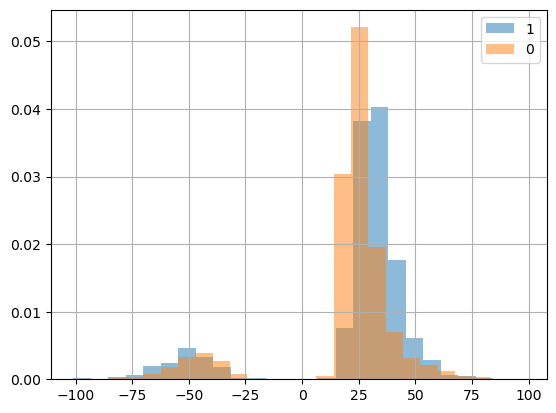

In [ ]:
plays_with_collapse[plays_with_collapse.pff_playAction == 1].pass_frame.hist(
    bins=25, alpha=0.5, density=True, label="1"
)
plays_with_collapse[plays_with_collapse.pff_playAction == 0].pass_frame.hist(
    bins=25, alpha=0.5, density=True, label="0"
)
plt.legend()
plt.show()

In [ ]:
plays_with_collapse["pass_frame"] = plays_with_collapse.pass_frame.abs()
plays_with_collapse["comp_air_yards"] = (
    plays_with_collapse.air_yards * plays_with_collapse.complete
)
plays_with_collapse["safe_pass"] = (
    plays_with_collapse.surv_frame > plays_with_collapse.pass_frame
)

# effect of pocket survival on play outcome

#### quick overview of correlations between pocket survival_frame and some play outcome measures

In [ ]:
plays_with_collapse.groupby("surv_frame").agg(
    sack=("sack", "mean"),
    epa=("epa", "mean"),
    comp_percentage=("complete", "mean"),
    ytg=("yardsToGo", "mean"),
).reset_index().corr()

,surv_frame,sack,epa,comp_percentage,ytg
surv_frame,1.000000,-0.465793,0.034267,-0.210061,0.188291
sack,-0.465793,1.000000,-0.039987,0.069100,-0.033642
epa,0.034267,-0.039987,1.000000,0.602567,0.018118
comp_percentage,-0.210061,0.069100,0.602567,1.000000,0.151237
ytg,0.188291,-0.033642,0.018118,0.151237,1.000000


#### is a "safe" pocket beneficial?

In [ ]:
# aggregating plays by survival frame (independent of pocket safety)
sagg = (
    plays_with_collapse.groupby("surv_frame")
    .agg(
        {
            "sack": ["mean"],
            "complete": ["mean"],
            "epa": ["mean", lambda df: df.quantile(0.05), lambda df: df.quantile(0.95)],
            "prePenaltyPlayResult": [
                "mean",
                lambda df: df.quantile(0.05),
                lambda df: df.quantile(0.95),
            ],
            "air_yards": [
                "mean",
                lambda df: df.quantile(0.05),
                lambda df: df.quantile(0.95),
            ],
            "comp_air_yards": [
                "mean",
                lambda df: df.quantile(0.05),
                lambda df: df.quantile(0.95),
            ],
        }
    )
    .reset_index()
)

# aggregating plays by survival frame (only passes from a safe pocket)
pass_surv_frame = (
    plays_with_collapse[
        (plays_with_collapse.surv_frame > plays_with_collapse.pass_frame)
        & plays_with_collapse.pass_thrown
    ]
    .groupby("surv_frame")
    .agg(
        {
            "sack": ["mean"],
            "complete": ["mean"],
            "epa": ["mean", lambda df: df.quantile(0.05), lambda df: df.quantile(0.95)],
            "prePenaltyPlayResult": [
                "mean",
                lambda df: df.quantile(0.05),
                lambda df: df.quantile(0.95),
            ],
            "air_yards": [
                "mean",
                lambda df: df.quantile(0.05),
                lambda df: df.quantile(0.95),
            ],
            "comp_air_yards": [
                "mean",
                lambda df: df.quantile(0.05),
                lambda df: df.quantile(0.95),
            ],
        }
    )
    .reset_index()
)

# aggregating plays by survival frame (excluding passes from a safe pocket)
pass_pressure_frame = (
    plays_with_collapse[
        ~(
            (plays_with_collapse.surv_frame > plays_with_collapse.pass_frame)
            & (plays_with_collapse.pass_thrown)
        )
    ]
    .groupby("surv_frame")
    .agg(
        {
            "sack": ["mean"],
            "complete": ["mean"],
            "epa": ["mean", lambda df: df.quantile(0.05), lambda df: df.quantile(0.95)],
            "prePenaltyPlayResult": [
                "mean",
                lambda df: df.quantile(0.05),
                lambda df: df.quantile(0.95),
            ],
            "air_yards": [
                "mean",
                lambda df: df.quantile(0.05),
                lambda df: df.quantile(0.95),
            ],
            "comp_air_yards": [
                "mean",
                lambda df: df.quantile(0.05),
                lambda df: df.quantile(0.95),
            ],
        }
    )
    .reset_index()
)

#### we exclude the shortest and longest 5 percent of plays, since there is not enough data per frame in those situations

In [34]:
p05 = plays_with_collapse["surv_frame"].quantile(0.05)
p95 = plays_with_collapse["surv_frame"].quantile(0.95)
print(f"considered play durations: {p05/10:.1f}s - {p95/10:.1f}s")

considered play durations: 1.7s - 4.1s


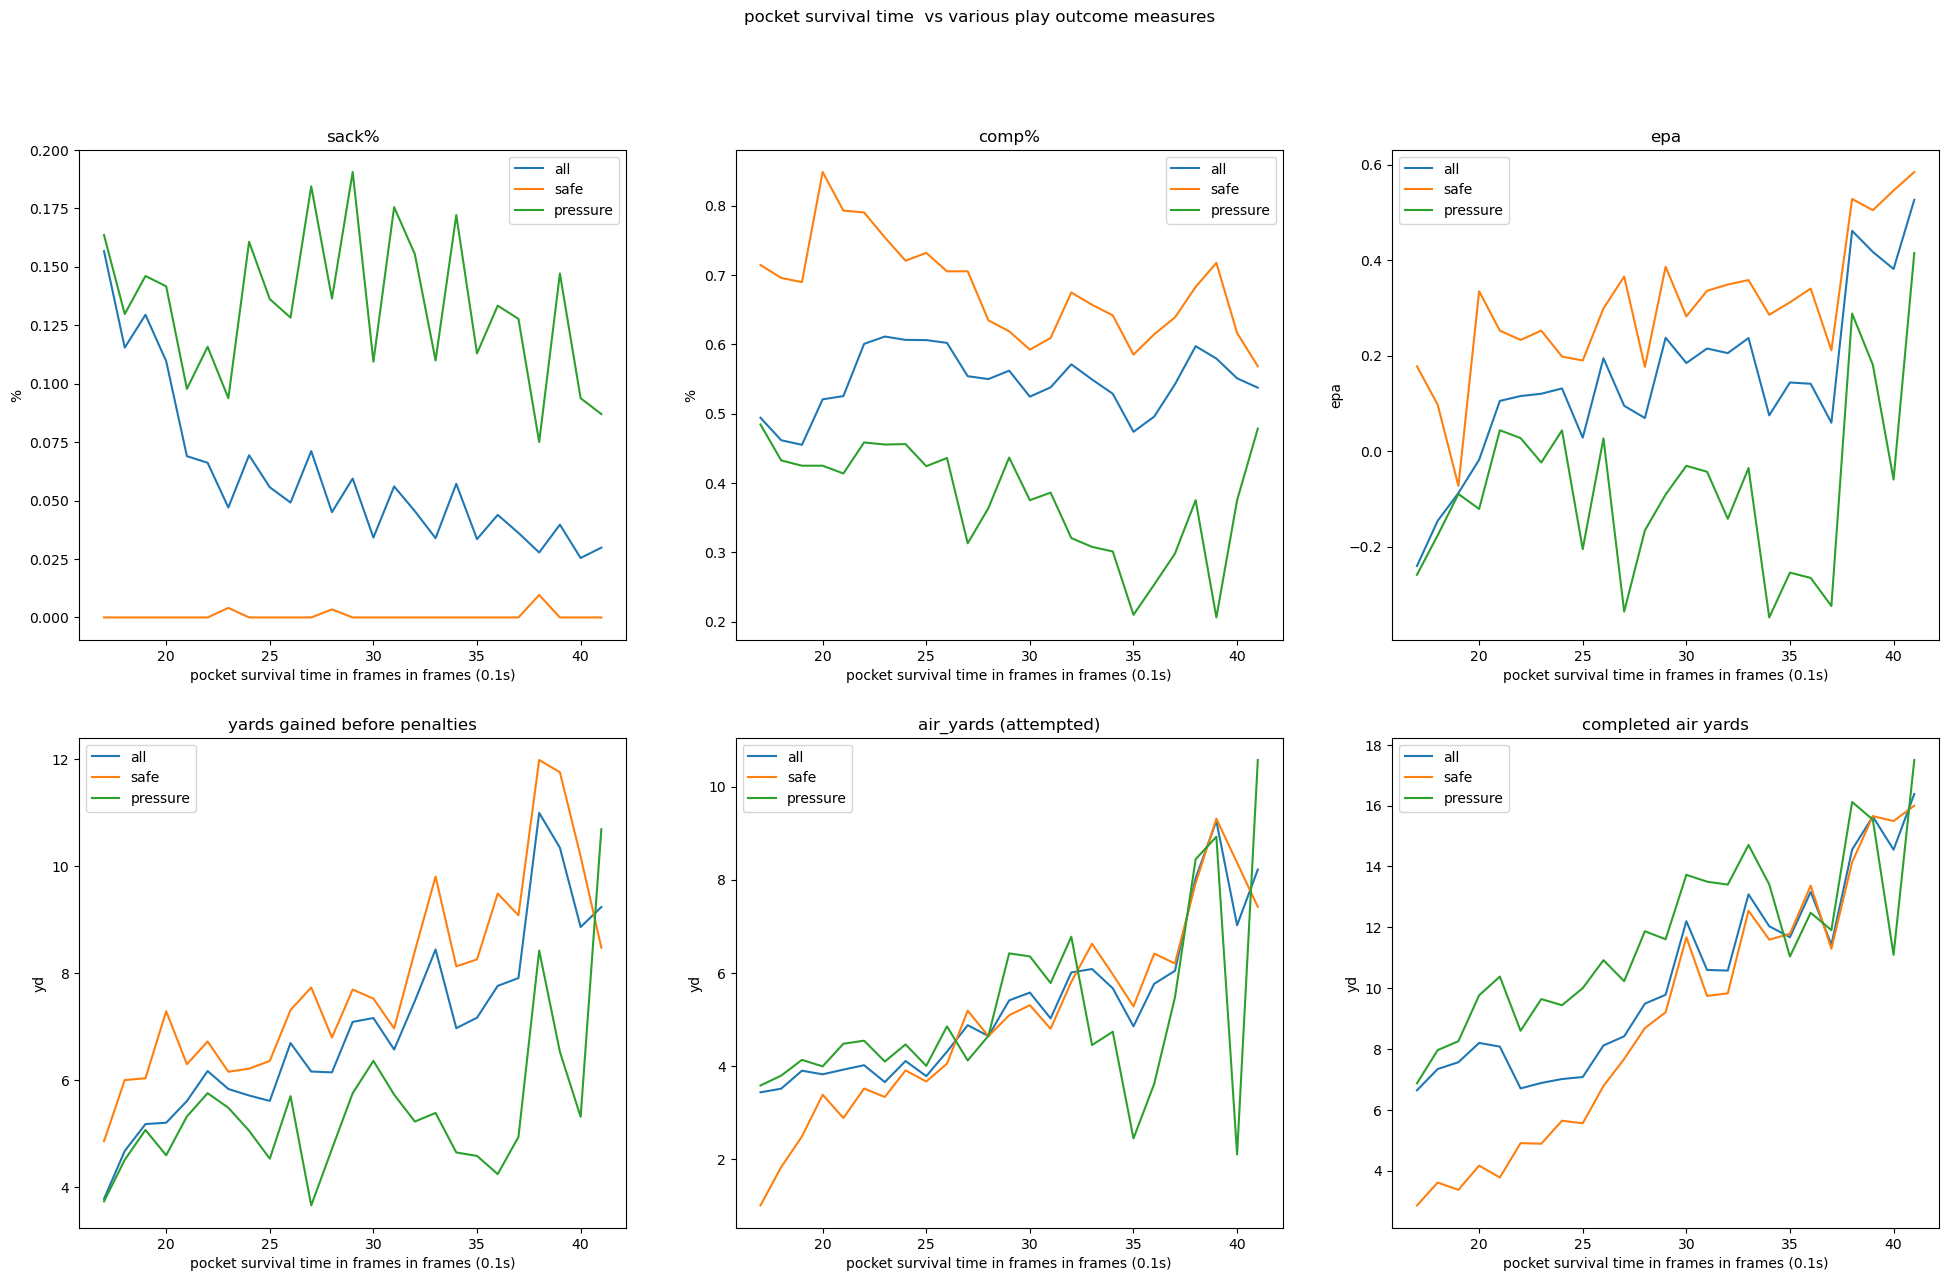

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(24, 14))
sagg[sagg.surv_frame.between(p05, p95)].plot(
    x="surv_frame", y=("sack", "mean"), ax=ax[0, 0], label="all"
)
pass_surv_frame[pass_surv_frame.surv_frame.between(p05, p95)].plot(
    x="surv_frame", y=("sack", "mean"), ax=ax[0, 0], label="safe"
)
pass_pressure_frame[pass_pressure_frame.surv_frame.between(p05, p95)].plot(
    x="surv_frame", y=("sack", "mean"), ax=ax[0, 0], label="pressure"
)
sagg[sagg.surv_frame.between(p05, p95)].plot(
    x="surv_frame", y=("complete", "mean"), ax=ax[0, 1], label="all"
)
pass_surv_frame[pass_surv_frame.surv_frame.between(p05, p95)].plot(
    x="surv_frame", y=("complete", "mean"), ax=ax[0, 1], label="safe"
)
pass_pressure_frame[pass_pressure_frame.surv_frame.between(p05, p95)].plot(
    x="surv_frame", y=("complete", "mean"), ax=ax[0, 1], label="pressure"
)
sagg[sagg.surv_frame.between(p05, p95)].plot(
    x="surv_frame", y=("epa", "mean"), ax=ax[0, 2], label="all"
)
pass_surv_frame[pass_surv_frame.surv_frame.between(p05, p95)].plot(
    x="surv_frame", y=("epa", "mean"), ax=ax[0, 2], label="safe"
)
pass_pressure_frame[pass_pressure_frame.surv_frame.between(p05, p95)].plot(
    x="surv_frame", y=("epa", "mean"), ax=ax[0, 2], label="pressure"
)


sagg[sagg.surv_frame.between(p05, p95)].plot(
    x="surv_frame", y=("prePenaltyPlayResult", "mean"), ax=ax[1, 0], label="all"
)
pass_surv_frame[pass_surv_frame.surv_frame.between(p05, p95)].plot(
    x="surv_frame", y=("prePenaltyPlayResult", "mean"), ax=ax[1, 0], label="safe"
)
pass_pressure_frame[pass_pressure_frame.surv_frame.between(p05, p95)].plot(
    x="surv_frame", y=("prePenaltyPlayResult", "mean"), ax=ax[1, 0], label="pressure"
)
sagg[sagg.surv_frame.between(p05, p95)].plot(
    x="surv_frame", y=("comp_air_yards", "mean"), ax=ax[1, 1], label="all"
)
pass_surv_frame[pass_surv_frame.surv_frame.between(p05, p95)].plot(
    x="surv_frame", y=("comp_air_yards", "mean"), ax=ax[1, 1], label="safe"
)
pass_pressure_frame[pass_pressure_frame.surv_frame.between(p05, p95)].plot(
    x="surv_frame", y=("comp_air_yards", "mean"), ax=ax[1, 1], label="pressure"
)

sagg[sagg.surv_frame.between(p05, p95)].plot(
    x="surv_frame", y=("air_yards", "mean"), ax=ax[1, 2], label="all"
)
pass_surv_frame[pass_surv_frame.surv_frame.between(p05, p95)].plot(
    x="surv_frame", y=("air_yards", "mean"), ax=ax[1, 2], label="safe"
)
pass_pressure_frame[pass_pressure_frame.surv_frame.between(p05, p95)].plot(
    x="surv_frame", y=("air_yards", "mean"), ax=ax[1, 2], label="pressure"
)

plt.suptitle("pocket survival time  vs various play outcome measures")

ax[0, 0].set_title("sack%")
ax[0, 0].set_ylabel("%")
ax[0, 0].set_xlabel("pocket survival time in frames in frames (0.1s)")
ax[0, 1].set_title("comp%")
ax[0, 1].set_ylabel("%")
ax[0, 1].set_xlabel("pocket survival time in frames in frames (0.1s)")
ax[0, 2].set_title("epa")
ax[0, 2].set_ylabel("epa")
ax[0, 2].set_xlabel("pocket survival time in frames in frames (0.1s)")
ax[1, 0].set_title("yards gained before penalties")
ax[1, 0].set_ylabel("yd")
ax[1, 0].set_xlabel("pocket survival time in frames in frames (0.1s)")
ax[1, 1].set_title("air_yards (attempted)")
ax[1, 1].set_ylabel("yd")
ax[1, 1].set_xlabel("pocket survival time in frames in frames (0.1s)")
ax[1, 2].set_title("completed air yards")
ax[1, 2].set_ylabel("yd")
ax[1, 2].set_xlabel("pocket survival time in frames in frames (0.1s)")
plt.legend(loc="upper left")
plt.show()

## we can graphically see, that passes from a safe pocket seems to be better than froma collapsed on. But are these differences significant?

In [ ]:
sdf = plays_with_collapse[
    plays_with_collapse.surv_frame > plays_with_collapse.pass_frame
]
pressdf = plays_with_collapse[
    plays_with_collapse.surv_frame <= plays_with_collapse.pass_frame
]
nopassdf = plays_with_collapse[~plays_with_collapse.pass_thrown]

In [37]:
print(stats.mannwhitneyu(sdf.epa, pressdf.epa).pvalue)
print(stats.mannwhitneyu(sdf.sack, pressdf.sack).pvalue)
print(stats.mannwhitneyu(sdf.complete, pressdf.complete).pvalue)
print(stats.mannwhitneyu(sdf.prePenaltyPlayResult, pressdf.prePenaltyPlayResult).pvalue)

7.055409085341786e-52
1.4457465893786036e-135
5.629256227573882e-138
2.1606620812309775e-70


## Yes, for completion percentage, sack rate, epa and prePenaltyPlayResult, the differenes are significant (and better for safe pockets)

### effect of mean pocket size on play outcome

#### we use two measures of pocket size: _mean pocket size_, a time independent version, and _pocket volume ~ mean pocket size * safe pocket duration_ which combines the time independent measure with the survival duration to take both how long and how big the pocket was into account

In [38]:
plays_with_collapse.loc[
    (plays_with_collapse.surv_frame.between(17, 41)),
    [
        "surv_frame",
        "mean_polydists",
        "pocket_vol",
        "polydist",
        "sack",
        "complete",
        "epa",
        "prePenaltyPlayResult",
        "yardsToGo",
    ],
].corr()

,surv_frame,mean_polydists,pocket_vol,polydist,sack,complete,epa,prePenaltyPlayResult,yardsToGo
surv_frame,1.000000,0.266277,0.695491,0.140003,-0.087519,0.000375,0.060958,0.115937,0.064697
mean_polydists,0.266277,1.000000,0.859888,0.713991,-0.306681,0.243268,0.129950,0.137611,0.016171
pocket_vol,0.695491,0.859888,1.000000,0.587924,-0.265051,0.173579,0.130187,0.166484,0.052301
polydist,0.140003,0.713991,0.587924,1.000000,-0.052318,0.158853,0.056355,0.037459,0.003083
sack,-0.087519,-0.306681,-0.265051,-0.052318,1.000000,-0.282243,-0.290899,-0.342466,-0.001767
complete,0.000375,0.243268,0.173579,0.158853,-0.282243,1.000000,0.542989,0.602272,0.028768
epa,0.060958,0.129950,0.130187,0.056355,-0.290899,0.542989,1.000000,0.713128,-0.019208
prePenaltyPlayResult,0.115937,0.137611,0.166484,0.037459,-0.342466,0.602272,0.713128,1.000000,0.029141
yardsToGo,0.064697,0.016171,0.052301,0.003083,-0.001767,0.028768,-0.019208,0.029141,1.000000


#### looking at pocket volume and pocket size, wee see clear patterns. First of all, there seems to be only very rarely a volume over 200 pocket vol or 5 mean pocket size. Furthermore we see that the overall features are split into larger and safe versions, smaller and pressure version and especially no pass situations seem to occur on lower volume, smaller pockets. no pass and pressure pass are much more similar between each other than towards safe passes 

In [39]:
sdf.columns

Index(['gameId', 'playId', 'mean_polydists', 'playDescription',
       'pff_playAction', 'passResult', 'prePenaltyPlayResult',
       'defendersInBox', 'personnelO', 'personnelD', 'dropBackType',
       'pff_passCoverage', 'pff_passCoverageType', 'offenseFormation',
       'yardsToGo', 'down', 'possessionTeam', 'defensiveTeam', 'ep', 'epa',
       'qb_epa', 'touchdown', 'air_yards', 'complete', 'incomplete', 'sack',
       'pass_absolute_frame', 'min_frame', 'poly_frame', 'surv_frame',
       'pass_frame', 'frameId', 'polydist', 'qb_radius', 'p_blockwin',
       'max_frame', 'survived', 'pass_thrown', 'pocket_end_event',
       'pocket_end', 'pocket_vol', 'down1', 'down2', 'down3', 'zone', 'man',
       'Cover-3', 'Cover-1', 'Cover-2', 'Quarters', 'Cover-6', 'RedZone',
       'Cover-0', '2-Man', 'shotgun', 'empty', 'singleback', 'iform',
       'comp_air_yards', 'safe_pass'],
      dtype='object')

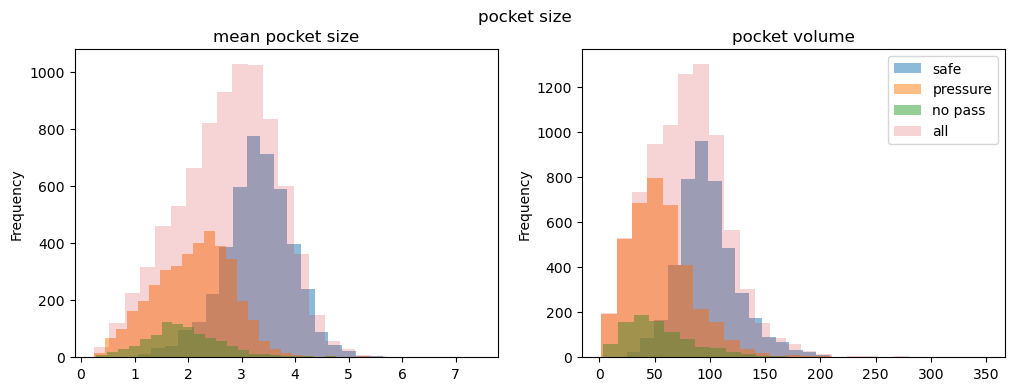

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sdf.mean_polydists.plot.hist(bins=25, alpha=0.5, label="safe", ax=ax[0])
pressdf.mean_polydists.plot.hist(bins=25, alpha=0.5, label="pressure", ax=ax[0])
nopassdf.mean_polydists.plot.hist(bins=25, alpha=0.5, label="no pass", ax=ax[0])
plays_with_collapse.mean_polydists.plot.hist(bins=25, alpha=0.2, label="all", ax=ax[0])
ax[0].set_title("mean pocket size")

sdf.pocket_vol.plot.hist(bins=25, alpha=0.5, label="safe", ax=ax[1])
pressdf.pocket_vol.plot.hist(bins=25, alpha=0.5, label="pressure", ax=ax[1])
nopassdf.pocket_vol.plot.hist(bins=25, alpha=0.5, label="no pass", ax=ax[1])
plays_with_collapse.pocket_vol.plot.hist(bins=25, alpha=0.2, label="all", ax=ax[1])
ax[1].set_title("pocket volume")

plt.suptitle("pocket size")
plt.legend()
plt.show()

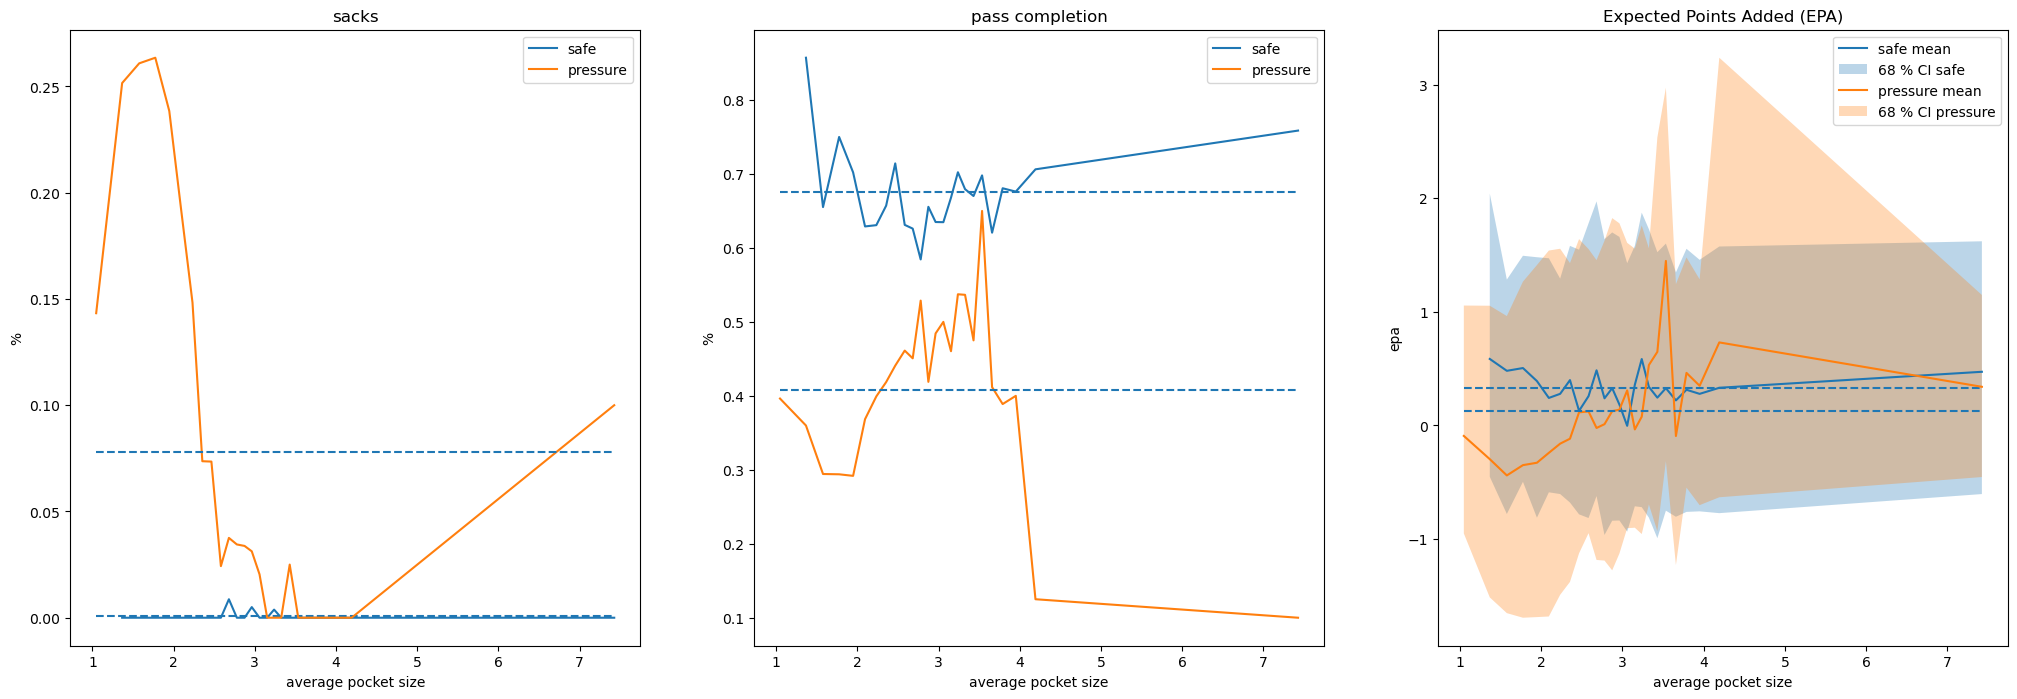

In [41]:
fig, ax = plt.subplots(1, 3, figsize=(25, 8))

sdf = plays_with_collapse[plays_with_collapse.safe_pass]
pressdf = plays_with_collapse[~plays_with_collapse.safe_pass]
cats, bins = pd.qcut(plays_with_collapse.mean_polydists, 25, retbins=True)
for idf, lbl in zip([sdf, pressdf], ["safe", "pressure"]):
    cats, bins = pd.cut(idf.mean_polydists, bins, retbins=True)
    mpd = plays_with_collapse.groupby(cats, observed=False)[
        ["sack", "complete", "epa"]
    ].mean()
    mpd05 = plays_with_collapse.groupby(cats, observed=False)[["epa"]].quantile(0.16)
    mpd95 = plays_with_collapse.groupby(cats, observed=False)[["epa"]].quantile(0.84)

    ax[0].plot(bins[1:], mpd.sack, label=lbl)
    ax[0].hlines([np.mean(mpd.sack)], xmin=bins[1], xmax=bins[-1], linestyle="dashed")
    ax[1].plot(bins[1:], mpd.complete, label=lbl)
    ax[1].hlines(
        [np.mean(mpd.complete)], xmin=bins[1], xmax=bins[-1], linestyle="dashed"
    )
    ax[2].plot(bins[1:], mpd.epa, label=f"{lbl} mean")
    ax[2].hlines([np.mean(mpd.epa)], xmin=bins[1], xmax=bins[-1], linestyle="dashed")
    ax[2].fill_between(
        bins[1:], mpd05.epa, mpd95.epa, label=f"68 % CI {lbl}", alpha=0.3
    )

ax[0].set_title("sacks")
ax[0].set_ylabel("%")
ax[0].set_xlabel("average pocket size")
ax[1].set_title("pass completion")
ax[1].set_ylabel("%")
ax[1].set_xlabel("average pocket size")
ax[2].set_ylabel("epa")
ax[2].set_xlabel("average pocket size")
ax[2].set_title("Expected Points Added (EPA)")
ax[0].legend()
ax[1].legend()
ax[2].legend()
plt.show()

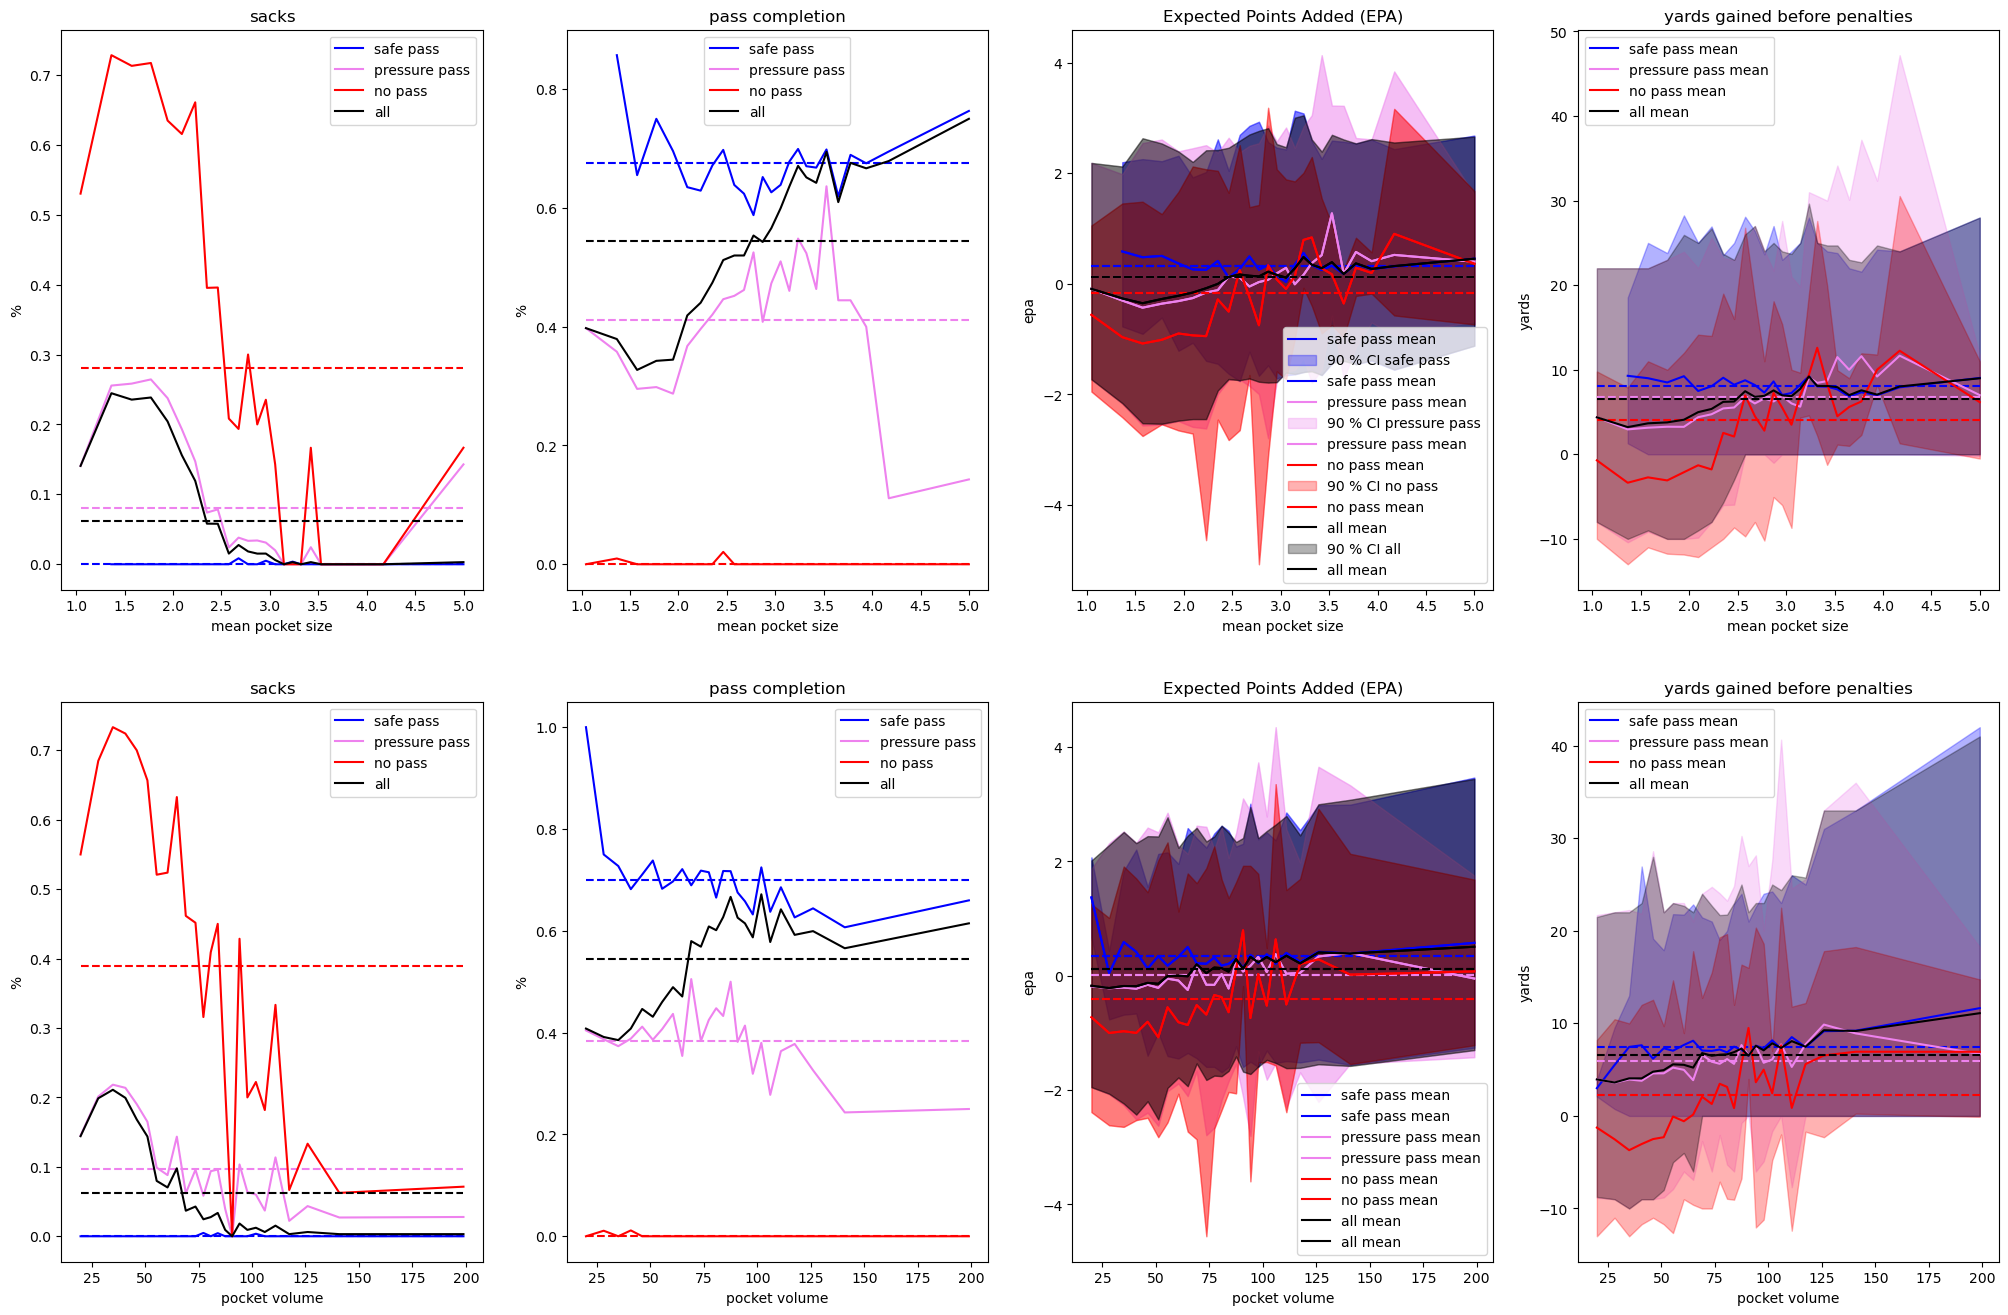

In [ ]:
# based on the histogram, we set an upper threshold to 200 pocket volume
thrs = 200

# threshold for mean pocket size is set to 5
thrsd = 5

fig, ax = plt.subplots(2, 4, figsize=(25, 16))

vol_cats, vol_bins = pd.qcut(
    plays_with_collapse[plays_with_collapse.pocket_vol.le(thrs)].pocket_vol,
    25,
    retbins=True,
)

cats, bins = pd.qcut(
    plays_with_collapse[plays_with_collapse.mean_polydists.le(thrsd)].mean_polydists,
    25,
    retbins=True,
)

for idf, lbl, c in zip(
    [sdf, pressdf, nopassdf, plays_with_collapse],
    ["safe pass", "pressure pass", "no pass", "all"],
    ["blue", "violet", "red", "black"],
):
    # mean pocket size
    cats = pd.cut(idf[idf.mean_polydists.le(thrsd)].mean_polydists, bins, retbins=False)
    mpd = (
        idf[idf.mean_polydists.le(thrsd)]
        .groupby(cats, observed=False)[
            ["sack", "complete", "epa", "prePenaltyPlayResult"]
        ]
        .mean()
    )
    mpd05 = (
        idf[idf.mean_polydists.le(thrsd)]
        .groupby(cats, observed=False)[["epa", "prePenaltyPlayResult"]]
        .quantile(0.05)
    )
    mpd95 = (
        idf[idf.mean_polydists.le(thrsd)]
        .groupby(cats, observed=False)[["epa", "prePenaltyPlayResult"]]
        .quantile(0.95)
    )

    ax[0, 0].plot(bins[1:], mpd.sack, label=lbl, color=c)
    ax[0, 0].hlines(
        [np.mean(mpd.sack)],
        xmin=bins[1],
        xmax=bins[-1],
        linestyle="dashed",
        color=c,
    )

    ax[0, 1].plot(bins[1:], mpd.complete, label=lbl, color=c)
    ax[0, 1].hlines(
        [np.mean(mpd.complete)],
        xmin=bins[1],
        xmax=bins[-1],
        linestyle="dashed",
        color=c,
    )

    ax[0, 2].plot(bins[1:], mpd.epa, label=f"{lbl} mean", color=c)
    ax[0, 2].hlines(
        [np.mean(mpd.epa)],
        xmin=bins[1],
        xmax=bins[-1],
        linestyle="dashed",
        color=c,
    )
    ax[0, 2].fill_between(
        bins[1:], mpd05.epa, mpd95.epa, label=f"90 % CI {lbl}", alpha=0.3, color=c
    )

    ax[0, 2].plot(bins[1:], mpd.epa, label=f"{lbl} mean", color=c)
    ax[0, 2].hlines(
        [np.mean(mpd.epa)],
        xmin=bins[1],
        xmax=bins[-1],
        linestyle="dashed",
        color=c,
    )
    ax[0, 2].fill_between(bins[1:], mpd05.epa, mpd95.epa, alpha=0.3, color=c)

    ax[0, 3].plot(bins[1:], mpd.prePenaltyPlayResult, label=f"{lbl} mean", color=c)
    ax[0, 3].hlines(
        [np.mean(mpd.prePenaltyPlayResult)],
        xmin=bins[1],
        xmax=bins[-1],
        linestyle="dashed",
        color=c,
    )
    ax[0, 3].fill_between(
        bins[1:],
        mpd05.prePenaltyPlayResult,
        mpd95.prePenaltyPlayResult,
        alpha=0.3,
        color=c,
    )

    # pocket volume
    vol_cats = pd.cut(idf[idf.pocket_vol.le(thrs)].pocket_vol, vol_bins, retbins=False)
    vmpd = (
        idf[idf.pocket_vol.le(thrs)]
        .groupby(vol_cats, observed=True)[
            ["sack", "complete", "epa", "prePenaltyPlayResult"]
        ]
        .mean()
    )
    vmpd05 = (
        idf[idf.pocket_vol.le(thrs)]
        .groupby(vol_cats, observed=True)[["epa", "prePenaltyPlayResult"]]
        .quantile(0.05)
    )
    vmpd95 = (
        idf[idf.pocket_vol.le(thrs)]
        .groupby(vol_cats, observed=True)[["epa", "prePenaltyPlayResult"]]
        .quantile(0.95)
    )

    ax[1, 0].plot(vol_bins[1:], vmpd.sack, label=lbl, color=c)
    ax[1, 0].hlines(
        [np.mean(vmpd.sack)],
        xmin=vol_bins[1],
        xmax=vol_bins[-1],
        linestyle="dashed",
        color=c,
    )

    ax[1, 1].plot(vol_bins[1:], vmpd.complete, label=lbl, color=c)
    ax[1, 1].hlines(
        [np.mean(vmpd.complete)],
        xmin=vol_bins[1],
        xmax=vol_bins[-1],
        linestyle="dashed",
        color=c,
    )

    ax[1, 2].plot(vol_bins[1:], vmpd.epa, label=f"{lbl} mean", color=c)
    ax[1, 2].hlines(
        [np.mean(vmpd.epa)],
        xmin=vol_bins[1],
        xmax=vol_bins[-1],
        linestyle="dashed",
        color=c,
    )
    ax[1, 2].fill_between(vol_bins[1:], vmpd05.epa, vmpd95.epa, alpha=0.3, color=c)

    ax[1, 2].plot(vol_bins[1:], vmpd.epa, label=f"{lbl} mean", color=c)
    ax[1, 2].hlines(
        [np.mean(vmpd.epa)],
        xmin=vol_bins[1],
        xmax=vol_bins[-1],
        linestyle="dashed",
        color=c,
    )
    ax[1, 2].fill_between(vol_bins[1:], vmpd05.epa, vmpd95.epa, alpha=0.3, color=c)

    ax[1, 3].plot(vol_bins[1:], vmpd.prePenaltyPlayResult, label=f"{lbl} mean", color=c)
    ax[1, 3].hlines(
        [np.mean(vmpd.prePenaltyPlayResult)],
        xmin=vol_bins[1],
        xmax=vol_bins[-1],
        linestyle="dashed",
        color=c,
    )
    ax[1, 3].fill_between(
        vol_bins[1:],
        vmpd05.prePenaltyPlayResult,
        vmpd95.prePenaltyPlayResult,
        alpha=0.3,
        color=c,
    )

ax[0, 0].set_title("sacks")
ax[0, 0].set_ylabel("%")
ax[0, 0].set_xlabel("mean pocket size")
ax[0, 1].set_title("pass completion")
ax[0, 1].set_ylabel("%")
ax[0, 1].set_xlabel("mean pocket size")
ax[0, 2].set_ylabel("epa")
ax[0, 2].set_xlabel("mean pocket size")
ax[0, 2].set_title("Expected Points Added (EPA)")
ax[0, 3].set_title("yards gained before penalties")
ax[0, 3].set_xlabel("mean pocket size")
ax[0, 3].set_ylabel("yards")
ax[0, 0].legend()
ax[0, 1].legend()
ax[0, 2].legend()
ax[0, 3].legend()

ax[1, 0].set_title("sacks")
ax[1, 0].set_ylabel("%")
ax[1, 0].set_xlabel("pocket volume")
ax[1, 1].set_title("pass completion")
ax[1, 1].set_ylabel("%")
ax[1, 1].set_xlabel("pocket volume")
ax[1, 2].set_ylabel("epa")
ax[1, 2].set_xlabel("pocket volume")
ax[1, 2].set_title("Expected Points Added (EPA)")
ax[1, 3].set_title("yards gained before penalties")
ax[1, 3].set_xlabel("pocket volume")
ax[1, 3].set_ylabel("yards")
ax[1, 0].legend()
ax[1, 1].legend()
ax[1, 2].legend()
ax[1, 3].legend()
plt.show()

In [ ]:
# testing survival frame:

print("pvalue", stats.mannwhitneyu(sdf.epa, pressdf.epa).pvalue)
print(
    "pvalue",
    stats.chi2_contingency(
        [
            [sdf.complete.sum(), len(sdf) - sdf.complete.sum()],
            [pressdf.complete.sum(), len(pressdf) - pressdf.complete.sum()],
        ]
    ).pvalue,
)
print(
    "pvalue",
    stats.chi2_contingency(
        [
            [sdf.sack.sum(), len(sdf) - sdf.sack.sum()],
            [pressdf.sack.sum(), len(pressdf) - pressdf.sack.sum()],
        ]
    ).pvalue,
)
p_vals = np.ones(43)
p_vals1 = np.ones(43)
p_vals2 = np.ones(43)
for sf in trange(1, 43):
    spi = sdf[sdf.surv_frame == sf]
    ppi = pressdf[pressdf.surv_frame == sf]
    _, pv = stats.mannwhitneyu(spi.epa, ppi.epa)
    if (
        np.array(
            [
                [spi.complete.sum(), len(spi) - spi.complete.sum()],
                [ppi.complete.sum(), len(ppi) - ppi.complete.sum()],
            ]
        )
        < 1
    ).any():
        pc1 = 2
    else:
        _, pc1, _, _ = stats.chi2_contingency(
            [
                [spi.complete.sum(), len(spi) - spi.complete.sum()],
                [ppi.complete.sum(), len(ppi) - ppi.complete.sum()],
            ]
        )

    if (
        np.array(
            [
                [spi.sack.sum(), len(spi) - spi.sack.sum()],
                [ppi.sack.sum(), len(ppi) - ppi.sack.sum()],
            ]
        )
        < 1
    ).any():
        pc2 = 2
    else:
        _, pc2, _, _ = stats.chi2_contingency(
            [
                [spi.sack.sum(), len(spi) - spi.sack.sum()],
                [ppi.sack.sum(), len(ppi) - ppi.sack.sum()],
            ]
        )
    if not np.isnan(pv):
        p_vals[sf] = pv
    if not np.isnan(pc1):
        p_vals1[sf] = pc1
    if not np.isnan(pc2):
        p_vals2[sf] = pc2

pvalue 7.055409085341786e-52
pvalue 9.450405867075952e-138
pvalue 4.334562698569275e-135


  0%|          | 0/42 [00:00<?, ?it/s]

C:\Users\mschilling\AppData\Local\Temp\ipykernel_21088\3644523075.py:12: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, pv = stats.mannwhitneyu(spi.epa, ppi.epa)


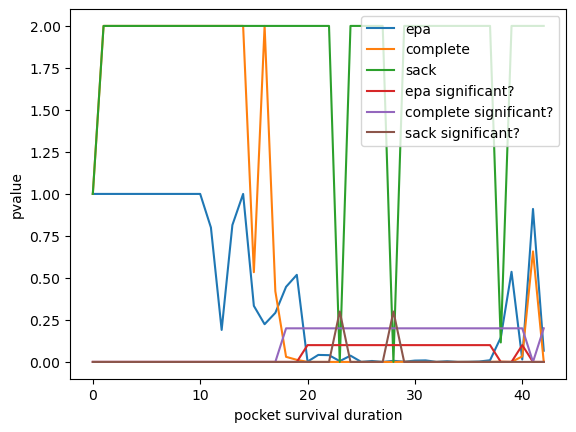

In [44]:
plt.plot(p_vals, label="epa")
plt.plot(p_vals1, label="complete")
plt.plot(p_vals2, label="sack")
plt.plot((p_vals < 0.05) * 0.1, label="epa significant?")
plt.plot((p_vals1 < 0.05) * 0.2, label="complete significant?")
plt.plot((p_vals2 < 0.05) * 0.3, label="sack significant?")
plt.xlabel("pocket survival duration")
plt.ylabel("pvalue")
plt.legend(loc="upper right")
plt.show()

### when correcting for survival frame, we can see significant differentes for completion and epa especially in the range f 19-41, which is where 90% of plays happen. sacks are mostly not occuring for safe passes, so we cannot properly test the difference, as indicated by the pvalue 2. 

pvalue 7.055409085341786e-52
pvalue 9.450405867075952e-138
pvalue 4.334562698569275e-135


  0%|          | 0/24 [00:00<?, ?it/s]

C:\Users\mschilling\AppData\Local\Temp\ipykernel_21088\963208824.py:34: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, pv = stats.mannwhitneyu(spi.epa, ppi.epa)


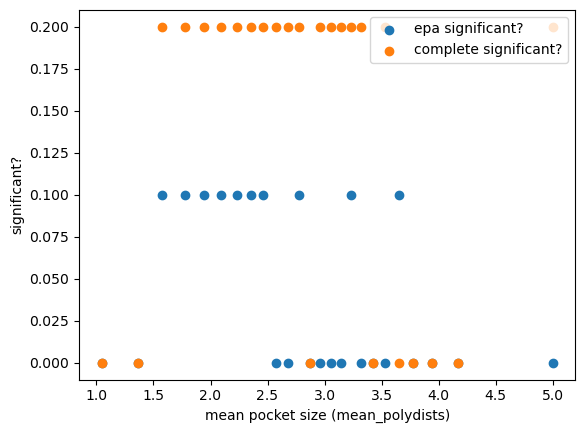

In [45]:
# testing pocket vol:
sdf = plays_with_collapse[
    plays_with_collapse.surv_frame > plays_with_collapse.pass_frame
]
pressdf = plays_with_collapse[
    ~(plays_with_collapse.surv_frame > plays_with_collapse.pass_frame)
]

print("pvalue", stats.mannwhitneyu(sdf.epa, pressdf.epa).pvalue)
print(
    "pvalue",
    stats.chi2_contingency(
        [
            [sdf.complete.sum(), len(sdf) - sdf.complete.sum()],
            [pressdf.complete.sum(), len(pressdf) - pressdf.complete.sum()],
        ]
    ).pvalue,
)
print(
    "pvalue",
    stats.chi2_contingency(
        [
            [sdf.sack.sum(), len(sdf) - sdf.sack.sum()],
            [pressdf.sack.sum(), len(pressdf) - pressdf.sack.sum()],
        ]
    ).pvalue,
)
p_vals = np.ones(25)
p_vals1 = np.ones(25)
p_vals2 = np.ones(25)
for i in trange(1, 25):
    spi = sdf[sdf.mean_polydists.between(bins[i - 1], bins[i])]
    ppi = pressdf[pressdf.mean_polydists.between(bins[i - 1], bins[i])]
    _, pv = stats.mannwhitneyu(spi.epa, ppi.epa)
    if (
        np.array(
            [
                [spi.complete.sum(), len(spi) - spi.complete.sum()],
                [ppi.complete.sum(), len(ppi) - ppi.complete.sum()],
            ]
        )
        < 1
    ).any():
        pc1 = 2
    else:
        _, pc1, _, _ = stats.chi2_contingency(
            [
                [spi.complete.sum(), len(spi) - spi.complete.sum()],
                [ppi.complete.sum(), len(ppi) - ppi.complete.sum()],
            ]
        )

    if (
        np.array(
            [
                [spi.sack.sum(), len(spi) - spi.sack.sum()],
                [ppi.sack.sum(), len(ppi) - ppi.sack.sum()],
            ]
        )
        < 1
    ).any():
        pc2 = 2
    else:
        _, pc2, _, _ = stats.chi2_contingency(
            [
                [spi.sack.sum(), len(spi) - spi.sack.sum()],
                [ppi.sack.sum(), len(ppi) - ppi.sack.sum()],
            ]
        )
    if not np.isnan(pv):
        p_vals[i] = pv
    if not np.isnan(pc1):
        p_vals1[i] = pc1
    if not np.isnan(pc2):
        p_vals2[i] = pc2

# plt.plot(p_vals, label="epa")
# plt.plot(p_vals1, label="complete")
# plt.plot(p_vals2, label="sack")
plt.scatter(bins[1:], (p_vals < 0.05) * 0.1, label="epa significant?")
plt.scatter(bins[1:], (p_vals1 < 0.05) * 0.2, label="complete significant?")
# plt.plot((p_vals2<0.05)*0.3, label="sack significant?")
plt.xlabel("mean pocket size (mean_polydists)")
plt.ylabel("significant?")
plt.legend(loc="upper right")
plt.show()

### there seems to be a significant difference between safe and non safe passes for pocket size 

pvalue 7.055409085341786e-52
pvalue 9.450405867075952e-138
pvalue 4.334562698569275e-135


  0%|          | 0/24 [00:00<?, ?it/s]

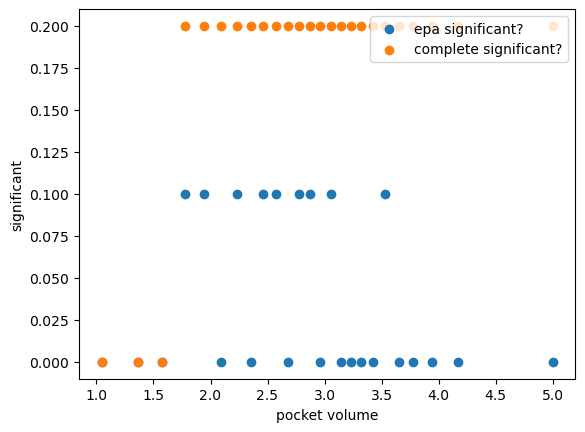

In [46]:
# testing pocket vol:
sdf = plays_with_collapse[
    plays_with_collapse.surv_frame > plays_with_collapse.pass_frame
]
pressdf = plays_with_collapse[
    ~(plays_with_collapse.surv_frame > plays_with_collapse.pass_frame)
]

print("pvalue", stats.mannwhitneyu(sdf.epa, pressdf.epa).pvalue)
print(
    "pvalue",
    stats.chi2_contingency(
        [
            [sdf.complete.sum(), len(sdf) - sdf.complete.sum()],
            [pressdf.complete.sum(), len(pressdf) - pressdf.complete.sum()],
        ]
    ).pvalue,
)
print(
    "pvalue",
    stats.chi2_contingency(
        [
            [sdf.sack.sum(), len(sdf) - sdf.sack.sum()],
            [pressdf.sack.sum(), len(pressdf) - pressdf.sack.sum()],
        ]
    ).pvalue,
)
p_vals = np.ones(25)
p_vals1 = np.ones(25)
p_vals2 = np.ones(25)
for i in trange(1, 25):
    spi = sdf[sdf.pocket_vol.between(vol_bins[i - 1], vol_bins[i])]
    ppi = pressdf[pressdf.pocket_vol.between(vol_bins[i - 1], vol_bins[i])]
    _, pv = stats.mannwhitneyu(spi.epa, ppi.epa)
    if (
        np.array(
            [
                [spi.complete.sum(), len(spi) - spi.complete.sum()],
                [ppi.complete.sum(), len(ppi) - ppi.complete.sum()],
            ]
        )
        < 1
    ).any():
        pc1 = 2
    else:
        _, pc1, _, _ = stats.chi2_contingency(
            [
                [spi.complete.sum(), len(spi) - spi.complete.sum()],
                [ppi.complete.sum(), len(ppi) - ppi.complete.sum()],
            ]
        )

    if (
        np.array(
            [
                [spi.sack.sum(), len(spi) - spi.sack.sum()],
                [ppi.sack.sum(), len(ppi) - ppi.sack.sum()],
            ]
        )
        < 1
    ).any():
        pc2 = 2
    else:
        _, pc2, _, _ = stats.chi2_contingency(
            [
                [spi.sack.sum(), len(spi) - spi.sack.sum()],
                [ppi.sack.sum(), len(ppi) - ppi.sack.sum()],
            ]
        )
    if not np.isnan(pv):
        p_vals[i] = pv
    if not np.isnan(pc1):
        p_vals1[i] = pc1
    if not np.isnan(pc2):
        p_vals2[i] = pc2

# plt.plot(p_vals, label="epa")
# plt.plot(p_vals1, label="complete")
# plt.plot(p_vals2, label="sack")
plt.scatter(bins[1:], (p_vals < 0.05) * 0.1, label="epa significant?")
plt.scatter(bins[1:], (p_vals1 < 0.05) * 0.2, label="complete significant?")
# plt.plot((p_vals2<0.05)*0.3, label="sack significant?")
plt.xlabel("pocket volume")
plt.ylabel("significant")
plt.legend(loc="upper right")
plt.show()

### pocket volume has significant effect on completion percentage as well as to a lesser degree epa

#### wee see, that there is a clear difference for sacks and comp percentage, but the CI for EPA is too large, suggesting that while there is a clear difference between safe passes and others for some target variables, epa is depending on other stuff as well. As a sanity check, we observe that sacks don't happen on large pockets and whenever there is a pass, there is no sack and when there is no pass, the completion percentage is 0. 

In [ ]:
features = [
    "max_frame",
    "surv_frame",
    "mean_polydists",
    "safe_pass",
    "survived",
    "pocket_vol",
]
targets = ["complete", "sack", "epa", "prePenaltyPlayResult"]
models = [
    LogisticRegression,
    LogisticRegression,
    LinearRegression,
    LinearRegression,
]
subsets = [
    [],
    ["max_frame"],
    ["surv_frame"],
    ["mean_polydists"],
    ["pocket_vol"],
    ["max_frame", "safe_pass"],
    ["surv_frame", "safe_pass"],
    ["surv_frame", "mean_polydists"],
    ["surv_frame", "safe_pass", "mean_polydists"],
    ["max_frame", "safe_pass", "pocket_vol"],
    ["max_frame", "mean_polydists", "surv_frame", "safe_pass"],
]

In [ ]:
aux_features = [
    "defendersInBox",
    "pff_playAction",
    "possessionTeam",
]

In [49]:
plays_with_collapse.pff_passCoverage.value_counts()

pff_passCoverage
Cover-3          2593
Cover-1          1928
Cover-2          1061
Quarters         1006
Cover-6           796
Red Zone          342
Cover-0           229
2-Man             190
Bracket            42
Prevent             9
Miscellaneous       8
Name: count, dtype: int64

### we fit some linear models (logistic regression for binary targets, linear for continuous) to see how the features are connected to the outcomes

In [ ]:
acc = []
for i in trange(100):
    X = pd.get_dummies(
        plays_with_collapse[
            ["max_frame", "mean_polydists", "surv_frame", "safe_pass"] + aux_features
        ],
        columns=["possessionTeam"],
    )

    X[
        [
            "max_frame",
            "mean_polydists",
            "surv_frame",
        ]
    ] = (
        X[
            [
                "max_frame",
                "mean_polydists",
                "surv_frame",
            ]
        ]
        - X[
            [
                "max_frame",
                "mean_polydists",
                "surv_frame",
            ]
        ].mean()
    ) / X[
        [
            "max_frame",
            "mean_polydists",
            "surv_frame",
        ]
    ].std()

    y = plays_with_collapse["prePenaltyPlayResult"]
    X_train, X_test, y_train, y_test = train_test_split(X.index, y, test_size=0.2)
    # scaler = StandardScaler()
    # scaler.fit(X.iloc[X_train])
    # Xs = scaler.transform(X.iloc[X_train])
    # Xts = scaler.transform(X.iloc[X_test])

    pocket_cushion = LinearRegression()
    pocket_cushion.fit(X=X.iloc[X_train], y=y_train)

    acc.append(pocket_cushion.score(X=X.iloc[X_test], y=y_test))

print("target: prePenaltyPlayResult")
print(f"mean R²: {np.mean(acc)}, std: {np.std(acc)}")
print(
    plays_with_collapse[
        [
            "max_frame",
            "mean_polydists",
            "surv_frame",
        ]
    ].std()
)
print(
    "coefficients:",
    {
        t: float(c)
        for c, t in zip(
            np.stack(pocket_cushion.coef_),
            ["max_frame", "mean_polydists", "surv_frame", "safe_pass"]
            + aux_features[:-1]
            + [
                "ARI",
                "ATL",
                "BAL",
                "BUF",
                "CAR",
                "CHI",
                "CIN",
                "CLE",
                "DAL",
                "DEN",
                "DET",
                "GB",
                "HOU",
                "IND",
                "JAX",
                "KC",
                "LA",
                "LAC",
                "LV",
                "MIA",
                "MIN",
                "NE",
                "NO",
                "NYG",
                "NYJ",
                "PHI",
                "PIT",
                "SEA",
                "SF",
                "TB",
                "TEN",
                "WAS",
            ],
        )
    },
)

  0%|          | 0/100 [00:00<?, ?it/s]

target: prePenaltyPlayResult
mean R²: 0.03803520901501496, std: 0.01234613282406979
max_frame         12.446334
mean_polydists     0.905516
surv_frame         7.627351
dtype: float64
coefficients: {'max_frame': -0.49593269802500756, 'mean_polydists': 1.0253708490430677, 'surv_frame': 0.7493316361445413, 'safe_pass': 1.0786015307074441, 'defendersInBox': -0.12484900055953871, 'pff_playAction': 3.07498108810307, 'ARI': -0.359772084992026, 'ATL': -0.019372660404609266, 'BAL': 0.4950164688367594, 'BUF': 0.7326713664156449, 'CAR': -0.812409558039984, 'CHI': -2.095019186549774, 'CIN': 1.397806213859495, 'CLE': -0.578090856555665, 'DAL': 1.518746133047608, 'DEN': -0.01775707264856936, 'DET': -0.8118554511897313, 'GB': -0.1649193532781713, 'HOU': -0.023967198587464517, 'IND': -0.4426528852804921, 'JAX': -0.5056537496055702, 'KC': 0.5314938460844767, 'LA': 1.188584525288805, 'LAC': -0.23736800398236585, 'LV': 1.5725222426773815, 'MIA': -1.0928993603059798, 'MIN': 0.7288843559119663, 'NE': -0.10

In [ ]:
acc = []
for i in trange(100):
    X = pd.get_dummies(
        plays_with_collapse[
            ["max_frame", "mean_polydists", "surv_frame", "safe_pass"] + aux_features
        ],
        columns=["possessionTeam"],
    )

    y = plays_with_collapse["epa"]
    X_train, X_test, y_train, y_test = train_test_split(X.index, y, test_size=0.2)
    scaler = StandardScaler()
    scaler.fit(X.iloc[X_train])
    Xs = scaler.transform(X.iloc[X_train])
    Xts = scaler.transform(X.iloc[X_test])
    # Xs = X.iloc[X_train]
    # Xts = X.iloc[X_test]

    pocket_cushion = LinearRegression()
    pocket_cushion.fit(X=Xs, y=y_train)

    acc.append(pocket_cushion.score(X=Xts, y=y_test))

print("target: EPA")
print(f"mean R²: {np.mean(acc)}, std: {np.std(acc)}")
print(
    plays_with_collapse[
        [
            "max_frame",
            "mean_polydists",
            "surv_frame",
        ]
    ].std()
)
print(
    "coefficients:",
    {
        t: float(c)
        for c, t in zip(
            np.stack(pocket_cushion.coef_),
            ["max_frame", "mean_polydists", "surv_frame", "safe_pass"]
            + aux_features[:-1]
            + [
                "ARI",
                "ATL",
                "BAL",
                "BUF",
                "CAR",
                "CHI",
                "CIN",
                "CLE",
                "DAL",
                "DEN",
                "DET",
                "GB",
                "HOU",
                "IND",
                "JAX",
                "KC",
                "LA",
                "LAC",
                "LV",
                "MIA",
                "MIN",
                "NE",
                "NO",
                "NYG",
                "NYJ",
                "PHI",
                "PIT",
                "SEA",
                "SF",
                "TB",
                "TEN",
                "WAS",
            ],
        )
    },
)

  0%|          | 0/100 [00:00<?, ?it/s]

target: EPA
mean R²: 0.022638988397551393, std: 0.008432270364798196
max_frame         12.446334
mean_polydists     0.905516
surv_frame         7.627351
dtype: float64
coefficients: {'max_frame': -0.07076346171694817, 'mean_polydists': 0.14562815624570177, 'surv_frame': 0.032347726662961776, 'safe_pass': 0.07416582688530637, 'defendersInBox': 0.012996487781237619, 'pff_playAction': 0.12157930086187597, 'ARI': 0.01037714707592327, 'ATL': -0.008938513207112312, 'BAL': 0.01734057179575739, 'BUF': 0.027800672106346434, 'CAR': -0.018054365505803964, 'CHI': -0.002455302120339471, 'CIN': 0.01597814037254326, 'CLE': -0.017774922412510556, 'DAL': 0.03195621017581738, 'DEN': 0.0012777439346236643, 'DET': -0.037571293521260415, 'GB': 0.011665774446135811, 'HOU': -0.014171982868022067, 'IND': 0.00791066978281926, 'JAX': -0.02897161239245384, 'KC': 0.0035732819996731136, 'LA': 0.0302202678252185, 'LAC': 0.007734917587923096, 'LV': 0.03706879010351157, 'MIA': -0.029939203369269276, 'MIN': 0.02295989

In [ ]:
model_results = []
num_feat = [
    "max_frame",
    "surv_frame",
    "mean_polydists",
    "pocket_vol",
]

for tgt, modl in zip(targets, models):
    for feature_set in tqdm(subsets[1:]):
        acc = []
        aics = []
        coefs = []
        intercpts = []
        X = pd.get_dummies(
            plays_with_collapse[feature_set + aux_features], columns=["possessionTeam"]
        )
        y = plays_with_collapse[tgt].to_numpy(dtype="float32")
        for i in range(100):
            numeric_features = list(set(num_feat).intersection(feature_set))
            X[numeric_features] = (
                X[numeric_features] - X[numeric_features].mean()
            ) / X[numeric_features].std()

            X_train, X_test, y_train, y_test = train_test_split(
                X.index, y, test_size=0.2
            )

            Xs = X.iloc[X_train]
            Xts = X.iloc[X_test]

            if tgt in ["complete", "sack"]:
                pocket_cushion = modl(class_weight="balanced", max_iter=1000)
            else:
                pocket_cushion = modl()

            pocket_cushion.fit(X=Xs, y=y_train)

            acc.append(pocket_cushion.score(X=Xts, y=y_test))
            aics.append(
                calc_aic(
                    y_test,
                    Xts,
                    pocket_cushion.predict(Xts),
                    len(pocket_cushion.coef_) + 1,
                )
            )
            coefs.append(pocket_cushion.coef_)
            intercpts.append(pocket_cushion.intercept_)
        model_results.append(
            {
                "model": type(pocket_cushion).__name__,
                "target": tgt,
                "features": feature_set,
                "aic": np.round(np.mean(aics), 5),
                "score_mean": np.round(np.mean(acc), 3),
                "score_std": np.round(np.std(acc), 3),
                "coef": [np.round(f, decimals=5) for f in np.mean(coefs, axis=0)],
                "interc": np.round(np.mean(intercpts), 5),
                "max_frame": "max_frame" in feature_set,
                "surv_frame": "surv_frame" in feature_set,
                "mean_polydists": "mean_polydists" in feature_set,
                "safe_pass": "safe_pass" in feature_set,
                "survived": "survived" in feature_set,
                "pocket_vol": "pocket_vol" in feature_set,
            }
        )

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [53]:
print(
    f"baseline: comp% {plays_with_collapse.complete.mean():.5f}, sack% {plays_with_collapse.sack.mean():.5f}, mean epa {plays_with_collapse.epa.mean():.5f}, mean pppr {plays_with_collapse.prePenaltyPlayResult.mean():.5f}"
)

baseline: comp% 0.54473, sack% 0.06229, mean epa 0.12259, mean pppr 6.57838


In [54]:
resdf = pd.DataFrame(model_results).sort_values("aic")
resdf.head()

,model,target,features,aic,score_mean,score_std,coef,interc,max_frame,surv_frame,mean_polydists,safe_pass,survived,pocket_vol
10,LogisticRegression,sack,[max_frame],2011.57104,0.801,0.009,"[[1.46709, 0.02965, -0.53934, 0.39852, -0.1836...",-0.68298,True,False,False,False,False,False
16,LogisticRegression,sack,"[surv_frame, mean_polydists]",2152.92204,0.783,0.010,"[[0.34923, -2.45039, -0.23203, -1.43304, 1.406...",0.19165,False,True,True,False,False,False
19,LogisticRegression,sack,"[max_frame, mean_polydists, surv_frame, safe_p...",2161.74853,0.782,0.010,"[[0.46813, -1.40817, 0.13884, -3.47854, -0.105...",0.19940,True,True,True,True,False,False
12,LogisticRegression,sack,[mean_polydists],2172.12839,0.780,0.010,"[[-2.24207, -0.23974, -1.24149, 1.46187, -0.40...",0.29495,False,False,True,False,False,False
18,LogisticRegression,sack,"[max_frame, safe_pass, pocket_vol]",2216.35592,0.774,0.011,"[[0.91143, -3.46039, -0.9526, -0.04858, -0.826...",-0.02635,True,False,False,True,False,True


In [55]:
resdf[resdf.target == "complete"].head()

,model,target,features,aic,score_mean,score_std,coef,interc,max_frame,surv_frame,mean_polydists,safe_pass,survived,pocket_vol
4,LogisticRegression,complete,"[max_frame, safe_pass]",2926.86677,0.652,0.010,"[[-0.53569, 0.76406, -0.10431, 0.53255, 0.0371...",0.08131,True,False,False,True,False,False
8,LogisticRegression,complete,"[max_frame, safe_pass, pocket_vol]",2934.29433,0.651,0.010,"[[-0.57626, 0.63847, 0.08797, -0.09555, 0.5463...",0.08750,True,False,False,True,False,True
9,LogisticRegression,complete,"[max_frame, mean_polydists, surv_frame, safe_p...",2969.91999,0.643,0.012,"[[-0.39644, 0.24552, -0.12234, 0.66246, -0.083...",-0.00639,True,True,True,True,False,False
5,LogisticRegression,complete,"[surv_frame, safe_pass]",2985.05782,0.640,0.011,"[[-0.26651, 1.35361, -0.09824, 0.44491, -0.025...",-0.22589,False,True,False,True,False,False
7,LogisticRegression,complete,"[surv_frame, safe_pass, mean_polydists]",3015.60313,0.633,0.011,"[[-0.34165, 0.91286, 0.40058, -0.07244, 0.6553...",-0.19410,False,True,True,True,False,False


In [56]:
resdf[resdf.target == "epa"].sort_values("score_mean", ascending=False).head()

,model,target,features,aic,score_mean,score_std,coef,interc,max_frame,surv_frame,mean_polydists,safe_pass,survived,pocket_vol
28,LinearRegression,epa,"[max_frame, safe_pass, pocket_vol]",6145.44455,0.023,0.009,"[-0.11013, 0.16358, 0.15124, 0.01635, 0.22327,...",-0.11392,True,False,False,True,False,True
27,LinearRegression,epa,"[surv_frame, safe_pass, mean_polydists]",6124.76097,0.022,0.008,"[-0.00245, 0.20507, 0.18278, 0.02203, 0.27605,...",-0.18381,False,True,True,True,False,False
29,LinearRegression,epa,"[max_frame, mean_polydists, surv_frame, safe_p...",6139.56995,0.022,0.008,"[-0.07245, 0.15657, 0.03755, 0.15204, 0.02074,...",-0.14545,True,True,True,True,False,False
22,LinearRegression,epa,[mean_polydists],6150.12915,0.022,0.007,"[0.25357, 0.03035, 0.28313, 0.02588, 0.01337, ...",-0.12335,False,False,True,False,False,False
26,LinearRegression,epa,"[surv_frame, mean_polydists]",6144.17042,0.019,0.008,"[0.005, 0.25404, 0.03142, 0.28106, 0.0175, 0.0...",-0.13192,False,True,True,False,False,False


In [ ]:
resdf[resdf.target == "prePenaltyPlayResult"].sort_values(
    "score_mean", ascending=False
).head()

,model,target,features,aic,score_mean,score_std,coef,interc,max_frame,surv_frame,mean_polydists,safe_pass,survived,pocket_vol
38,LinearRegression,prePenaltyPlayResult,"[max_frame, safe_pass, pocket_vol]",12280.95567,0.042,0.011,"[-0.58917, 0.90121, 1.55995, -0.11974, 2.66752...",6.19895,True,False,False,True,False,True
39,LinearRegression,prePenaltyPlayResult,"[max_frame, mean_polydists, surv_frame, safe_p...",12251.49763,0.039,0.012,"[-0.60832, 1.00977, 0.90668, 0.88928, -0.11328...",6.15502,True,True,True,True,False,False
37,LinearRegression,prePenaltyPlayResult,"[surv_frame, safe_pass, mean_polydists]",12281.00862,0.038,0.011,"[0.56173, 1.32201, 1.24317, -0.11405, 2.8494, ...",5.89915,False,True,True,True,False,False
36,LinearRegression,prePenaltyPlayResult,"[surv_frame, mean_polydists]",12288.30677,0.037,0.010,"[0.62053, 1.68216, -0.05548, 2.85753, -0.19589...",6.24703,False,True,True,False,False,False
33,LinearRegression,prePenaltyPlayResult,[pocket_vol],12304.56567,0.035,0.011,"[1.86302, -0.06789, 2.24653, -0.0985, 0.07906,...",6.46209,False,False,False,False,False,True


### so we can connect the various features to the play outcomes, however: our models show that pocket size or duration only accounts for a small portion of the play outcome, which can be expected given the complexity of the sport and different pieces involved. We only use a small number of game situation aspects in these models, such as a  play_action flag, as play action tends to make a large difference in outcome: 

In [58]:
plays_with_collapse.groupby("pff_playAction").epa.mean()

pff_playAction
0    0.095539
1    0.208725
Name: epa, dtype: float64

### looking at the correlation betweeen featuers and outcomes, we can see that there is some correlation but mostly it is on the weaker side (i.e. sacks are predicted by pocket size and survival duration) 

In [ ]:
plays_with_collapse[
    [
        "polydist",
        "surv_frame",
        "max_frame",
        "mean_polydists",
        "survived",
        "pocket_vol",
        "pff_playAction",
        "epa",
        "sack",
    ]
].corr()

,polydist,surv_frame,max_frame,mean_polydists,survived,pocket_vol,pff_playAction,epa,sack
polydist,1.000000,0.152689,-0.322699,0.708692,0.734418,0.553603,-0.078853,0.070251,-0.051799
surv_frame,0.152689,1.000000,0.344129,0.308704,0.247966,0.762851,0.090897,0.060220,-0.081041
max_frame,-0.322699,0.344129,1.000000,-0.431238,-0.376774,-0.069223,0.192342,-0.088195,0.267852
mean_polydists,0.708692,0.308704,-0.431238,1.000000,0.620703,0.821284,-0.317150,0.135203,-0.293782
survived,0.734418,0.247966,-0.376774,0.620703,1.000000,0.547675,-0.130705,0.105426,-0.213820
pocket_vol,0.553603,0.762851,-0.069223,0.821284,0.547675,1.000000,-0.117030,0.127178,-0.237272
pff_playAction,-0.078853,0.090897,0.192342,-0.317150,-0.130705,-0.117030,1.000000,0.031011,0.004560
epa,0.070251,0.060220,-0.088195,0.135203,0.105426,0.127178,0.031011,1.000000,-0.296354
sack,-0.051799,-0.081041,0.267852,-0.293782,-0.213820,-0.237272,0.004560,-0.296354,1.000000


In [ ]:
resdf[
    (resdf.target == "prePenaltyPlayResult")
    & (resdf.surv_frame)
    & (resdf.pocket_vol == False)
    & resdf.mean_polydists
]

,model,target,features,aic,score_mean,score_std,coef,interc,max_frame,surv_frame,mean_polydists,safe_pass,survived,pocket_vol
39,LinearRegression,prePenaltyPlayResult,"[max_frame, mean_polydists, surv_frame, safe_p...",12251.49763,0.039,0.012,"[-0.60832, 1.00977, 0.90668, 0.88928, -0.11328...",6.15502,True,True,True,True,False,False
37,LinearRegression,prePenaltyPlayResult,"[surv_frame, safe_pass, mean_polydists]",12281.00862,0.038,0.011,"[0.56173, 1.32201, 1.24317, -0.11405, 2.8494, ...",5.89915,False,True,True,True,False,False
36,LinearRegression,prePenaltyPlayResult,"[surv_frame, mean_polydists]",12288.30677,0.037,0.010,"[0.62053, 1.68216, -0.05548, 2.85753, -0.19589...",6.24703,False,True,True,False,False,False


In [ ]:
resdf[resdf.target == "prePenaltyPlayResult"].sort_values(
    "score_mean", ascending=False
).head(5)

,model,target,features,aic,score_mean,score_std,coef,interc,max_frame,surv_frame,mean_polydists,safe_pass,survived,pocket_vol
38,LinearRegression,prePenaltyPlayResult,"[max_frame, safe_pass, pocket_vol]",12280.95567,0.042,0.011,"[-0.58917, 0.90121, 1.55995, -0.11974, 2.66752...",6.19895,True,False,False,True,False,True
39,LinearRegression,prePenaltyPlayResult,"[max_frame, mean_polydists, surv_frame, safe_p...",12251.49763,0.039,0.012,"[-0.60832, 1.00977, 0.90668, 0.88928, -0.11328...",6.15502,True,True,True,True,False,False
37,LinearRegression,prePenaltyPlayResult,"[surv_frame, safe_pass, mean_polydists]",12281.00862,0.038,0.011,"[0.56173, 1.32201, 1.24317, -0.11405, 2.8494, ...",5.89915,False,True,True,True,False,False
36,LinearRegression,prePenaltyPlayResult,"[surv_frame, mean_polydists]",12288.30677,0.037,0.010,"[0.62053, 1.68216, -0.05548, 2.85753, -0.19589...",6.24703,False,True,True,False,False,False
33,LinearRegression,prePenaltyPlayResult,[pocket_vol],12304.56567,0.035,0.011,"[1.86302, -0.06789, 2.24653, -0.0985, 0.07906,...",6.46209,False,False,False,False,False,True


#### predicting play outcome based on the survival frame or pocket size can be visualized 

In [ ]:
px.scatter(
    plays_with_collapse, x="surv_frame", y="prePenaltyPlayResult", trendline="ols"
)

In [ ]:
px.scatter(
    plays_with_collapse,
    x="surv_frame",
    y="prePenaltyPlayResult",
    color="safe_pass",
    trendline="ols",
)

In [64]:
px.scatter(plays_with_collapse, x="mean_polydists", y="epa", trendline="ols")

#### 

#### overall difference between safe and non safe passes. What about if corrected for survival frame, mean pocket size and pocket volume?

## now that we showed the utility of pocket size, duration and survival for predicting play outcome as well as wether the pocket is intact at the time of the pass (if there is a pass) we can use this to perform further analysis 
### as an example: team differences 

#### correlations of different features _by offense/defense_ indicate actionable insights: 
##### Offense split

In [65]:
plays_with_collapse.loc[
    plays_with_collapse.surv_frame.between(p05, p95),
    [
        "sack",
        "complete",
        "epa",
        "polydist",
        "mean_polydists",
        "surv_frame",
        "pocket_vol",
        "prePenaltyPlayResult",
        "air_yards",
        "comp_air_yards",
    ],
].corr()

,sack,complete,epa,polydist,mean_polydists,surv_frame,pocket_vol,prePenaltyPlayResult,air_yards,comp_air_yards
sack,1.000000,-0.282243,-0.290899,-0.052318,-0.306681,-0.087519,-0.265051,-0.342466,NaN,NaN
complete,-0.282243,1.000000,0.542989,0.158853,0.243268,0.000375,0.173579,0.602272,-0.249574,0.485668
epa,-0.290899,0.542989,1.000000,0.056355,0.129950,0.060958,0.130187,0.713128,0.128240,0.672333
polydist,-0.052318,0.158853,0.056355,1.000000,0.713991,0.140003,0.587924,0.037459,-0.103979,0.003952
mean_polydists,-0.306681,0.243268,0.129950,0.713991,1.000000,0.266277,0.859888,0.137611,-0.044412,0.027515
surv_frame,-0.087519,0.000375,0.060958,0.140003,0.266277,1.000000,0.695491,0.115937,0.223000,0.137997
pocket_vol,-0.265051,0.173579,0.130187,0.587924,0.859888,0.695491,1.000000,0.166484,0.101685,0.102554
prePenaltyPlayResult,-0.342466,0.602272,0.713128,0.037459,0.137611,0.115937,0.166484,1.000000,0.285836,0.858112
air_yards,NaN,-0.249574,0.128240,-0.103979,-0.044412,0.223000,0.101685,0.285836,1.000000,0.454587
comp_air_yards,NaN,0.485668,0.672333,0.003952,0.027515,0.137997,0.102554,0.858112,0.454587,1.000000


In [ ]:
cdf = (
    plays_with_collapse.loc[
        plays_with_collapse.surv_frame.between(p05, p95),
        [
            "sack",
            "possessionTeam",
            "defendersInBox",
            "pff_playAction",
        ],
    ]
    .groupby(["possessionTeam", "defendersInBox", "pff_playAction"])
    .count()
    .reset_index()
)
cdf[cdf.possessionTeam.isin(["KC", "CLE", "PHI"])].rename(
    columns={"sack": "number_of_plays"}
)

,possessionTeam,defendersInBox,pff_playAction,number_of_plays
63,CLE,4.0,0,11
64,CLE,5.0,0,40
65,CLE,5.0,1,3
66,CLE,6.0,0,78
67,CLE,6.0,1,15
68,CLE,7.0,0,27
69,CLE,7.0,1,26
70,CLE,8.0,0,3
71,CLE,8.0,1,11
133,KC,4.0,0,43


In [ ]:
# correlation with surv_frame
cdf2 = (
    plays_with_collapse.loc[
        plays_with_collapse.surv_frame.between(p05, p95),
        [
            # "sack",
            # "complete",
            "epa",
            "polydist",
            "mean_polydists",
            "surv_frame",
            # "pocket_vol",
            "prePenaltyPlayResult",
            # "air_yards",
            "comp_air_yards",
            "possessionTeam",
            "defendersInBox",
            "pff_playAction",
        ],
    ]
    .groupby(["possessionTeam", "defendersInBox", "pff_playAction"])
    .progress_apply(
        lambda df: df.drop(
            columns=["possessionTeam", "epa", "defendersInBox", "pff_playAction"]
        ).corrwith(df.epa)
    )
    .reset_index()
    .dropna()
)
cdf2 = pd.merge(
    cdf2, cdf, on=["possessionTeam", "defendersInBox", "pff_playAction"], how="left"
)
print(
    cdf2[cdf2.possessionTeam.isin(["KC", "CLE", "PHI"]) & (cdf2.sack > 10)]
    .sort_values(["possessionTeam", "defendersInBox", "pff_playAction"])
    .to_markdown()
)

  0%|          | 0/281 [00:00<?, ?it/s]

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning:

Degrees of freedom <= 0 for slice

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning:

divide by zero encountered in divide

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning:

invalid value encountered in multiply

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning:

Degrees of freedom <= 0 for slice

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning:

divide by zero encountered in divide

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning:

invalid value encountered in multiply

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: Ru

|     | possessionTeam   |   defendersInBox |   pff_playAction |   polydist |   mean_polydists |   surv_frame |   prePenaltyPlayResult |   comp_air_yards |   sack |
|----:|:-----------------|-----------------:|-----------------:|-----------:|-----------------:|-------------:|-----------------------:|-----------------:|-------:|
|  51 | CLE              |                4 |                0 | -0.198095  |       -0.376025  |  -0.100322   |               0.908013 |         0.990491 |     11 |
|  52 | CLE              |                5 |                0 | -0.218462  |        0.0474629 |   0.0300391  |               0.799234 |         0.717615 |     40 |
|  54 | CLE              |                6 |                0 |  0.25897   |        0.443097  |   0.0214797  |               0.743266 |         0.748909 |     78 |
|  55 | CLE              |                6 |                1 |  0.251366  |        0.191981  |   0.00626296 |               0.213594 |        -0.109938 |     15 |
|  56 | CL

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning:

Degrees of freedom <= 0 for slice

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning:

divide by zero encountered in divide

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning:

invalid value encountered in multiply

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning:

invalid value encountered in divide

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning:

invalid value encountered in divide

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning:

Degrees of freedom <= 0 for slice

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: Runti

In [68]:
# correlation with surv_frame by offense
plays_with_collapse.loc[
    plays_with_collapse.surv_frame.between(p05, p95),
    [
        "sack",
        "complete",
        "epa",
        "polydist",
        "mean_polydists",
        "surv_frame",
        "pocket_vol",
        "prePenaltyPlayResult",
        "air_yards",
        "comp_air_yards",
        "possessionTeam",
    ],
].groupby("possessionTeam").progress_apply(
    lambda df: df.drop(columns=["possessionTeam", "surv_frame"]).corrwith(df.surv_frame)
).reset_index().sort_values(
    "epa"
)

  0%|          | 0/32 [00:00<?, ?it/s]

,possessionTeam,sack,complete,epa,polydist,mean_polydists,pocket_vol,prePenaltyPlayResult,air_yards,comp_air_yards
15,KC,-0.020612,-0.188374,-0.182602,0.026102,0.114967,0.632301,-0.043419,0.273763,-0.022435
14,JAX,0.006301,-0.081490,-0.143233,0.191651,0.333271,0.722677,-0.101180,0.057873,-0.073190
26,PIT,0.148088,-0.241033,-0.120902,0.097276,0.031315,0.672137,-0.012833,0.224338,0.103624
29,TB,-0.032604,-0.060305,-0.062895,0.055598,0.088311,0.657818,0.042150,0.289145,0.139910
22,NO,-0.035498,-0.029839,-0.034962,0.102777,0.216363,0.641677,0.130772,0.299187,0.126466
6,CIN,-0.136266,-0.036939,-0.029929,0.127112,0.295655,0.709770,-0.006245,0.090842,0.030940
12,HOU,-0.172223,-0.020631,-0.026344,0.112867,0.198869,0.660859,0.040807,0.249085,0.017657
8,DAL,-0.137876,0.031055,-0.010343,0.280550,0.368754,0.749568,0.063426,0.174430,0.078583
4,CAR,-0.041309,-0.133081,-0.005579,0.199958,0.326854,0.722039,-0.016582,0.190745,-0.019321
0,ARI,-0.068510,0.069037,0.048514,0.177559,0.394540,0.768735,0.095155,0.208863,0.077072


In [69]:
# correlation with surv_frame by defense
plays_with_collapse.loc[
    plays_with_collapse.surv_frame.between(p05, p95),
    [
        "sack",
        "complete",
        "epa",
        "polydist",
        "mean_polydists",
        "surv_frame",
        "pocket_vol",
        "prePenaltyPlayResult",
        "air_yards",
        "comp_air_yards",
        "defensiveTeam",
    ],
].groupby("defensiveTeam").progress_apply(
    lambda df: df.drop(columns=["defensiveTeam", "surv_frame"]).corrwith(df.surv_frame)
).reset_index().sort_values(
    "epa"
)

  0%|          | 0/32 [00:00<?, ?it/s]

,defensiveTeam,sack,complete,epa,polydist,mean_polydists,pocket_vol,prePenaltyPlayResult,air_yards,comp_air_yards
9,DEN,-0.083107,-0.053594,-0.052048,0.068297,0.188963,0.658338,0.052969,0.259422,0.084505
25,PHI,-0.149048,-0.114418,-0.050885,0.158532,0.167474,0.604028,0.009044,0.089779,-0.039090
31,WAS,-0.014477,-0.078783,-0.041481,0.077635,0.260816,0.686993,0.005169,0.229406,0.065022
3,BUF,-0.183748,-0.038430,-0.030753,0.145948,0.195695,0.664765,0.069321,0.180834,0.017639
30,TEN,-0.065135,-0.057165,-0.025575,0.167426,0.266868,0.672051,0.063375,0.201632,0.089108
22,NO,0.057312,-0.056499,-0.011224,0.073991,0.217165,0.680385,0.037903,0.149684,0.102399
12,HOU,-0.048102,0.014274,-0.007949,0.243131,0.428199,0.761022,0.090794,0.185874,0.130160
11,GB,-0.006952,-0.065826,-0.002954,-0.027587,0.149063,0.639992,-0.033105,0.246686,0.072017
18,LV,-0.082543,-0.016711,0.019348,0.150629,0.224309,0.680045,0.128058,0.328544,0.122285
27,SEA,-0.048833,-0.081838,0.020973,0.219553,0.316392,0.742412,0.165440,0.257208,0.101190


### correlation with pocket volume (duration * size)
#### here: more pocket space for longer translates to higher completion percentage. Some teams are profiting more (SEA, CHI, PHI) than others (TB, CAR, PIT). 
#### Similarly, better pocket ~ more epa for most teams, especially GB, CHI and PHI, but for some others the connection is less pronounced (TB, NYG). Interestingly, TB (tom brady's offense) has both a low correlation to completion and epa, suggesting he might be less affected by pressure but also less able to profit from non-pressure, where as Jacksonvilles rookie QB trevor lawrence shows improved completion percentage with better pockets but basically no more epa. on the other hand, panthers QB cam newton doesn't post higher completion but higher epa with better pockets


In [70]:
# correlation with pocket_vol by offense
plays_with_collapse.loc[
    plays_with_collapse.surv_frame.between(p05, p95),
    [
        "sack",
        "complete",
        "epa",
        "polydist",
        "mean_polydists",
        "surv_frame",
        "pocket_vol",
        "prePenaltyPlayResult",
        "air_yards",
        "comp_air_yards",
        "possessionTeam",
    ],
].groupby("possessionTeam").progress_apply(
    lambda df: df.drop(columns=["possessionTeam", "pocket_vol"]).corrwith(df.pocket_vol)
).reset_index().sort_values(
    "epa"
)

  0%|          | 0/32 [00:00<?, ?it/s]

,possessionTeam,sack,complete,epa,polydist,mean_polydists,surv_frame,prePenaltyPlayResult,air_yards,comp_air_yards
15,KC,-0.181831,0.105195,-0.056920,0.621440,0.823506,0.632301,-0.016071,0.026136,-0.059988
14,JAX,-0.203067,0.119555,-0.028498,0.565183,0.876242,0.722677,0.018620,-0.055039,-0.038777
29,TB,-0.177330,0.025395,-0.026602,0.541597,0.793030,0.657818,0.021147,0.081769,0.003894
22,NO,-0.213320,0.157693,0.022247,0.620693,0.872411,0.641677,0.109024,0.181709,0.078082
26,PIT,-0.271497,0.022352,0.047485,0.553209,0.744148,0.672137,0.094493,0.058471,0.007211
12,HOU,-0.345208,0.202178,0.051506,0.610501,0.848022,0.660859,0.109830,0.051512,-0.053566
23,NYG,-0.204030,0.178818,0.052289,0.631099,0.843979,0.764271,0.147636,0.139686,0.130980
4,CAR,-0.214808,0.028346,0.091817,0.561047,0.873426,0.722039,0.053110,0.153589,-0.008286
24,NYJ,-0.279902,0.282916,0.111817,0.650921,0.895144,0.691646,0.211349,-0.058851,0.038319
6,CIN,-0.388756,0.168404,0.112582,0.611771,0.865684,0.709770,0.130568,0.005493,0.062832


### correlation with mean_polydists
#### here: bigger pocket (independent of duration) translates to higher completion percentage. Some teams are profiting more (SEA, CHI, PHI) than others (TB, CAR, NE, ATL). 
#### Similarly, bigger pocket ~ more epa for most teams, especially GB, CHI and SEA, but for some others the connection is less pronounced (TB, NYG). Interestingly, TB (tom brady's offense) has both a low correlation to completion and epa, suggesting he might be less affected by pressure but also less able to profit from non-pressure, where as others like GBs Aaron rodgers are more affected by it but are also able to use the space given. Then there are the Carolina Panthers, which under pressure produce higher epa but comparatively little correlation to completion percentage.This is of course very similar to the results from pocket vol, as they are related variables. 


In [ ]:
# correlation between mean pocket size by offense
plays_with_collapse.loc[
    plays_with_collapse.surv_frame.between(p05, p95),
    [
        "complete",
        "epa",
        "polydist",
        "mean_polydists",
        "surv_frame",
        "pocket_vol",
        "prePenaltyPlayResult",
        "air_yards",
        "comp_air_yards",
        "possessionTeam",
    ],
].groupby("possessionTeam").progress_apply(
    lambda df: df.drop(columns=["possessionTeam", "mean_polydists"]).corrwith(
        df.mean_polydists
    )
).reset_index().sort_values(
    "epa"
)

  0%|          | 0/32 [00:00<?, ?it/s]

,possessionTeam,complete,epa,polydist,surv_frame,pocket_vol,prePenaltyPlayResult,air_yards,comp_air_yards
23,NYG,0.190464,0.022691,0.749537,0.332362,0.843979,0.095086,0.009449,0.035960
22,NO,0.229663,0.023186,0.716702,0.216363,0.872411,0.053290,0.020113,0.001338
29,TB,0.114462,0.032179,0.718926,0.088311,0.793030,0.005097,-0.149180,-0.110757
15,KC,0.286346,0.053617,0.807630,0.114967,0.823506,0.009698,-0.172818,-0.079318
14,JAX,0.227415,0.062256,0.656649,0.333271,0.876242,0.082852,-0.158398,-0.012955
3,BUF,0.257519,0.074414,0.715284,0.226267,0.831402,0.073281,-0.136115,-0.041941
31,WAS,0.271841,0.083944,0.731521,0.225413,0.828445,0.077527,-0.060110,-0.036186
0,ARI,0.337295,0.086908,0.780778,0.394540,0.871516,0.162174,-0.012199,0.014986
12,HOU,0.314518,0.098386,0.728323,0.198869,0.848022,0.128206,-0.172925,-0.100328
1,ATL,0.158313,0.099352,0.625135,0.319916,0.865653,0.136099,-0.012583,0.051040


## example observation for actionable insights (offense play calling): 
Some teams, e.g. ARI have no correlation between surv_frame and epa, meaning, they do not profit from staying intact longer. As a coach this would mean to not prioritize the blitz. 
On the other hand most teams, most notably the Bears (+0.347), Lions(+0.297) or Seahawks(+0.292) show positive correlation between survival time and epa meaning the profit from longer surviving pocket. Rushing the QB to collapse the pocket quicker will be more useful.  

##### by defense

In [72]:
for team_ in plays_with_collapse.possessionTeam.unique():
    print(team_)
    print(
        plays_with_collapse.loc[
            (plays_with_collapse.defensiveTeam == team_)
            & (plays_with_collapse.surv_frame.between(p05, p95)),
            [
                "sack",
                "complete",
                "epa",
                "polydist",
                "mean_polydists",
                "surv_frame",
                "pocket_vol",
                "prePenaltyPlayResult",
                "air_yards",
                "comp_air_yards",
            ],
        ]
        .corr(method="spearman")
        .to_markdown()
    )

TB
|                      |       sack |   complete |        epa |    polydist |   mean_polydists |   surv_frame |   pocket_vol |   prePenaltyPlayResult |   air_yards |   comp_air_yards |
|:---------------------|-----------:|-----------:|-----------:|------------:|-----------------:|-------------:|-------------:|-----------------------:|------------:|-----------------:|
| sack                 |   1        | -0.257476  | -0.302273  | nan         |       -0.284019  |    0.020152  |  -0.230827   |             -0.361122  | nan         |     nan          |
| complete             |  -0.257476 |  1         |  0.590535  |   0.215379  |        0.27753   |    0.0478493 |   0.236035   |              0.777954  |  -0.251999  |       0.627713   |
| epa                  |  -0.302273 |  0.590535  |  1         |   0.0562709 |        0.0992802 |    0.0512263 |   0.112162   |              0.798234  |   0.160076  |       0.770915   |
| polydist             | nan        |  0.215379  |  0.0562709 |   1     

## example observation for actionable insights (defense play calling): 
From the perspective of the defense, we can also deduce useful information. Many teams show a moderate positive correlation between survival time and epa, meaning the opponents offense produces higher epa when the pocket is allowed to survive longer. Conversely, this means those teams should look to apply pressure to the opposing QB. Examples here include the Colts (+0.158) and Rams(+0.128). On the other hand, teams with slight negative correlations (Seahawks) or no correlation (Titans) between epa and survival time can rely more on the secondary covering the WRs and do not have to rely on the pass rush as heavily.

In [ ]:
px.scatter(
    plays_with_collapse[
        plays_with_collapse.surv_frame.between(p05, p95)
        & (plays_with_collapse.possessionTeam == "PHI")
    ],
    x="surv_frame",
    y="prePenaltyPlayResult",
    height=500,
    trendline="ols",
)

In [ ]:
px.scatter(
    plays_with_collapse[
        plays_with_collapse.surv_frame.between(p05, p95)
        & (plays_with_collapse.possessionTeam == "PHI")
    ],
    x="surv_frame",
    y="epa",
    height=500,
    trendline="ols",
)

### here we can see, that each extra frame the pocket survives for the Philadelpha Eagles means 0.07 expected higer EPA, and about half a yard more gained per play. 

There are more insights to be gathered from the various combinations of correlations, but for now we move on to survival analysis.

### Next step: Survival analysis of the pocket

The main goal of the offensive line in a pass play is to protect the QB until he throws a pass. This means, preventing the pass rushing players from tackling / pressuring the QB in order to give im time and space to make a play. However, the play dictates how long the pocket needs to hold. As an example, if the QB wants to throw a short pass, the pocket might only need to survive for 1.5-2.5 seconds, where as a longer and deeper pass requires 3.0-4.0 seconds of a clean pocket. This means we cannot simply use the average pocket duration as a performance indicator. We therefore use survival analysis to model the pocket life. This enables a comparison of the pocket based on incomplete observations and observations where the pocket held or collapsed at different play durations. 

##### Kaplan Meier Estimator
The Kaplan Meier estimator describes the portion of the initial observations that survive to a given point point, starting with 100% at the initial t0 and ending with a low percentage at the last observed timestep. the curve is calculated as #survived after t_n / #alive at the start of t_n. As an example, we show the survival curve of the eagles offensive line compared to the league average and the browns pass rush compared to the league average 

#### Life Expectancy
The Kaplan Meier Estimator can also be used to estimate the life expectancy of the pocket (shown in frames (0.1s duration)) to break the curve down into a single number. Overall, the curve of a better oline should be above the average, meaning a higher portion of the pockets survived that many timesteps and therefore have a longer live expectancy. A good pass rush shows the opposite, with the pocket collapsing quicker than the average and thus the curve being below the average. 

In [75]:
# life expectancy
def life_expectancy(x, y):
    auc = x[0] * y[0]
    for i in range(1, len(x)):
        auc += (x[i] - x[i - 1]) * y[i]
    return auc

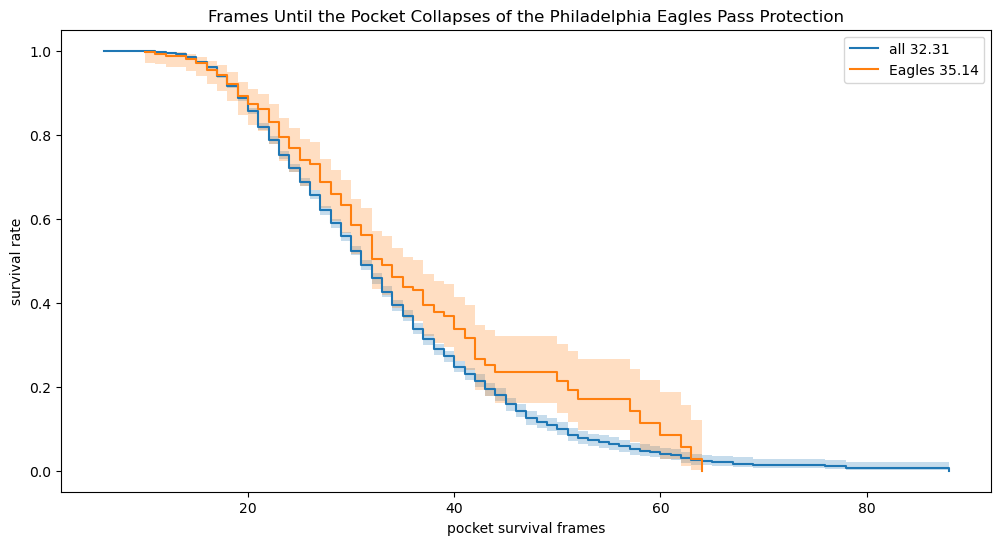

In [76]:
plt.figure(figsize=(12, 6))
x, y, conf_int = kaplan_meier_estimator(
    (
        plays_with_collapse[plays_with_collapse.surv_frame.notna()].poly_frame > -1
    ).to_numpy(),
    plays_with_collapse[plays_with_collapse.surv_frame.notna()].surv_frame.to_numpy(),
    conf_type="log-log",
)
le = life_expectancy(x, y)
plt.step(x, y, where="post", label=f"all {le:3.2f}")
plt.fill_between(x, conf_int[0], conf_int[1], alpha=0.25, step="post")


x, y, conf_int = kaplan_meier_estimator(
    (
        plays_with_collapse[
            plays_with_collapse.surv_frame.notna()
            & (plays_with_collapse.possessionTeam == "PHI")
        ].poly_frame
        > -1
    ).to_numpy(),
    plays_with_collapse[
        plays_with_collapse.surv_frame.notna()
        & (plays_with_collapse.possessionTeam == "PHI")
    ].surv_frame.to_numpy(),
    conf_type="log-log",
)
le = life_expectancy(x, y)
plt.step(x, y, where="post", label=f"Eagles {le:3.2f}")
plt.fill_between(x, conf_int[0], conf_int[1], alpha=0.25, step="post")


plt.xlabel("pocket survival frames")
plt.ylabel("survival rate")
plt.title(
    "Frames Until the Pocket Collapses of the Philadelphia Eagles Pass Protection"
)
plt.legend()
plt.show()

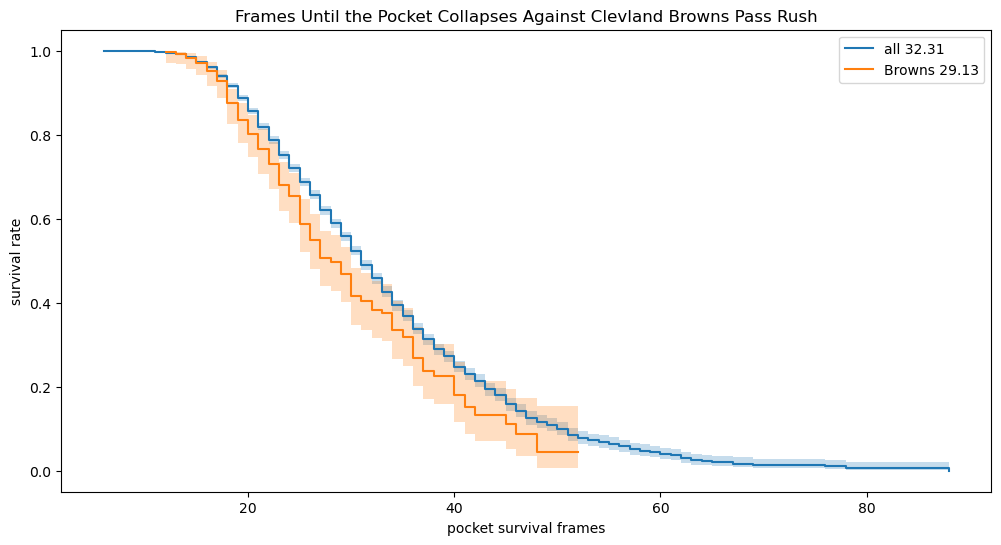

In [77]:
plt.figure(figsize=(12, 6))
x, y, conf_int = kaplan_meier_estimator(
    (
        plays_with_collapse[plays_with_collapse.surv_frame.notna()].poly_frame > -1
    ).to_numpy(),
    plays_with_collapse[plays_with_collapse.surv_frame.notna()].surv_frame.to_numpy(),
    conf_type="log-log",
)
le = life_expectancy(x, y)
plt.step(x, y, where="post", label=f"all {le:3.2f}")
plt.fill_between(x, conf_int[0], conf_int[1], alpha=0.25, step="post")


x, y, conf_int = kaplan_meier_estimator(
    (
        plays_with_collapse[
            plays_with_collapse.surv_frame.notna()
            & (plays_with_collapse.defensiveTeam == "CLE")
        ].poly_frame
        > -1
    ).to_numpy(),
    plays_with_collapse[
        plays_with_collapse.surv_frame.notna()
        & (plays_with_collapse.defensiveTeam == "CLE")
    ].surv_frame.to_numpy(),
    conf_type="log-log",
)
le = life_expectancy(x, y)
plt.step(x, y, where="post", label=f"Browns {le:3.2f}")
plt.fill_between(x, conf_int[0], conf_int[1], alpha=0.25, step="post")

plt.xlabel("pocket survival frames")
plt.ylabel("survival rate")
plt.title("Frames Until the Pocket Collapses Against Clevland Browns Pass Rush")
plt.legend()
plt.show()

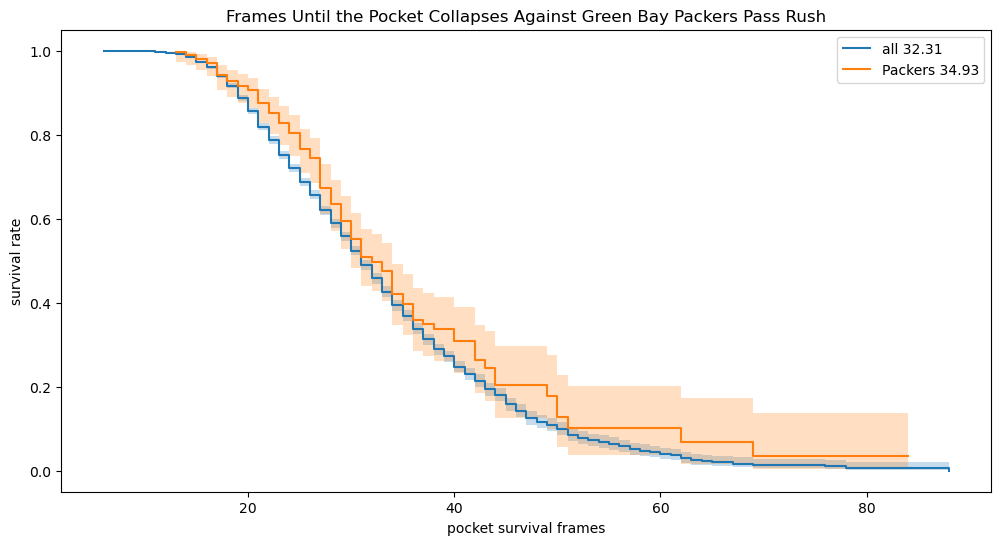

In [78]:
plt.figure(figsize=(12, 6))
x, y, conf_int = kaplan_meier_estimator(
    (
        plays_with_collapse[plays_with_collapse.surv_frame.notna()].poly_frame > -1
    ).to_numpy(),
    plays_with_collapse[plays_with_collapse.surv_frame.notna()].surv_frame.to_numpy(),
    conf_type="log-log",
)
le = life_expectancy(x, y)
plt.step(x, y, where="post", label=f"all {le:3.2f}")
plt.fill_between(x, conf_int[0], conf_int[1], alpha=0.25, step="post")


x, y, conf_int = kaplan_meier_estimator(
    (
        plays_with_collapse[
            plays_with_collapse.surv_frame.notna()
            & (plays_with_collapse.defensiveTeam == "GB")
        ].poly_frame
        > -1
    ).to_numpy(),
    plays_with_collapse[
        plays_with_collapse.surv_frame.notna()
        & (plays_with_collapse.defensiveTeam == "GB")
    ].surv_frame.to_numpy(),
    conf_type="log-log",
)
le = life_expectancy(x, y)
plt.step(x, y, where="post", label=f"Packers {le:3.2f}")
plt.fill_between(x, conf_int[0], conf_int[1], alpha=0.25, step="post")

plt.xlabel("pocket survival frames")
plt.ylabel("survival rate")
plt.title("Frames Until the Pocket Collapses Against Green Bay Packers Pass Rush")
plt.legend()
plt.show()

### we can now do two things: 1. compare the curves directly, and 2. use the life expectancy as proxy quantifying survival of a team or player by all plays of that team or player

### Naive life expectancy of teams: 

In [ ]:
les = []
for team in plays_with_collapse.possessionTeam.unique():
    x, y, conf_int = kaplan_meier_estimator(
        (
            plays_with_collapse[
                plays_with_collapse.surv_frame.notna()
                & (plays_with_collapse.defensiveTeam == team)
            ].poly_frame
            > -1
        ).to_numpy(),
        plays_with_collapse[
            plays_with_collapse.surv_frame.notna()
            & (plays_with_collapse.defensiveTeam == team)
        ].surv_frame.to_numpy(),
        conf_type="log-log",
    )
    le_def = life_expectancy(x, y)
    pval_def = compare_survival(
        plays_with_collapse[["survived", "surv_frame"]].to_records(index=False),
        (plays_with_collapse.defensiveTeam == team).to_numpy(),
    )[1]

    x, y, conf_int = kaplan_meier_estimator(
        (
            plays_with_collapse[
                plays_with_collapse.surv_frame.notna()
                & (plays_with_collapse.possessionTeam == team)
            ].poly_frame
            > -1
        ).to_numpy(),
        plays_with_collapse[
            plays_with_collapse.surv_frame.notna()
            & (plays_with_collapse.possessionTeam == team)
        ].surv_frame.to_numpy(),
        conf_type="log-log",
    )
    le_off = life_expectancy(x, y)

    pval_off = compare_survival(
        plays_with_collapse[["survived", "surv_frame"]].to_records(index=False),
        (plays_with_collapse.possessionTeam == team).to_numpy(),
    )[1]

    les.append(
        {
            "team": team,
            "life_expectancy_defense": le_def,
            "sig_diff_def": pval_def < 0.05,
            "life_expectancy_offense": le_off,
            "sig_diff_off": pval_off < 0.05,
            "mean_polydist_off": plays_with_collapse[
                plays_with_collapse.surv_frame.notna()
                & (plays_with_collapse.possessionTeam == team)
            ].mean_polydists.mean(),
            "mean_polydist_def": plays_with_collapse[
                plays_with_collapse.surv_frame.notna()
                & (plays_with_collapse.defensiveTeam == team)
            ].mean_polydists.mean(),
        }
    )

### in the following dataframes, for each team the life expectancy of the opposing pocket is indicated by _life expectancy def_, wether there is a significant (alpha=.05) difference to the league avg, and the _life expectancy offense_ describes the offensive lines pocket and the significant difference to league average is again indicated. The dataframe is shown twice, first sorted by defense then by offense

In [80]:
le_df = pd.DataFrame(les)
le_df.sort_values("life_expectancy_defense")

,team,life_expectancy_defense,sig_diff_def,life_expectancy_offense,sig_diff_off,mean_polydist_off,mean_polydist_def
7,CAR,28.181299,False,31.292867,False,2.675107,2.546456
3,PHI,28.358525,False,35.135125,True,2.795686,2.547152
20,CLE,29.129604,False,34.569171,False,2.894205,2.620001
23,MIA,29.718155,False,29.987420,False,2.759100,2.644993
19,WAS,29.859379,True,32.912098,True,2.741191,2.678469
5,PIT,30.123296,False,30.132605,True,3.163252,2.791515
12,HOU,30.808643,False,29.359838,False,2.663734,2.685622
29,LA,30.815801,False,31.898762,False,2.980088,2.776305
0,TB,30.860472,False,32.744066,True,3.071593,2.709252
8,MIN,31.146239,False,30.908015,False,2.343423,2.758647


In [81]:
le_df.sort_values("life_expectancy_offense", ascending=False)

,team,life_expectancy_defense,sig_diff_def,life_expectancy_offense,sig_diff_off,mean_polydist_off,mean_polydist_def
3,PHI,28.358525,False,35.135125,True,2.795686,2.547152
9,CIN,32.054750,False,34.605525,True,2.711971,2.819067
20,CLE,29.129604,False,34.569171,False,2.894205,2.620001
11,SF,32.085830,False,34.333768,False,2.789223,2.800057
31,BAL,31.783156,False,33.775811,True,3.132546,2.657475
25,GB,34.932079,False,33.316166,False,2.807185,2.859725
19,WAS,29.859379,True,32.912098,True,2.741191,2.678469
17,ARI,32.500640,False,32.911731,True,3.041942,2.888719
0,TB,30.860472,False,32.744066,True,3.071593,2.709252
26,NYG,32.939296,False,32.376395,False,2.793056,2.850076


In [82]:
le_df.corr(numeric_only=True)

,life_expectancy_defense,sig_diff_def,life_expectancy_offense,sig_diff_off,mean_polydist_off,mean_polydist_def
life_expectancy_defense,1.000000,0.031796,-0.176257,-0.045795,-0.159741,0.683992
sig_diff_def,0.031796,1.000000,-0.224973,0.169764,-0.281384,-0.066022
life_expectancy_offense,-0.176257,-0.224973,1.000000,0.184061,0.425992,-0.049977
sig_diff_off,-0.045795,0.169764,0.184061,1.000000,0.290282,0.057561
mean_polydist_off,-0.159741,-0.281384,0.425992,0.290282,1.000000,-0.038276
mean_polydist_def,0.683992,-0.066022,-0.049977,0.057561,-0.038276,1.000000


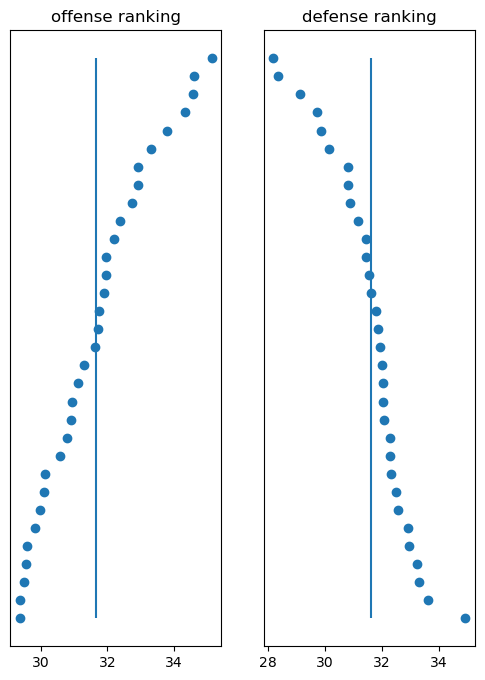

In [83]:
fig, ax = plt.subplots(1, 2, figsize=(6, 8))
ax[0].scatter(
    x=le_df.sort_values(
        "life_expectancy_offense", ascending=True
    ).life_expectancy_offense,
    y=np.arange(32),
)
ax[0].vlines([le_df.life_expectancy_offense.mean()], ymin=0, ymax=31)
ax[0].set_title("offense ranking")
ax[0].set_yticks([])

ax[1].scatter(
    x=le_df.sort_values(
        "life_expectancy_defense", ascending=False
    ).life_expectancy_defense,
    y=np.arange(32),
)
ax[1].vlines([le_df.life_expectancy_defense.mean()], ymin=0, ymax=31)
ax[1].set_title("defense ranking")
ax[1].set_yticks([])
plt.show()

### Looking at that table, we can see that the eagles have very good offensive and defensive lines in pass plays, as does cleveland. On the other hand, the Panthers have a good defensive line but an average offensive line. An interesting special case here are the Green Bay Packers. Their pass rush performns mostly worse than league average in long or short possessions, but around average in medium length plays, leading to a worse life expectancy but no significant different survival rate than league average in general.   

In [84]:
players_with_collapse = pd.merge(
    scouting[scouting.pff_role.isin(["Pass", "Pass Rush", "Pass Block"])][
        ["gameId", "playId", "nflId", "pff_role"]
    ],
    plays_with_collapse,
    how="right",
    on=["gameId", "playId"],
)

In [ ]:
ple_qb = []
for plyr in tqdm(
    players_with_collapse[
        (players_with_collapse.pff_role == "Pass")
        & players_with_collapse.pass_frame.notna()
    ].nflId.unique()
):
    tdf = players_with_collapse[
        (players_with_collapse.nflId == plyr) & players_with_collapse.pass_frame.notna()
    ]
    x, y, conf_int = kaplan_meier_estimator(
        (tdf.pass_frame < 0).to_numpy(),
        tdf.pass_frame.abs().to_numpy(),
        conf_type="log-log",
    )
    le = life_expectancy(x, y)
    ple_qb.append(
        {
            "nflId": plyr,
            "life expectancy": le,
            "num_snaps": tdf.shape[0],
            "team": tdf.possessionTeam.iat[0],
        }
    )

  0%|          | 0/60 [00:00<?, ?it/s]

In [ ]:
qb_df = pd.DataFrame(ple_qb).merge(players, on="nflId")
qb_df[(qb_df.num_snaps > 50)].sort_values("life expectancy", ascending=1).head(60)

,nflId,life expectancy,num_snaps,team,height,weight,birthDate,collegeName,officialPosition,displayName
8,38632,57.0,245,MIN,6-3,202,1988-08-19,Michigan State,QB,Kirk Cousins
26,52413,61.0,135,MIA,6-1,218,1998-03-02,Alabama,QB,Tua Tagovailoa
25,53444,62.0,275,NE,6-3,214,None,None,QB,Mac Jones
30,47789,62.0,268,NYG,6-5,220,1997-05-27,Duke,QB,Daniel Jones
17,38538,63.0,267,TEN,6-4,207,1988-07-27,Texas A&amp;M,QB,Ryan Tannehill
38,53496,63.0,197,HOU,6-4,225,None,None,QB,Davis Mills
1,43424,65.0,208,DAL,6-2,238,1993-07-29,Mississippi State,QB,Dak Prescott
33,34452,66.0,240,LA,6-3,220,1988-02-07,Georgia,QB,Matthew Stafford
44,39987,66.0,96,SEA,6-3,221,1990-10-10,West Virginia,QB,Geno Smith
0,25511,68.0,298,TB,6-4,225,1977-08-03,Michigan,QB,Tom Brady


In [ ]:
### QB throwing tendencies
qb_throw_times = (
    players_with_collapse[players_with_collapse.pff_role == "Pass"]
    .groupby("nflId")
    .agg({"pass_frame": "mean", "playDescription": "count", "possessionTeam": "first"})
    .sort_values("pass_frame")
    .merge(players[["nflId", "displayName"]], on="nflId")
    .rename(columns={"playDescription": "num_snaps"})
)
qb_throw_times[qb_throw_times.num_snaps > 25]

,nflId,pass_frame,num_snaps,possessionTeam,displayName
4,28963,26.572052,229,PIT,Ben Roethlisberger
9,46240,27.418919,74,NYJ,Mike White
10,25511,27.714765,298,TB,Tom Brady
11,53444,28.007273,275,NE,Mac Jones
12,45536,28.086957,46,DAL,Cooper Rush
13,33084,28.267399,273,ATL,Matt Ryan
15,52413,28.888889,135,MIA,Tua Tagovailoa
17,38538,29.056180,267,TEN,Ryan Tannehill
18,37110,29.240000,50,CHI,Andy Dalton
19,52409,29.389344,244,CIN,Joe Burrow


In [88]:
ple_off = []
for plyr in tqdm(
    players_with_collapse[players_with_collapse.pff_role == "Pass Block"].nflId.unique()
):
    tdf = players_with_collapse[
        players_with_collapse.surv_frame.notna() & (players_with_collapse.nflId == plyr)
    ]
    x, y, conf_int = kaplan_meier_estimator(
        (tdf.poly_frame > -1).to_numpy(),
        tdf.surv_frame.to_numpy(),
        conf_type="log-log",
    )
    le = life_expectancy(x, y)
    ple_off.append(
        {
            "nflId": plyr,
            "life expectancy": le,
            "num_snaps": tdf.shape[0],
            "team": tdf.possessionTeam.iat[0],
        }
    )

  0%|          | 0/528 [00:00<?, ?it/s]

In [89]:
pb_df = pd.DataFrame(ple_off).merge(players, on="nflId")
pb_df[(pb_df.num_snaps > 50) & (pb_df.officialPosition == "C")].sort_values(
    "life expectancy", ascending=False
).head(5)

,nflId,life expectancy,num_snaps,team,height,weight,birthDate,collegeName,officialPosition,displayName
27,37266,35.135125,243,PHI,6-3,295,1987-11-05,Cincinnati,C,Jason Kelce
195,40070,34.569171,231,CLE,6-4,307,1991-02-12,Cornell,C,J.C. Tretter
84,41619,34.516051,244,CIN,6-3,316,1992-07-06,Texas,C,Trey Hopkins
103,34472,34.252275,210,SF,6-4,311,1985-11-19,California,C,Alex Mack
306,46284,34.053377,247,BAL,6-5,317,1994-11-24,Alabama,C,Bradley Bozeman


In [90]:
pb_df[(pb_df.num_snaps > 50) & (pb_df.officialPosition == "G")].sort_values(
    "life expectancy", ascending=False
).head(5)

,nflId,life expectancy,num_snaps,team,height,weight,birthDate,collegeName,officialPosition,displayName
30,43368,37.052295,78,PHI,6-4,303,1993-10-29,Oregon State,G,Isaac Seumalo
349,53466,34.760694,203,PHI,6-6,325,None,None,G,Landon Dickerson
85,43045,34.605525,246,CIN,6-4,330,1991-08-07,West Virginia,G,Quinton Spain
198,46235,34.569171,231,CLE,6-4,315,1994-11-21,Virginia Tech,G,Wyatt Teller
196,41264,34.569171,231,CLE,6-4,320,1991-10-11,Nevada,G,Joel Bitonio


In [91]:
pb_df[(pb_df.num_snaps > 50) & (pb_df.officialPosition == "T")].sort_values(
    "life expectancy", ascending=False
).head(5)

,nflId,life expectancy,num_snaps,team,height,weight,birthDate,collegeName,officialPosition,displayName
29,39950,38.404533,126,PHI,6-6,317,1990-05-08,Oklahoma,T,Lane Johnson
197,43297,35.754130,144,CLE,6-6,308,1994-08-17,Michigan State,T,Jack Conklin
31,46302,35.265444,165,PHI,6-8,344,1997-03-31,No College,T,Jordan Mailata
104,35443,34.863467,170,SF,6-5,320,1988-07-19,Oklahoma,T,Trent Williams
86,47794,34.605525,246,CIN,6-4,305,1997-11-17,Alabama,T,Jonah Williams


#### looking at these player rankings, we can see that some expected names (Jason Kelce, Trent Williams, Alejandro Villanueva, Joel Bitonio) show up but also some unexpected names like Landon Dickerson and Sam Cosmi. A similar ranking (grouped by position) can now be created for the defensive positions. 

In [92]:
ple_def = []
for plyr in tqdm(
    players_with_collapse[players_with_collapse.pff_role == "Pass Rush"].nflId.unique()
):
    tdf = players_with_collapse[
        players_with_collapse.surv_frame.notna()
        & (players_with_collapse.nflId == plyr)
        & (players_with_collapse.pff_role == "Pass Rush")
    ]
    x, y, conf_int = kaplan_meier_estimator(
        (tdf.poly_frame > -1).to_numpy(),
        tdf.surv_frame.to_numpy(),
        conf_type="log-log",
    )
    le = life_expectancy(x, y)
    ple_def.append(
        {
            "nflId": plyr,
            "life expectancy": le,
            "num_snaps": tdf.shape[0],
            "team": tdf.defensiveTeam.iat[0],
        }
    )

  0%|          | 0/692 [00:00<?, ?it/s]

In [93]:
pr_df = pd.DataFrame(ple_def).merge(players, on="nflId")
pr_df[(pr_df.num_snaps > 50) & (pr_df.officialPosition == "DE")].sort_values(
    "life expectancy"
).head(5)

,nflId,life expectancy,num_snaps,team,height,weight,birthDate,collegeName,officialPosition,displayName
90,52446,25.286761,51,CAR,6-5,264,1998-02-26,Penn State,DE,Yetur Gross-Matos
33,44826,27.494407,155,PHI,6-3,259,1996-06-25,Tennessee,DE,Derek Barnett
80,47799,27.719098,195,CAR,6-5,250,1998-04-23,Florida State,DE,Brian Burns
79,43791,27.770828,140,CAR,6-3,275,1994-09-12,Colorado State-Pueblo,DE,Morgan Fox
34,37089,27.870959,86,PHI,6-4,265,1988-08-16,Purdue,DE,Ryan Kerrigan


In [94]:
pr_df[(pr_df.num_snaps > 50) & (pr_df.officialPosition == "DT")].sort_values(
    "life expectancy"
).head(5)

,nflId,life expectancy,num_snaps,team,height,weight,birthDate,collegeName,officialPosition,displayName
312,46307,27.188329,86,MIA,6-6,290,1995-09-07,Ferris State,DT,Zach Sieler
81,52415,27.364482,152,CAR,6-5,318,1998-04-15,Auburn,DT,Derrick Brown
31,38542,27.450804,173,PHI,6-4,310,1990-12-13,Mississippi State,DT,Fletcher Cox
173,52481,27.508067,57,JAX,6-4,310,1997-02-01,Ohio State,DT,Davon Hamilton
32,43378,27.784866,165,PHI,6-2,305,1993-02-07,South Carolina State,DT,Javon Hargrave


In [95]:
pr_df[(pr_df.num_snaps > 50) & (pr_df.officialPosition == "NT")].sort_values(
    "life expectancy"
).head(5)

,nflId,life expectancy,num_snaps,team,height,weight,birthDate,collegeName,officialPosition,displayName
92,47786,28.547700,148,NYJ,6-3,303,1997-12-21,Alabama,NT,Quinnen Williams
8,46081,28.957868,190,TB,6-4,347,1995-02-05,Washington,NT,Vita Vea
567,42382,29.080525,56,CHI,6-3,320,1994-01-06,Florida State,NT,Eddie Goldman
301,52464,29.305710,54,MIA,6-7,310,None,Alabama,NT,Raekwon Davis
308,40030,29.525594,51,MIA,6-3,327,1989-07-11,Georgia,NT,John Jenkins


# Comparison with pff grades 

In [96]:
import plotly.express as px

In [97]:
pff_pr_df = pd.read_csv("pass_rush_summary.csv")

In [98]:
pff_pb_df = pd.read_csv("offense_pass_blocking.csv")

In [99]:
pr_comp = pff_pr_df.merge(pr_df, how="inner", left_on="player", right_on="displayName")
print(pr_comp.shape)
pb_comp = pff_pb_df.merge(pb_df, how="inner", left_on="player", right_on="displayName")
print(pb_comp.shape)

(633, 44)
(496, 40)


In [100]:
pr_comp.columns

Index(['player', 'player_id', 'position', 'team_name', 'player_game_count',
       'batted_passes', 'declined_penalties', 'franchise_id',
       'grades_pass_rush_defense', 'hits', 'hurries', 'pass_rush_opp',
       'pass_rush_percent', 'pass_rush_win_rate', 'pass_rush_wins',
       'penalties', 'prp', 'sacks', 'snap_counts_pass_play',
       'snap_counts_pass_rush', 'total_pressures',
       'true_pass_set_batted_passes', 'true_pass_set_grades_pass_rush_defense',
       'true_pass_set_hits', 'true_pass_set_hurries',
       'true_pass_set_pass_rush_opp', 'true_pass_set_pass_rush_percent',
       'true_pass_set_pass_rush_win_rate', 'true_pass_set_pass_rush_wins',
       'true_pass_set_prp', 'true_pass_set_sacks',
       'true_pass_set_snap_counts_pass_play',
       'true_pass_set_snap_counts_pass_rush', 'true_pass_set_total_pressures',
       'nflId', 'life expectancy', 'num_snaps', 'team', 'height', 'weight',
       'birthDate', 'collegeName', 'officialPosition', 'displayName'],
      

In [101]:
pb_comp.columns

Index(['player', 'player_id', 'position', 'team_name', 'player_game_count',
       'declined_penalties', 'franchise_id', 'grades_pass_block',
       'hits_allowed', 'hurries_allowed', 'non_spike_pass_block',
       'non_spike_pass_block_percentage', 'pass_block_percent', 'pbe',
       'penalties', 'pressures_allowed', 'sacks_allowed',
       'snap_counts_pass_block', 'snap_counts_pass_play',
       'true_pass_set_grades_pass_block', 'true_pass_set_hits_allowed',
       'true_pass_set_hurries_allowed', 'true_pass_set_non_spike_pass_block',
       'true_pass_set_non_spike_pass_block_percentage',
       'true_pass_set_pass_block_percent', 'true_pass_set_pbe',
       'true_pass_set_pressures_allowed', 'true_pass_set_sacks_allowed',
       'true_pass_set_snap_counts_pass_block',
       'true_pass_set_snap_counts_pass_play', 'nflId', 'life expectancy',
       'num_snaps', 'team', 'height', 'weight', 'birthDate', 'collegeName',
       'officialPosition', 'displayName'],
      dtype='object')

In [102]:
px.scatter(
    pr_comp[pr_comp.num_snaps > 50],
    x="life expectancy",
    y="grades_pass_rush_defense",
    size="num_snaps",
    hover_data=["num_snaps", "player", "position", "team_name"],
    height=800,
    title="pass rush grades vs life expectancy (at least 50 snaps), size is num of snaps",
    trendline="ols",
)

#### the visualization of defensive life expectancy vs pass rush grades shows a trend with a slight negative correlation. We can especially identify some special cases: Devin White, by far the lowest life expectancy, is a LB which means if he is rushing, it is probably a blitz. This makes sense then that his pass rushing leads to faster pocket collapse but he is not a elite pass rusher. on the other hand, Trevis gipson, a Bears EDGE, hasa a good grade but does not seem to collapse the pocket quickly, which might be due to him being on one of the worse pass rushing teams. Also we can identify elite pass rushers in the top left (high grade, low enemy pocket life expectancy). This group consists of Micah Parsons, Myles Garret, Aaron Donald and Javon Hargrave, some of the most well regarded pass rushers. It has to be noted on the defensive end however, that our approach currently does not correct for number of snaps played or type of plays a player takes part in. This means that a lot of pass rushing succes of a LB might be due to them being part of high pressure calls where they would otherwise not pass rush but rather defend a receiver. On the other hand, a NT will almost always be pass rushing, (one need only think of 3rd and long situations, with only 1-3 rushers going up against a full front 5, thus having much more trouble to collapse the pocket) this is reflected in the pocket collapse outcomes, leading to low correlation between grades and our metric. 

In [103]:
px.scatter(
    pb_comp[pb_comp.num_snaps > 50],
    x="life expectancy",
    y="grades_pass_block",
    hover_data=["player", "position", "team_name", "num_snaps"],
    height=800,
    title="pass block grades vs life expectancy (at least 50 snaps)",
    trendline="ols",
)

#### visualizing the player grades assigned by pff, we can se a moderate correlation for offensive players, there are some with high life expectancy but lower grades  (josh jones, daniel brunskill which might be weaker players on otherwise good lines, incidentally arz and sf are among the top 5 life expectancies) where as the opposite case, high grade and low life expectancy, kevin dotson and jake matthews are both from bottom 3 offensive lines, suggesting their individual play might have been solid but they could not make up for an overall bad line or play calling. Conversely, top players like jc tretter and joel bitonio are also among the players with the highest life expectancies, and alex leatherwood and jalen mayfield have very bad grades and among the worst life expectancies.

## life expectancy relative to team performance.

#### as just argued, life expectancy is somewhat of a team dependand stat 

In [104]:
pr_comp = pr_comp.merge(le_df, how="inner", left_on="team_name", right_on="team")
pr_comp["team_rel_le"] = pr_comp["life expectancy"] - pr_comp["life_expectancy_defense"]
print(pr_comp.shape)
pb_comp = pb_comp.merge(le_df, how="inner", left_on="team_name", right_on="team")
pb_comp["team_rel_le"] = pb_comp["life expectancy"] - pb_comp["life_expectancy_offense"]
print(pb_comp.shape)

(547, 52)
(430, 48)


In [ ]:
team = "PHI"
pb_comp.loc[
    (pb_comp.team_name == team) & (pb_comp.num_snaps > 15),
    [
        "nflId",
        "player",
        "position",
        "num_snaps",
        "life expectancy",
        "team_rel_le",
        "grades_pass_block",
    ],
].sort_values("team_rel_le").merge(
    players_with_collapse.loc[
        (players_with_collapse["possessionTeam"] == team)
        & (players_with_collapse.pff_role == "Pass Block"),
        ["nflId", "prePenaltyPlayResult", "defendersInBox"],
    ]
    .groupby("nflId")
    .mean()
    .reset_index(),
    on="nflId",
    how="left",
)

,nflId,player,position,num_snaps,life expectancy,team_rel_le,grades_pass_block,prePenaltyPlayResult,defendersInBox
0,47836,Miles Sanders,HB,20,26.361422,-8.773703,46.0,4.150000,6.300000
1,52553,Jack Driscoll,G,144,31.991615,-3.143511,73.9,5.722222,5.854167
2,47805,Andre Dillard,T,151,32.372792,-2.762333,71.7,5.947020,6.013245
3,48513,Nate Herbig,G,67,33.809989,-1.325137,63.9,7.611940,6.238806
4,53466,Landon Dickerson,G,203,34.760694,-0.374432,57.1,6.709360,6.000000
5,37266,Jason Kelce,C,243,35.135125,0.000000,67.7,6.786008,5.991770
6,46302,Jordan Mailata,T,165,35.265444,0.130319,83.3,6.745455,5.896970
7,38606,Brandon Brooks,G,38,35.473556,0.338430,62.8,7.026316,5.921053
8,43368,Isaac Seumalo,G,78,37.052295,1.917170,82.9,7.705128,6.115385
9,39950,Lane Johnson,T,126,38.404533,3.269408,81.2,8.103175,6.047619


### connecting to the earlier analysis (for PHI, each extra survived frame for the pocket we expect an extra half a yard gained and 0.064 epa gained), with the eagles as a nice team because they rotate their OL presonel allowing us to have several players with a good sample of sanps played. Here we can see that the extra 2.4 frames in life expectancy when Lane Johnson plays over Jordan Mailata translates to about 1.3 more yards, and the the extra 4.7 frames between Lane Johnson and Andre Dillard leads to an extra 2.5 yards gained before penalties. An intersting exception here is Nate Herbig, who has a below average life expectancy but a higher expected yards gained per play than Dickerson, Kelce and Mailata however in his 68 Snaps he also played on average against 0.3-0.5 more pass rushers per play, suggesting that in his case the defense was bringing pressure and while that lead to a quicker pocket collapse, the pocket held long enough for Hurts to make a good play.  

In [106]:
px.scatter(
    pr_comp[pr_comp.num_snaps > 50],
    x="team_rel_le",
    y="grades_pass_rush_defense",
    size="num_snaps",
    hover_data=["num_snaps", "player", "position", "team_name"],
    height=800,
    title="pass rush grades vs team relative life expectancy (at least 50 snaps), size is num of snaps",
    trendline="ols",
)

### looking at team relative life expectancy vs pass rush grades gives another perspective, which is which players improve their teams time to collapse the pocket. Again, Micah parsons is one of the top players, however many of the better known pass rushers like aaron donald, maxx crosby and chris jones tend to play a lot of snaps (239 for AD vs Micahs 96, so it is more difficult to perform better than the team average, if you play almost every snap). interesting here are trevis gipson with a top grade but leading to a longer pocket life expectancy on one hand and devin white, with a average grade but a massive -4.6 frames quicker pocket collapse on the 69 snaps he's played on compared to team average.  

In [107]:
px.scatter(
    pb_comp[pb_comp.num_snaps > 50],
    x="team_rel_le",
    y="grades_pass_block",
    size="num_snaps",
    hover_data=["num_snaps", "player", "position", "team_name"],
    height=800,
    title="team relative pass block grades vs life expectancy (at least 50 snaps)",
    trendline="ols",
)

#### for offensive lines, much more so than defensive players, there are a lot of players who just play (almost) every snap. This means on one hand, that the performance of the team is more reflective of team success / play calling and formation does not play as much of a role as for defensive players but also it is more difficult to assign credit or blame to individual players. however, we have some interesting special cases here. Lane Johnson and Isaac Seumalo are providing massive value to the Eagles front when they play, which is also reflected in their grade, however jack driscoll and andre dillard pay the price in terms of life expectancy when they have to fill in.elijah wilkinson was only playing 52 snaps, and didn't achieve average performance in terms of pff grading, but during his snaps the line held up 1.74 frames longer on average, which is good for third behind the two eagles players. 

## pff grades related to other features

In [108]:
players_with_collapse.columns

Index(['gameId', 'playId', 'nflId', 'pff_role', 'mean_polydists',
       'playDescription', 'pff_playAction', 'passResult',
       'prePenaltyPlayResult', 'defendersInBox', 'personnelO', 'personnelD',
       'dropBackType', 'pff_passCoverage', 'pff_passCoverageType',
       'offenseFormation', 'yardsToGo', 'down', 'possessionTeam',
       'defensiveTeam', 'ep', 'epa', 'qb_epa', 'touchdown', 'air_yards',
       'complete', 'incomplete', 'sack', 'pass_absolute_frame', 'min_frame',
       'poly_frame', 'surv_frame', 'pass_frame', 'frameId', 'polydist',
       'qb_radius', 'p_blockwin', 'max_frame', 'survived', 'pass_thrown',
       'pocket_end_event', 'pocket_end', 'pocket_vol', 'down1', 'down2',
       'down3', 'zone', 'man', 'Cover-3', 'Cover-1', 'Cover-2', 'Quarters',
       'Cover-6', 'RedZone', 'Cover-0', '2-Man', 'shotgun', 'empty',
       'singleback', 'iform', 'comp_air_yards', 'safe_pass'],
      dtype='object')

In [ ]:
mean_stuff = (
    players_with_collapse.groupby("nflId")
    .agg(
        {
            "sack": "mean",
            "complete": "mean",
            "epa": "mean",
            "polydist": "mean",
            "mean_polydists": "mean",
            "surv_frame": "mean",
            "pocket_vol": "mean",
            "prePenaltyPlayResult": "mean",
            "air_yards": "mean",
            "comp_air_yards": "mean",
            "p_blockwin": "mean",
            "playDescription": "count",
        }
    )
    .reset_index()
    .rename(columns={"playDescription": "num_snaps"})
    .sort_values(["mean_polydists", "num_snaps"])
)

In [ ]:
mean_stuff = mean_stuff.merge(
    players[players.officialPosition != "QB"], on="nflId", how="left"
)

In [ ]:
off_comp = pd.merge(
    mean_stuff, pff_pb_df, how="inner", left_on="displayName", right_on="player"
)
off_comp = pd.merge(off_comp, pb_df[["nflId", "life expectancy"]], on="nflId")
print(off_comp.shape)
def_comp = pd.merge(
    mean_stuff, pff_pr_df, how="inner", left_on="displayName", right_on="player"
)
def_comp = pd.merge(def_comp, pr_df[["nflId", "life expectancy"]], on="nflId")
print(def_comp.shape)

(495, 50)
(633, 54)


In [ ]:
off_comp["norm_grades"] = (
    off_comp["grades_pass_block"] - off_comp["grades_pass_block"].mean()
) / off_comp["grades_pass_block"].std()
def_comp["norm_grades"] = (
    def_comp["grades_pass_rush_defense"] - def_comp["grades_pass_rush_defense"].mean()
) / def_comp["grades_pass_rush_defense"].std()

## comparing the correlations of pff grades with common performance indicators (i.e. targets from earlier)

#### when looking at the correlations betwenn offensive play results and life expectancy and pass blocking grades, we can see that life expectancy is clearly more correlated to measures of play outcome. This suggests that life expectancy is a better measure of pass protection than pass blocking grade. on the other hand, defense seems a more tricky topic, as it is difficult to for a single measure to account for the different dynamics in formation and playcalling. _Given the metric is a good measurement of offensive protection, it is initself valuable to know, which player is able to interfere with the protection capabilities the most_ 

In [113]:
oc = off_comp.loc[
    off_comp.num_snaps > 20,
    [
        "sack",
        "complete",
        "epa",
        "prePenaltyPlayResult",
        "air_yards",
        "comp_air_yards",
        "p_blockwin",
        "mean_polydists",
        "surv_frame",
        "pocket_vol",
        "life expectancy",
        "grades_pass_block",
    ],
].corr()[["life expectancy", "grades_pass_block", "mean_polydists", "pocket_vol"]]
oc["max_corr"] = oc.abs().idxmax(axis=1)
oc

,life expectancy,grades_pass_block,mean_polydists,pocket_vol,max_corr
sack,-0.220535,-0.126947,-0.109458,-0.131269,life expectancy
complete,-0.056063,0.023913,-0.016737,-0.149589,pocket_vol
epa,0.135003,0.031743,0.083857,0.138531,pocket_vol
prePenaltyPlayResult,0.295979,0.036977,0.100162,0.266765,life expectancy
air_yards,0.295122,0.008741,0.077316,0.384283,pocket_vol
comp_air_yards,0.141922,-0.080940,-0.004534,0.189719,pocket_vol
p_blockwin,0.685656,0.205450,0.388583,0.606685,life expectancy
mean_polydists,0.497853,0.287790,1.000000,0.854939,mean_polydists
surv_frame,0.761226,0.190543,0.318601,0.748207,life expectancy
pocket_vol,0.734139,0.287820,0.854939,1.000000,pocket_vol


In [ ]:
dc = def_comp.loc[
    def_comp.num_snaps > 20,
    [
        "sack",
        "hurries",
        "hits",
        "pass_rush_win_rate",
        "complete",
        "epa",
        "prePenaltyPlayResult",
        "air_yards",
        "p_blockwin",
        "comp_air_yards",
        "mean_polydists",
        "surv_frame",
        "pocket_vol",
        "life expectancy",
        "grades_pass_rush_defense",
    ],
].corr()[
    ["life expectancy", "grades_pass_rush_defense", "mean_polydists", "pocket_vol"]
]
dc["max_corr"] = dc.abs().idxmax(axis=1)
dc

,life expectancy,grades_pass_rush_defense,mean_polydists,pocket_vol,max_corr
sack,-0.295760,0.193810,-0.186982,-0.250137,life expectancy
hurries,0.156173,0.613237,0.063012,0.014210,grades_pass_rush_defense
hits,0.105928,0.536811,0.023271,-0.033121,grades_pass_rush_defense
pass_rush_win_rate,-0.081931,0.850083,-0.040713,-0.109158,grades_pass_rush_defense
complete,0.163089,-0.136693,0.070775,0.102203,life expectancy
epa,0.019855,-0.120400,-0.042903,0.018796,grades_pass_rush_defense
prePenaltyPlayResult,0.150044,-0.153127,0.034555,0.133344,grades_pass_rush_defense
air_yards,0.050873,-0.032492,-0.040847,0.113295,pocket_vol
p_blockwin,0.772697,-0.102211,0.613185,0.778219,pocket_vol
comp_air_yards,-0.065511,-0.012165,-0.082353,-0.034449,mean_polydists


## we can se here, that an increase in life expectancy of 2 frames means practically for the average offense: 0.5% less likely to result  in a sack, 0.05 higher epa on average, 

In [115]:
px.scatter(
    off_comp[off_comp.num_snaps > 130],
    x="life expectancy",
    y=["epa", "complete", "sack"],
    hover_data=["player", "position", "team_name", "num_snaps"],
    height=800,
    title="pass block grades vs mean poly dists (at least 50 snaps)",
    trendline="ols",
)

In [ ]:
off_comp["norm_le"] = off_comp["life expectancy"] - off_comp["life expectancy"].min()
off_comp["norm_le"] = off_comp["norm_le"] / off_comp["norm_le"].max()

off_comp["minmax_grades"] = (
    off_comp["grades_pass_block"] - off_comp["grades_pass_block"].min()
)
off_comp["minmax_grades"] = off_comp["minmax_grades"] / off_comp["minmax_grades"].max()
px.scatter(
    off_comp[off_comp.num_snaps > 50],
    x=["norm_le", "minmax_grades"],
    y="epa",
    hover_data=["player", "position", "team_name", "num_snaps"],
    height=800,
    title="pass block grades vs mean poly dists (at least 50 snaps)",
    trendline="ols",
)

In [ ]:
px.scatter(
    off_comp[off_comp.num_snaps > 50],
    x="surv_frame",
    y="grades_pass_block",
    hover_data=["player", "position", "team_name", "num_snaps"],
    height=800,
    title="pass block grades vs mean cpocket volume (at least 50 snaps)",
    trendline="ols",
)

In [118]:
px.scatter(
    off_comp[off_comp.num_snaps > 50],
    x="pocket_vol",
    y="grades_pass_block",
    hover_data=["player", "position", "team_name", "num_snaps"],
    height=800,
    title="pass block grades vs mean cpocket volume (at least 50 snaps)",
    trendline="ols",
)

In [ ]:
px.scatter(
    off_comp[off_comp.num_snaps > 50],
    x="p_blockwin",
    y="grades_pass_block",
    hover_data=["player", "position", "team_name", "num_snaps"],
    height=800,
    title="pass block grades vs mean cpocket volume (at least 50 snaps)",
    trendline="ols",
)

In [ ]:
px.scatter(
    off_comp[off_comp.num_snaps > 50],
    x="p_blockwin",
    y="pressures_allowed",
    hover_data=["player", "position", "team_name", "num_snaps"],
    height=800,
    title="pass block grades vs mean cpocket volume (at least 50 snaps)",
    trendline="ols",
)

## defense 

In [121]:
px.scatter(
    def_comp[def_comp.num_snaps > 50],
    x="mean_polydists",
    y="grades_pass_rush_defense",
    hover_data=["player", "position", "team_name", "num_snaps"],
    height=800,
    title="pass block grades vs mean poly dists (at least 50 snaps)",
    trendline="ols",
)

In [ ]:
px.scatter(
    def_comp[def_comp.num_snaps > 50],
    x="surv_frame",
    y="grades_pass_rush_defense",
    hover_data=["player", "position", "team_name", "num_snaps"],
    height=800,
    title="pass block grades vs mean cpocket volume (at least 50 snaps)",
    trendline="ols",
)

In [ ]:
px.scatter(
    def_comp[def_comp.num_snaps > 50],
    x="pocket_vol",
    y="grades_pass_rush_defense",
    hover_data=["player", "position", "team_name", "num_snaps"],
    height=800,
    title="pass block grades vs mean cpocket volume (at least 50 snaps)",
    trendline="ols",
)

In [124]:
px.scatter(
    def_comp[def_comp.num_snaps > 50],
    x="p_blockwin",
    y="grades_pass_rush_defense",
    hover_data=["player", "position", "team_name", "num_snaps"],
    height=800,
    title="pass block grades vs mean cpocket volume (at least 50 snaps)",
    trendline="ols",
)

In [125]:
def_comp.columns

Index(['nflId', 'sack', 'complete', 'epa', 'polydist', 'mean_polydists',
       'surv_frame', 'pocket_vol', 'prePenaltyPlayResult', 'air_yards',
       'comp_air_yards', 'p_blockwin', 'num_snaps', 'height', 'weight',
       'birthDate', 'collegeName', 'officialPosition', 'displayName', 'player',
       'player_id', 'position', 'team_name', 'player_game_count',
       'batted_passes', 'declined_penalties', 'franchise_id',
       'grades_pass_rush_defense', 'hits', 'hurries', 'pass_rush_opp',
       'pass_rush_percent', 'pass_rush_win_rate', 'pass_rush_wins',
       'penalties', 'prp', 'sacks', 'snap_counts_pass_play',
       'snap_counts_pass_rush', 'total_pressures',
       'true_pass_set_batted_passes', 'true_pass_set_grades_pass_rush_defense',
       'true_pass_set_hits', 'true_pass_set_hurries',
       'true_pass_set_pass_rush_opp', 'true_pass_set_pass_rush_percent',
       'true_pass_set_pass_rush_win_rate', 'true_pass_set_pass_rush_wins',
       'true_pass_set_prp', 'true_pass_set

In [126]:
px.scatter(
    def_comp[def_comp.num_snaps > 50],
    x="p_blockwin",
    y="pass_rush_win_rate",
    hover_data=["player", "position", "team_name", "num_snaps"],
    height=800,
    title="pass block grades vs mean pocket volume (at least 50 snaps)",
    trendline="ols",
)

In [ ]:
plays_with_collapse.groupby("possessionTeam")[
    ["mean_polydists", "polydist", "pocket_vol"]
].mean().sort_values("mean_polydists")

,mean_polydists,polydist,pocket_vol
possessionTeam,,,
MIN,2.343423,0.995599,66.553363
DEN,2.517115,1.065759,74.042237
ATL,2.558250,1.002531,69.895176
SEA,2.600390,1.084212,73.082185
JAX,2.607585,0.946876,73.865770
DET,2.613690,0.949058,75.073529
TEN,2.615677,1.229528,74.209826
LAC,2.616391,1.149937,72.501957
LV,2.628096,0.968208,73.671425


In [ ]:
plays_with_collapse.groupby("possessionTeam")[
    [
        "surv_frame",
        "mean_polydists",
        "polydist",
        "pocket_vol",
        "epa",
        "prePenaltyPlayResult",
    ]
].mean().sort_values("mean_polydists").corr()

,surv_frame,mean_polydists,polydist,pocket_vol,epa,prePenaltyPlayResult
surv_frame,1.000000,0.297674,0.290026,0.697842,0.210267,0.232224
mean_polydists,0.297674,1.000000,0.624772,0.884464,0.339606,0.327117
polydist,0.290026,0.624772,1.000000,0.591547,0.196506,0.238591
pocket_vol,0.697842,0.884464,0.591547,1.000000,0.353851,0.368983
epa,0.210267,0.339606,0.196506,0.353851,1.000000,0.903252
prePenaltyPlayResult,0.232224,0.327117,0.238591,0.368983,0.903252,1.000000


In [ ]:
plays_with_collapse.groupby("defensiveTeam")[
    ["mean_polydists", "polydist", "pocket_vol", "epa", "prePenaltyPlayResult"]
].mean().sort_values("mean_polydists")

,mean_polydists,polydist,pocket_vol,epa,prePenaltyPlayResult
defensiveTeam,,,,,
CAR,2.546456,1.057744,68.491611,-0.023131,5.719368
PHI,2.547152,0.954597,68.737423,0.045084,6.638554
NYJ,2.590952,1.180286,72.345058,0.227041,6.687500
CLE,2.620001,0.935399,71.339878,0.236870,6.076923
MIA,2.644993,0.962653,73.234868,0.339739,7.498246
BAL,2.657475,1.115436,74.201474,0.128634,7.084677
WAS,2.678469,1.060030,74.039043,0.334225,7.432787
HOU,2.685622,1.082452,78.981093,0.237810,7.666667
TB,2.709252,1.150029,75.406166,-0.002805,5.724684


# Survival analysis and Life Expectancy using Cox Proportional Hazard 

#### We use Cox PH for two different reasons here: 
* modeling life expectancy based on game situation (i.e. which team is playing, is it play action?)
* we have at least two different time-to-events we are modeling: time-to-collapse and time-to-pass which are influencing each other on occurance

In order to achieve this, we use lifelines. here we first standardize the some features and we use the survival frames as target duration

### Optionally: fit the pocket size over time to create additional features. they might be leaking information though. 

In [130]:
from scipy.optimize import curve_fit

In [ ]:
def decay_func(x, amplitude, slope, x_inter, y_inter):
    return -amplitude / (1 + np.exp(-slope * (x - x_inter))) + y_inter

In [ ]:
curve_fit(decay_func, np.arange(len(radii)), radii, p0=(5, 0.5, 20, 5))

(array([ 4.76107513,  0.34842735, 23.09497652,  4.92017095]),
 array([[ 0.01796739, -0.00300866,  0.00652713,  0.0071638 ],
        [-0.00300866,  0.0011494 , -0.00105802, -0.00120934],
        [ 0.00652713, -0.00105802,  0.09786221, -0.00820214],
        [ 0.0071638 , -0.00120934, -0.00820214,  0.00584917]]))

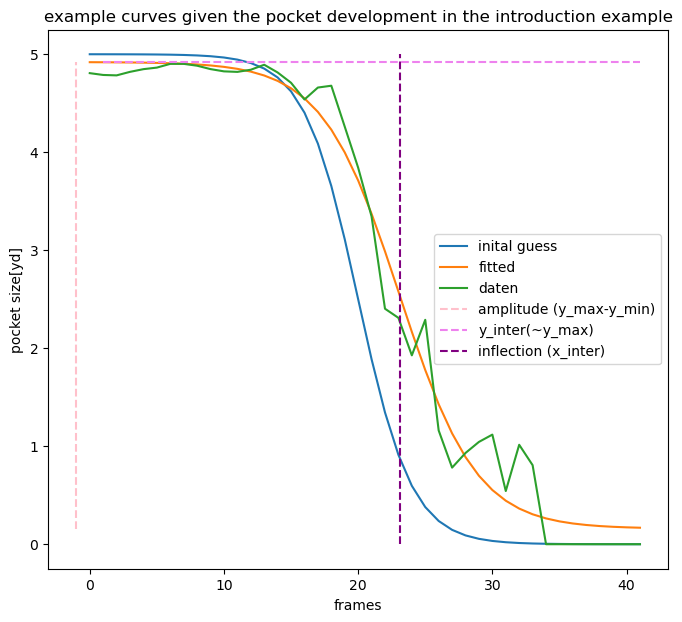

In [ ]:
plt.figure(figsize=(8, 7))
plt.plot(
    np.arange(0, 42), decay_func(np.arange(0, 42), 5, 0.5, 20, 5), label="inital guess"
)
plt.plot(
    np.arange(0, 42),
    decay_func(np.arange(0, 42), 4.76107513, 0.34842735, 23.09497652, 4.92017095),
    label="fitted",
)
plt.plot(radii, label="daten")
plt.vlines(
    [-1],
    4.92017095 - 4.76107513,
    4.92017095,
    label="amplitude (y_max-y_min)",
    linestyle="dashed",
    color="pink",
)
plt.hlines(
    [4.92017095], 1, 41, label="y_inter(~y_max)", linestyle="dashed", color="violet"
)
plt.vlines(
    [23.09497652],
    0,
    5,
    label="inflection (x_inter)",
    linestyle="dashed",
    color="purple",
)
plt.title("example curves given the pocket development in the introduction example")
plt.legend(loc="center right")
plt.xlabel("frames")
plt.ylabel("pocket size[yd]")
plt.show()

In [ ]:
ks = ["L", "k", "x0", "y0"]
ks_30 = ["L_30", "k_30", "x0_30", "y0_30"]


def fit_decay(df, cutoff=None):
    if cutoff:
        df = df[df.frameId.le(df.frameId.min() + cutoff)]
    popt, pcov = curve_fit(
        decay_func,
        df.frameId - df.frameId.min(),
        df.polydist,
        p0=(df.polydist.max(), 0.5, df.frameId.max() / 2, df.polydist.max()),
        bounds=([0, -np.inf, 0, 0], [40, np.inf, 200, 40]),
        maxfev=100_000,
    )
    return {k: v for k, v in zip(ks, popt)}

In [ ]:
full_curve = (
    qb_spaces.groupby(["gameId", "playId"])
    .progress_apply(fit_decay)
    .reset_index()
    .rename(columns={0: "pcov"})
)
full_curve["L"] = full_curve["pcov"].progress_apply(lambda x: x["L"])
full_curve["k"] = full_curve["pcov"].progress_apply(lambda x: x["k"])
full_curve["x0"] = full_curve["pcov"].progress_apply(lambda x: x["x0"])
full_curve["y0"] = full_curve["pcov"].progress_apply(lambda x: x["y0"])
full_curve = full_curve.drop(columns="pcov")

  0%|          | 0/8557 [00:00<?, ?it/s]

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

overflow encountered in exp

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

overflow encountered in exp

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

overflow encountered in exp

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

overflow encountered in exp

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

overflow encountered in exp

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

overflow encountered in exp

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

overflow encountered in exp

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\pandas\core\

  0%|          | 0/8557 [00:00<?, ?it/s]

  0%|          | 0/8557 [00:00<?, ?it/s]

  0%|          | 0/8557 [00:00<?, ?it/s]

  0%|          | 0/8557 [00:00<?, ?it/s]

In [ ]:
cutoff_30_curve = (
    qb_spaces.groupby(["gameId", "playId"])
    .progress_apply(lambda df: fit_decay(df, cutoff=30))
    .reset_index()
    .rename(columns={0: "pcov"})
)
cutoff_30_curve["L_30"] = cutoff_30_curve["pcov"].progress_apply(lambda x: x["L"])
cutoff_30_curve["k_30"] = cutoff_30_curve["pcov"].progress_apply(lambda x: x["k"])
cutoff_30_curve["x0_30"] = cutoff_30_curve["pcov"].progress_apply(lambda x: x["x0"])
cutoff_30_curve["y0_30"] = cutoff_30_curve["pcov"].progress_apply(lambda x: x["y0"])
cutoff_30_curve = cutoff_30_curve.drop(columns="pcov")

  0%|          | 0/8557 [00:00<?, ?it/s]

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

overflow encountered in exp

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

overflow encountered in exp

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

overflow encountered in exp

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

overflow encountered in exp

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

overflow encountered in exp

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

overflow encountered in exp

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

overflow encountered in exp

c:\Users\mschilling\anaconda3\envs\nfl\Lib\site-packages\pandas\core\

  0%|          | 0/8557 [00:00<?, ?it/s]

  0%|          | 0/8557 [00:00<?, ?it/s]

  0%|          | 0/8557 [00:00<?, ?it/s]

  0%|          | 0/8557 [00:00<?, ?it/s]

In [ ]:
plays_with_collapse = plays_with_collapse.merge(
    full_curve, on=["gameId", "playId"], how="left"
)
plays_with_collapse = plays_with_collapse.merge(
    cutoff_30_curve, on=["gameId", "playId"], how="left"
)

In [138]:
plays_with_collapse.pff_passCoverage.value_counts()

pff_passCoverage
Cover-3          2593
Cover-1          1928
Cover-2          1061
Quarters         1006
Cover-6           796
Red Zone          342
Cover-0           229
2-Man             190
Bracket            42
Prevent             9
Miscellaneous       8
Name: count, dtype: int64

In [ ]:
plays_with_collapse["misc_def"] = plays_with_collapse.pff_passCoverage.isin(
    ["Red Zone", "Bracket", "Prevent", "Miscellaneous"]
)

In [140]:
plays_with_collapse.columns

Index(['gameId', 'playId', 'mean_polydists', 'playDescription',
       'pff_playAction', 'passResult', 'prePenaltyPlayResult',
       'defendersInBox', 'personnelO', 'personnelD', 'dropBackType',
       'pff_passCoverage', 'pff_passCoverageType', 'offenseFormation',
       'yardsToGo', 'down', 'possessionTeam', 'defensiveTeam', 'ep', 'epa',
       'qb_epa', 'touchdown', 'air_yards', 'complete', 'incomplete', 'sack',
       'pass_absolute_frame', 'min_frame', 'poly_frame', 'surv_frame',
       'pass_frame', 'frameId', 'polydist', 'qb_radius', 'p_blockwin',
       'max_frame', 'survived', 'pass_thrown', 'pocket_end_event',
       'pocket_end', 'pocket_vol', 'down1', 'down2', 'down3', 'zone', 'man',
       'Cover-3', 'Cover-1', 'Cover-2', 'Quarters', 'Cover-6', 'RedZone',
       'Cover-0', '2-Man', 'shotgun', 'empty', 'singleback', 'iform',
       'comp_air_yards', 'safe_pass', 'L', 'k', 'x0', 'y0', 'L_30', 'k_30',
       'x0_30', 'y0_30', 'misc_def'],
      dtype='object')

In [ ]:
X = pd.get_dummies(
    plays_with_collapse[
        [
            "mean_polydists",
            "possessionTeam",
            "defensiveTeam",
            "defendersInBox",
            "yardsToGo",
            "pff_playAction",
            "misc_def",
        ]
        + ks
        + ks_30
        + down_cols
        + mz_cols
        + def_cols
        + off_cols
    ],
    columns=["defensiveTeam", "possessionTeam"],
)
X[["defensiveTeam", "possessionTeam"]] = plays_with_collapse[
    ["defensiveTeam", "possessionTeam"]
]

X[["mean_polydists", "defendersInBox", "yardsToGo"] + ks + ks_30] = (
    X[["mean_polydists", "defendersInBox", "yardsToGo"] + ks + ks_30]
    - X[["mean_polydists", "defendersInBox", "yardsToGo"] + ks + ks_30].mean()
) / X[["mean_polydists", "defendersInBox", "yardsToGo"] + ks + ks_30].std()
Y = plays_with_collapse[["survived", "surv_frame", "pass_frame"]]

X["time"] = Y[["surv_frame", "pass_frame"]].min(axis=1)
X["event"] = (~Y["survived"]) & (Y.surv_frame.lt(Y.pass_frame))
X["pass_event"] = Y.surv_frame.gt(Y.pass_frame)


X_train, X_test, Y_train, Y_test = train_test_split(X.index, Y.index, test_size=0.2)
Xs = X.iloc[X_train]
Xts = X.iloc[X_test]

In [142]:
Xs.columns

Index(['mean_polydists', 'defendersInBox', 'yardsToGo', 'pff_playAction',
       'misc_def', 'L', 'k', 'x0', 'y0', 'L_30', 'k_30', 'x0_30', 'y0_30',
       'down2', 'down3', 'zone', 'man', 'Cover-3', 'Cover-1', 'Cover-2',
       'Cover-6', 'Quarters', 'Cover-0', '2-Man', 'RedZone', 'shotgun',
       'empty', 'singleback', 'iform', 'defensiveTeam_ARI',
       'defensiveTeam_ATL', 'defensiveTeam_BAL', 'defensiveTeam_BUF',
       'defensiveTeam_CAR', 'defensiveTeam_CHI', 'defensiveTeam_CIN',
       'defensiveTeam_CLE', 'defensiveTeam_DAL', 'defensiveTeam_DEN',
       'defensiveTeam_DET', 'defensiveTeam_GB', 'defensiveTeam_HOU',
       'defensiveTeam_IND', 'defensiveTeam_JAX', 'defensiveTeam_KC',
       'defensiveTeam_LA', 'defensiveTeam_LAC', 'defensiveTeam_LV',
       'defensiveTeam_MIA', 'defensiveTeam_MIN', 'defensiveTeam_NE',
       'defensiveTeam_NO', 'defensiveTeam_NYG', 'defensiveTeam_NYJ',
       'defensiveTeam_PHI', 'defensiveTeam_PIT', 'defensiveTeam_SEA',
       'defensiveTeam_

In [ ]:
data_df = pd.concat([Xs, Y.iloc[Y_train]], axis=1)
data_df["event"] = (~data_df["survived"]) & (data_df.surv_frame.lt(data_df.pass_frame))
data_df["pass_event"] = data_df.surv_frame.gt(data_df.pass_frame)
data_df["time"] = data_df[["surv_frame", "pass_frame"]].min(axis=1)

test_data_df = pd.concat([Xts, Y.iloc[Y_test]], axis=1)
test_data_df["event"] = (~test_data_df["survived"]) & (
    test_data_df.surv_frame.lt(test_data_df.pass_frame)
)
test_data_df["pass_event"] = test_data_df.surv_frame.gt(test_data_df.pass_frame)
test_data_df["time"] = test_data_df[["surv_frame", "pass_frame"]].min(axis=1)

In [144]:
data_df.columns

Index(['mean_polydists', 'defendersInBox', 'yardsToGo', 'pff_playAction',
       'misc_def', 'L', 'k', 'x0', 'y0', 'L_30',
       ...
       'possessionTeam_TEN', 'possessionTeam_WAS', 'defensiveTeam',
       'possessionTeam', 'time', 'event', 'pass_event', 'survived',
       'surv_frame', 'pass_frame'],
      dtype='object', length=101)

In [ ]:
off_team_cols = [
    "possessionTeam_ATL",
    "possessionTeam_BAL",
    "possessionTeam_BUF",
    "possessionTeam_CAR",
    "possessionTeam_CHI",
    "possessionTeam_CIN",
    "possessionTeam_CLE",
    "possessionTeam_DAL",
    "possessionTeam_DEN",
    "possessionTeam_DET",
    "possessionTeam_GB",
    "possessionTeam_HOU",
    "possessionTeam_IND",
    "possessionTeam_JAX",
    "possessionTeam_KC",
    "possessionTeam_LA",
    "possessionTeam_LAC",
    "possessionTeam_LV",
    "possessionTeam_MIA",
    "possessionTeam_MIN",
    "possessionTeam_NE",
    "possessionTeam_NO",
    "possessionTeam_NYG",
    "possessionTeam_NYJ",
    "possessionTeam_PHI",
    "possessionTeam_PIT",
    "possessionTeam_SEA",
    "possessionTeam_SF",
    "possessionTeam_TB",
    "possessionTeam_TEN",
    "possessionTeam_WAS",
]

def_team_cols = [
    "defensiveTeam_ATL",
    "defensiveTeam_BAL",
    "defensiveTeam_BUF",
    "defensiveTeam_CAR",
    "defensiveTeam_CHI",
    "defensiveTeam_CIN",
    "defensiveTeam_CLE",
    "defensiveTeam_DAL",
    "defensiveTeam_DEN",
    "defensiveTeam_DET",
    "defensiveTeam_GB",
    "defensiveTeam_HOU",
    "defensiveTeam_IND",
    "defensiveTeam_JAX",
    "defensiveTeam_KC",
    "defensiveTeam_LA",
    "defensiveTeam_LAC",
    "defensiveTeam_LV",
    "defensiveTeam_MIA",
    "defensiveTeam_MIN",
    "defensiveTeam_NE",
    "defensiveTeam_NO",
    "defensiveTeam_NYG",
    "defensiveTeam_NYJ",
    "defensiveTeam_PHI",
    "defensiveTeam_PIT",
    "defensiveTeam_SEA",
    "defensiveTeam_SF",
    "defensiveTeam_TB",
    "defensiveTeam_TEN",
    "defensiveTeam_WAS",
]

In [ ]:
col_subset = [
    "mean_polydists",
    "yardsToGo",
    #  'man',
    #  'zone',
    "Cover-0",
    "Cover-1",
    "Cover-2",
    "Cover-6",
    "misc_def",
    "Quarters",  # cover 4
    "2-Man",  # "cover 5"ish
    "pff_playAction",
    "down2",
    "down3",
    "shotgun",
]

In [147]:
Xts[col_subset].iloc[:3]

,mean_polydists,yardsToGo,Cover-0,Cover-1,Cover-2,Cover-6,misc_def,Quarters,2-Man,pff_playAction,down2,down3,shotgun
2274,-2.134090,0.3013,False,True,False,False,False,False,False,1,False,False,False
897,1.388136,0.3013,False,True,False,False,False,False,False,0,True,False,True
1047,-1.502936,0.3013,False,False,False,False,False,False,False,0,False,False,False


In [ ]:
# model fit with all variables
pass_cox = CoxPHFitter()
pass_cox.fit(
    data_df[col_subset + ["pass_event", "time"]],
    duration_col="time",
    event_col="pass_event",
    robust=True,
)
pass_cox.print_summary()
print(
    f"none Concordance: train: {pass_cox.score(data_df, "concordance_index"):.3f}, test: {pass_cox.score(test_data_df, "concordance_index"):.3f}"
)
pass_cox_def = CoxPHFitter()
pass_cox_def.fit(
    data_df[col_subset + def_team_cols + ["pass_event", "time"]],
    duration_col="time",
    event_col="pass_event",
    robust=True,
)
pass_cox_def.print_summary()
print(
    f"def Concordance: train: {pass_cox_def.score(data_df, "concordance_index"):.3f}, test: {pass_cox_def.score(test_data_df, "concordance_index"):.3f}"
)
pass_cox_off = CoxPHFitter()
pass_cox_off.fit(
    data_df[col_subset + off_team_cols + ["pass_event", "time"]],
    duration_col="time",
    event_col="pass_event",
    robust=True,
)
pass_cox_off.print_summary()
print(
    f"off Concordance: train: {pass_cox_off.score(data_df, "concordance_index"):.3f}, test: {pass_cox_off.score(test_data_df, "concordance_index"):.3f}"
)
pass_cox_offdef = CoxPHFitter()
pass_cox_offdef.fit(
    data_df[col_subset + off_team_cols + def_team_cols + ["pass_event", "time"]],
    duration_col="time",
    event_col="pass_event",
    robust=True,
)
pass_cox_offdef.print_summary()
print(
    f"off def Concordance: train: {pass_cox_offdef.score(data_df, "concordance_index"):.3f}, test: {pass_cox_offdef.score(test_data_df, "concordance_index"):.3f}"
)

<lifelines.CoxPHFitter: fitted with 6563 total observations, 3036 right-censored observations>
             duration col = 'time'
                event col = 'pass_event'
          robust variance = True
      baseline estimation = breslow
   number of observations = 6563
number of events observed = 3527
   partial log-likelihood = -26789.56
         time fit was run = 2025-09-22 12:27:39 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
mean_polydists  0.71      2.03      0.03            0.65            0.76                1.92                2.15
yardsToGo      -0.11      0.90      0.02           -0.15           -0.07                0.86                0.94
Cover-0         0.35      1.41      0.17            0.01            0.68                1.01                1.97
Cover-1        -0.01      0.99      0.05           -0.11            0.09                0.89                1.10
Cover-2        -0.23      0.80      0.06           -0.35           -0.11                0.70                0.90
Cover-6        -0.16      0.85      0.06           -0.29           -0.04                0.75                0.96
misc_def       -0.31      0.74      0.10           -0.49           -0.12                0.61                0.89
Quarters       -0.07      0.93      0.07           -0.20            0.06                0.82                1.07
2-Man          -0.54      0.58      0.12           -0.78           -0.30                0.46                0.74
pff_playAction -0.93      0.40      0.06           -1.04           -0.82                0.35                0.44
down2           0.04      1.04      0.04           -0.05            0.13                0.96                1.13
down3          -0.35      0.70      0.05           -0.46           -0.25                0.63                0.78
shotgun        -0.21      0.81      0.04           -0.30           -0.13                0.74                0.88

                cmp to      z      p  -log2(p)
covariate                                     
mean_polydists    0.00  25.43 <0.005    471.50
yardsToGo         0.00  -5.09 <0.005     21.43
Cover-0           0.00   2.02   0.04      4.54
Cover-1           0.00  -0.23   0.82      0.28
Cover-2           0.00  -3.64 <0.005     11.83
Cover-6           0.00  -2.58   0.01      6.67
misc_def          0.00  -3.22 <0.005      9.63
Quarters          0.00  -1.02   0.31      1.69
2-Man             0.00  -4.45 <0.005     16.85
pff_playAction    0.00 -16.68 <0.005    205.05
down2             0.00   0.91   0.36      1.47
down3             0.00  -6.60 <0.005     34.52
shotgun           0.00  -4.90 <0.005     20.02
---
Concordance = 0.74
Partial AIC = 53605.12
log-likelihood ratio test = 1852.47 on 13 df
-log2(p) of ll-ratio test = inf

none Concordance: train: 0.743, test: 0.738


<lifelines.CoxPHFitter: fitted with 6563 total observations, 3036 right-censored observations>
             duration col = 'time'
                event col = 'pass_event'
          robust variance = True
      baseline estimation = breslow
   number of observations = 6563
number of events observed = 3527
   partial log-likelihood = -26725.50
         time fit was run = 2025-09-22 12:27:41 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
mean_polydists     0.74      2.09      0.03            0.68            0.79                1.98                2.20
yardsToGo         -0.11      0.90      0.02           -0.15           -0.06                0.86                0.94
Cover-0            0.37      1.45      0.18            0.02            0.72                1.02                2.05
Cover-1            0.01      1.01      0.05           -0.09            0.12                0.91                1.12
Cover-2           -0.21      0.81      0.06           -0.33           -0.09                0.72                0.92
Cover-6           -0.18      0.83      0.07           -0.31           -0.06                0.73                0.95
misc_def          -0.32      0.73      0.09           -0.50           -0.14                0.61                0.87
Quarters          -0.11      0.89      0.07           -0.24            0.02                0.78                1.02
2-Man             -0.58      0.56      0.13           -0.83           -0.33                0.43                0.72
pff_playAction    -0.92      0.40      0.05           -1.03           -0.81                0.36                0.44
down2              0.05      1.05      0.04           -0.04            0.13                0.96                1.14
down3             -0.37      0.69      0.05           -0.48           -0.27                0.62                0.76
shotgun           -0.21      0.81      0.04           -0.29           -0.12                0.75                0.89
defensiveTeam_ATL -0.16      0.85      0.16           -0.48            0.16                0.62                1.18
defensiveTeam_BAL -0.15      0.86      0.22           -0.58            0.27                0.56                1.32
defensiveTeam_BUF  0.07      1.07      0.14           -0.20            0.34                0.82                1.41
defensiveTeam_CAR  0.18      1.20      0.15           -0.11            0.48                0.89                1.62
defensiveTeam_CHI -0.10      0.90      0.15           -0.40            0.20                0.67                1.22
defensiveTeam_CIN -0.11      0.90      0.13           -0.37            0.15                0.69                1.16
defensiveTeam_CLE  0.19      1.21      0.15           -0.10            0.47                0.91                1.61
defensiveTeam_DAL -0.08      0.93      0.14           -0.35            0.20                0.70                1.22
defensiveTeam_DEN -0.11      0.90      0.16           -0.43            0.20                0.65                1.23
defensiveTeam_DET -0.43      0.65      0.17           -0.77           -0.09                0.46                0.91
defensiveTeam_GB  -0.14      0.87      0.14           -0.42            0.14                0.66                1.15
defensiveTeam_HOU -0.21      0.81      0.16           -0.52            0.09                0.60                1.10
defensiveTeam_IND -0.03      0.97      0.15           -0.31            0.26                0.73                1.29
defensiveTeam_JAX  0.03      1.03      0.15           -0.25            0.32                0.78                1.38
defensiveTeam_KC  -0.24      0.79      0.14           -0.52            0.04                0.59                1.05
defensiveTeam_LA  -0.09      0.91      0.14           -0.38            0.19                0.69                1.20
def

def Concordance: train: 0.748, test: 0.739


<lifelines.CoxPHFitter: fitted with 6563 total observations, 3036 right-censored observations>
             duration col = 'time'
                event col = 'pass_event'
          robust variance = True
      baseline estimation = breslow
   number of observations = 6563
number of events observed = 3527
   partial log-likelihood = -26631.80
         time fit was run = 2025-09-22 12:27:54 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
mean_polydists      0.79      2.21      0.03            0.74            0.85                2.09                2.34
yardsToGo          -0.11      0.90      0.02           -0.15           -0.06                0.86                0.94
Cover-0             0.52      1.69      0.15            0.22            0.82                1.25                2.27
Cover-1            -0.03      0.97      0.05           -0.13            0.07                0.88                1.08
Cover-2            -0.27      0.76      0.07           -0.40           -0.14                0.67                0.87
Cover-6            -0.22      0.80      0.06           -0.34           -0.09                0.71                0.91
misc_def           -0.30      0.74      0.09           -0.48           -0.12                0.62                0.89
Quarters           -0.08      0.92      0.06           -0.21            0.05                0.81                1.05
2-Man              -0.65      0.52      0.13           -0.91           -0.38                0.40                0.68
pff_playAction     -0.91      0.40      0.06           -1.02           -0.80                0.36                0.45
down2               0.02      1.03      0.04           -0.06            0.11                0.94                1.12
down3              -0.39      0.68      0.05           -0.49           -0.28                0.61                0.75
shotgun            -0.22      0.80      0.05           -0.31           -0.13                0.73                0.88
possessionTeam_ATL  0.90      2.45      0.12            0.66            1.13                1.94                3.10
possessionTeam_BAL -0.46      0.63      0.15           -0.75           -0.18                0.47                0.84
possessionTeam_BUF -0.04      0.96      0.14           -0.32            0.23                0.73                1.26
possessionTeam_CAR  0.17      1.18      0.14           -0.11            0.44                0.90                1.56
possessionTeam_CHI  0.43      1.54      0.14            0.16            0.70                1.18                2.01
possessionTeam_CIN  0.59      1.81      0.14            0.32            0.87                1.38                2.38
possessionTeam_CLE  0.01      1.01      0.14           -0.25            0.28                0.78                1.32
possessionTeam_DAL  0.47      1.59      0.15            0.16            0.77                1.18                2.16
possessionTeam_DEN  0.69      2.00      0.12            0.46            0.93                1.58                2.53
possessionTeam_DET  0.27      1.31      0.13            0.02            0.53                1.02                1.70
possessionTeam_GB   0.39      1.48      0.15            0.10            0.69                1.10                2.00
possessionTeam_HOU  0.61      1.84      0.14            0.34            0.88                1.41                2.40
possessionTeam_IND  0.12      1.13      0.15           -0.16            0.41                0.85                1.50
possessionTeam_JAX  0.29      1.34      0.13            0.03            0.55                1.03                1.73
possessionTeam_KC   0.07      1.07      0.17           -0.26            0.40                0.77                1.49
possessionTeam_LA  -0.04      0.96      0.15           -0.32            0.25             

off Concordance: train: 0.753, test: 0.746


<lifelines.CoxPHFitter: fitted with 6563 total observations, 3036 right-censored observations>
             duration col = 'time'
                event col = 'pass_event'
          robust variance = True
      baseline estimation = breslow
   number of observations = 6563
number of events observed = 3527
   partial log-likelihood = -26583.61
         time fit was run = 2025-09-22 12:28:07 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
mean_polydists      0.81      2.25      0.03            0.76            0.86                2.13                2.37
yardsToGo          -0.10      0.90      0.02           -0.14           -0.06                0.87                0.94
Cover-0             0.52      1.67      0.16            0.21            0.82                1.23                2.27
Cover-1            -0.01      0.99      0.05           -0.11            0.09                0.89                1.09
Cover-2            -0.28      0.75      0.07           -0.41           -0.15                0.66                0.86
Cover-6            -0.26      0.77      0.07           -0.39           -0.13                0.68                0.88
misc_def           -0.34      0.71      0.09           -0.53           -0.16                0.59                0.85
Quarters           -0.12      0.89      0.06           -0.24            0.01                0.78                1.01
2-Man              -0.68      0.51      0.14           -0.95           -0.42                0.39                0.66
pff_playAction     -0.91      0.40      0.05           -1.02           -0.80                0.36                0.45
down2               0.03      1.04      0.04           -0.05            0.12                0.95                1.13
down3              -0.40      0.67      0.05           -0.50           -0.29                0.61                0.75
shotgun            -0.22      0.81      0.04           -0.30           -0.13                0.74                0.88
possessionTeam_ATL  0.74      2.10      0.13            0.48            1.00                1.61                2.72
possessionTeam_BAL -0.48      0.62      0.16           -0.79           -0.16                0.45                0.85
possessionTeam_BUF -0.20      0.82      0.15           -0.50            0.11                0.61                1.11
possessionTeam_CAR  0.15      1.16      0.15           -0.14            0.44                0.87                1.56
possessionTeam_CHI  0.47      1.60      0.15            0.18            0.75                1.20                2.13
possessionTeam_CIN  0.63      1.89      0.14            0.36            0.91                1.43                2.48
possessionTeam_CLE -0.04      0.96      0.15           -0.33            0.25                0.72                1.28
possessionTeam_DAL  0.52      1.68      0.15            0.22            0.82                1.25                2.27
possessionTeam_DEN  0.63      1.87      0.13            0.37            0.89                1.44                2.43
possessionTeam_DET  0.34      1.40      0.14            0.07            0.60                1.07                1.83
possessionTeam_GB   0.42      1.52      0.16            0.10            0.74                1.11                2.09
possessionTeam_HOU  0.57      1.78      0.15            0.29            0.86                1.34                2.36
possessionTeam_IND  0.14      1.15      0.16           -0.17            0.45                0.84                1.56
possessionTeam_JAX  0.27      1.31      0.14           -0.01            0.56                0.99                1.74
possessionTeam_KC   0.03      1.03      0.17           -0.30            0.35                0.74                1.42
possessionTeam_LA  -0.06      0.94      0.16           -0.37            0.25             

off def Concordance: train: 0.756, test: 0.749


In [ ]:
# model fit with all variables
cph = CoxPHFitter()
cph.fit(
    data_df[col_subset + ["event", "time"]],
    duration_col="time",
    event_col="event",
    robust=True,
)
cph.print_summary()
print(
    f"none Concordance: train: {cph.score(data_df, "concordance_index"):.3f}, test: {cph.score(test_data_df, "concordance_index"):.3f}"
)
cph_def = CoxPHFitter()
cph_def.fit(
    data_df[col_subset + def_team_cols + ["event", "time"]],
    duration_col="time",
    event_col="event",
    robust=True,
)
cph_def.print_summary()
print(
    f"def Concordance: train: {cph_def.score(data_df, "concordance_index"):.3f}, test: {cph_def.score(test_data_df, "concordance_index"):.3f}"
)
cph_off = CoxPHFitter()
cph_off.fit(
    data_df[col_subset + off_team_cols + ["event", "time"]],
    duration_col="time",
    event_col="event",
    robust=True,
)
cph_off.print_summary()
print(
    f"off Concordance: train: {cph_off.score(data_df, "concordance_index"):.3f}, test: {cph_off.score(test_data_df, "concordance_index"):.3f}"
)
cph_offdef = CoxPHFitter()
cph_offdef.fit(
    data_df[col_subset + off_team_cols + def_team_cols + ["event", "time"]],
    duration_col="time",
    event_col="event",
    robust=True,
)
cph_offdef.print_summary()
print(
    f"off def Concordance: train: {cph_offdef.score(data_df, "concordance_index"):.3f}, test: {cph_offdef.score(test_data_df, "concordance_index"):.3f}"
)

<lifelines.CoxPHFitter: fitted with 6563 total observations, 3800 right-censored observations>
             duration col = 'time'
                event col = 'event'
          robust variance = True
      baseline estimation = breslow
   number of observations = 6563
number of events observed = 2763
   partial log-likelihood = -20174.12
         time fit was run = 2025-09-22 12:28:31 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
mean_polydists -1.27      0.28      0.03           -1.33           -1.21                0.27                0.30
yardsToGo       0.01      1.01      0.03           -0.04            0.06                0.96                1.06
Cover-0         0.94      2.55      0.13            0.67            1.20                1.96                3.32
Cover-1         0.05      1.05      0.06           -0.07            0.17                0.94                1.19
Cover-2        -0.02      0.98      0.08           -0.17            0.13                0.84                1.14
Cover-6         0.03      1.03      0.08           -0.13            0.19                0.88                1.20
misc_def       -0.14      0.87      0.10           -0.34            0.05                0.71                1.05
Quarters       -0.07      0.93      0.08           -0.22            0.08                0.80                1.09
2-Man          -0.28      0.76      0.14           -0.56           -0.00                0.57                1.00
pff_playAction -0.21      0.81      0.06           -0.33           -0.09                0.72                0.92
down2           0.08      1.09      0.06           -0.03            0.19                0.97                1.21
down3           0.12      1.13      0.06           -0.00            0.25                1.00                1.28
shotgun         0.36      1.43      0.06            0.25            0.47                1.29                1.60

                cmp to      z      p  -log2(p)
covariate                                     
mean_polydists    0.00 -42.56 <0.005       inf
yardsToGo         0.00   0.28   0.78      0.35
Cover-0           0.00   6.98 <0.005     38.35
Cover-1           0.00   0.87   0.38      1.38
Cover-2           0.00  -0.27   0.78      0.35
Cover-6           0.00   0.35   0.73      0.46
misc_def          0.00  -1.44   0.15      2.75
Quarters          0.00  -0.88   0.38      1.40
2-Man             0.00  -1.99   0.05      4.43
pff_playAction    0.00  -3.36 <0.005     10.31
down2             0.00   1.49   0.14      2.88
down3             0.00   1.92   0.06      4.18
shotgun           0.00   6.53 <0.005     33.83
---
Concordance = 0.82
Partial AIC = 40374.24
log-likelihood ratio test = 2930.16 on 13 df
-log2(p) of ll-ratio test = inf

none Concordance: train: 0.818, test: 0.809


<lifelines.CoxPHFitter: fitted with 6563 total observations, 3800 right-censored observations>
             duration col = 'time'
                event col = 'event'
          robust variance = True
      baseline estimation = breslow
   number of observations = 6563
number of events observed = 2763
   partial log-likelihood = -20144.44
         time fit was run = 2025-09-22 12:28:33 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
mean_polydists    -1.27      0.28      0.03           -1.33           -1.22                0.26                0.30
yardsToGo          0.01      1.01      0.02           -0.04            0.06                0.96                1.06
Cover-0            0.94      2.57      0.13            0.68            1.20                1.98                3.33
Cover-1            0.04      1.04      0.06           -0.08            0.16                0.92                1.17
Cover-2           -0.06      0.94      0.08           -0.22            0.09                0.81                1.10
Cover-6           -0.02      0.98      0.08           -0.18            0.15                0.84                1.16
misc_def          -0.17      0.85      0.10           -0.37            0.03                0.69                1.03
Quarters          -0.10      0.91      0.08           -0.25            0.06                0.78                1.06
2-Man             -0.29      0.75      0.14           -0.56           -0.01                0.57                0.99
pff_playAction    -0.21      0.81      0.06           -0.33           -0.09                0.72                0.92
down2              0.10      1.11      0.06           -0.01            0.21                0.99                1.23
down3              0.14      1.15      0.06            0.02            0.27                1.02                1.31
shotgun            0.36      1.44      0.05            0.25            0.47                1.29                1.60
defensiveTeam_ATL -0.02      0.98      0.18           -0.38            0.34                0.68                1.40
defensiveTeam_BAL -0.05      0.95      0.17           -0.38            0.27                0.68                1.31
defensiveTeam_BUF -0.07      0.94      0.18           -0.42            0.28                0.66                1.33
defensiveTeam_CAR  0.36      1.43      0.17            0.03            0.69                1.03                1.99
defensiveTeam_CHI -0.04      0.96      0.17           -0.38            0.30                0.69                1.35
defensiveTeam_CIN -0.19      0.83      0.16           -0.50            0.12                0.60                1.13
defensiveTeam_CLE  0.13      1.14      0.20           -0.26            0.52                0.77                1.68
defensiveTeam_DAL  0.09      1.09      0.21           -0.32            0.49                0.73                1.64
defensiveTeam_DEN -0.16      0.86      0.18           -0.51            0.19                0.60                1.21
defensiveTeam_DET -0.04      0.96      0.16           -0.36            0.27                0.70                1.31
defensiveTeam_GB  -0.19      0.83      0.16           -0.50            0.12                0.61                1.13
defensiveTeam_HOU  0.24      1.27      0.15           -0.06            0.54                0.94                1.71
defensiveTeam_IND  0.21      1.23      0.16           -0.10            0.52                0.90                1.68
defensiveTeam_JAX -0.31      0.73      0.18           -0.66            0.03                0.52                1.03
defensiveTeam_KC   0.04      1.04      0.17           -0.29            0.37                0.75                1.45
defensiveTeam_LA   0.17      1.19      0.17           -0.16            0.51                0.85                1.66
defensiv

def Concordance: train: 0.820, test: 0.810


<lifelines.CoxPHFitter: fitted with 6563 total observations, 3800 right-censored observations>
             duration col = 'time'
                event col = 'event'
          robust variance = True
      baseline estimation = breslow
   number of observations = 6563
number of events observed = 2763
   partial log-likelihood = -20104.54
         time fit was run = 2025-09-22 12:28:47 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
mean_polydists     -1.32      0.27      0.03           -1.38           -1.26                0.25                0.28
yardsToGo           0.01      1.01      0.02           -0.04            0.06                0.96                1.06
Cover-0             0.93      2.54      0.12            0.69            1.18                1.99                3.24
Cover-1             0.02      1.02      0.06           -0.10            0.14                0.91                1.15
Cover-2            -0.05      0.96      0.08           -0.19            0.10                0.82                1.11
Cover-6             0.01      1.01      0.08           -0.15            0.17                0.86                1.18
misc_def           -0.20      0.82      0.10           -0.39           -0.00                0.68                1.00
Quarters           -0.11      0.90      0.08           -0.26            0.04                0.77                1.04
2-Man              -0.30      0.74      0.14           -0.58           -0.03                0.56                0.97
pff_playAction     -0.22      0.80      0.06           -0.34           -0.11                0.71                0.90
down2               0.09      1.09      0.05           -0.02            0.20                0.98                1.22
down3               0.13      1.14      0.06            0.00            0.25                1.00                1.29
shotgun             0.37      1.44      0.06            0.26            0.47                1.29                1.61
possessionTeam_ATL -0.20      0.82      0.15           -0.49            0.10                0.61                1.10
possessionTeam_BAL  0.12      1.12      0.17           -0.21            0.44                0.81                1.56
possessionTeam_BUF -0.01      0.99      0.16           -0.33            0.30                0.72                1.36
possessionTeam_CAR -0.14      0.87      0.14           -0.42            0.15                0.66                1.16
possessionTeam_CHI -0.22      0.80      0.15           -0.53            0.08                0.59                1.08
possessionTeam_CIN -0.37      0.69      0.17           -0.71           -0.03                0.49                0.97
possessionTeam_CLE -0.37      0.69      0.19           -0.75            0.00                0.47                1.00
possessionTeam_DAL -0.14      0.87      0.15           -0.43            0.16                0.65                1.18
possessionTeam_DEN -0.72      0.49      0.15           -1.02           -0.43                0.36                0.65
possessionTeam_DET -0.13      0.88      0.14           -0.41            0.14                0.66                1.16
possessionTeam_GB  -0.42      0.66      0.19           -0.79           -0.05                0.45                0.95
possessionTeam_HOU  0.00      1.00      0.17           -0.34            0.34                0.72                1.40
possessionTeam_IND -0.51      0.60      0.16           -0.82           -0.20                0.44                0.82
possessionTeam_JAX -0.18      0.83      0.16           -0.50            0.14                0.60                1.15
possessionTeam_KC  -0.06      0.94      0.14           -0.34            0.22                0.71                1.24
possessionTeam_LA   0.16      1.17      0.18           -0.20            0.52                0.

off Concordance: train: 0.823, test: 0.807


<lifelines.CoxPHFitter: fitted with 6563 total observations, 3800 right-censored observations>
             duration col = 'time'
                event col = 'event'
          robust variance = True
      baseline estimation = breslow
   number of observations = 6563
number of events observed = 2763
   partial log-likelihood = -20074.03
         time fit was run = 2025-09-22 12:29:01 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
mean_polydists     -1.33      0.26      0.03           -1.39           -1.27                0.25                0.28
yardsToGo           0.01      1.01      0.02           -0.04            0.06                0.96                1.06
Cover-0             0.93      2.53      0.13            0.68            1.18                1.97                3.25
Cover-1             0.02      1.02      0.06           -0.10            0.14                0.90                1.15
Cover-2            -0.07      0.93      0.08           -0.22            0.08                0.80                1.08
Cover-6            -0.03      0.97      0.08           -0.19            0.14                0.83                1.15
misc_def           -0.21      0.81      0.10           -0.40           -0.01                0.67                0.99
Quarters           -0.14      0.87      0.08           -0.30            0.01                0.74                1.01
2-Man              -0.29      0.75      0.14           -0.56           -0.02                0.57                0.98
pff_playAction     -0.23      0.80      0.06           -0.34           -0.11                0.71                0.90
down2               0.10      1.11      0.05           -0.01            0.21                0.99                1.23
down3               0.15      1.16      0.06            0.02            0.27                1.02                1.31
shotgun             0.36      1.44      0.06            0.26            0.47                1.29                1.60
possessionTeam_ATL -0.21      0.81      0.16           -0.53            0.11                0.59                1.12
possessionTeam_BAL  0.31      1.36      0.17           -0.03            0.65                0.97                1.91
possessionTeam_BUF  0.00      1.00      0.17           -0.34            0.34                0.71                1.40
possessionTeam_CAR -0.18      0.84      0.16           -0.49            0.13                0.62                1.14
possessionTeam_CHI -0.12      0.89      0.16           -0.43            0.20                0.65                1.22
possessionTeam_CIN -0.28      0.75      0.18           -0.64            0.07                0.53                1.08
possessionTeam_CLE -0.38      0.68      0.19           -0.75           -0.01                0.47                0.99
possessionTeam_DAL -0.14      0.87      0.17           -0.46            0.18                0.63                1.20
possessionTeam_DEN -0.60      0.55      0.16           -0.92           -0.28                0.40                0.75
possessionTeam_DET -0.09      0.91      0.15           -0.38            0.20                0.68                1.22
possessionTeam_GB  -0.31      0.74      0.20           -0.71            0.09                0.49                1.10
possessionTeam_HOU  0.03      1.03      0.17           -0.31            0.37                0.73                1.45
possessionTeam_IND -0.51      0.60      0.17           -0.83           -0.18                0.43                0.83
possessionTeam_JAX -0.07      0.93      0.17           -0.40            0.25                0.67                1.29
possessionTeam_KC   0.02      1.02      0.15           -0.28            0.32                0.75                1.38
possessionTeam_LA   0.20      1.22      0.19           -0.17            0.57                0.

off def Concordance: train: 0.825, test: 0.807


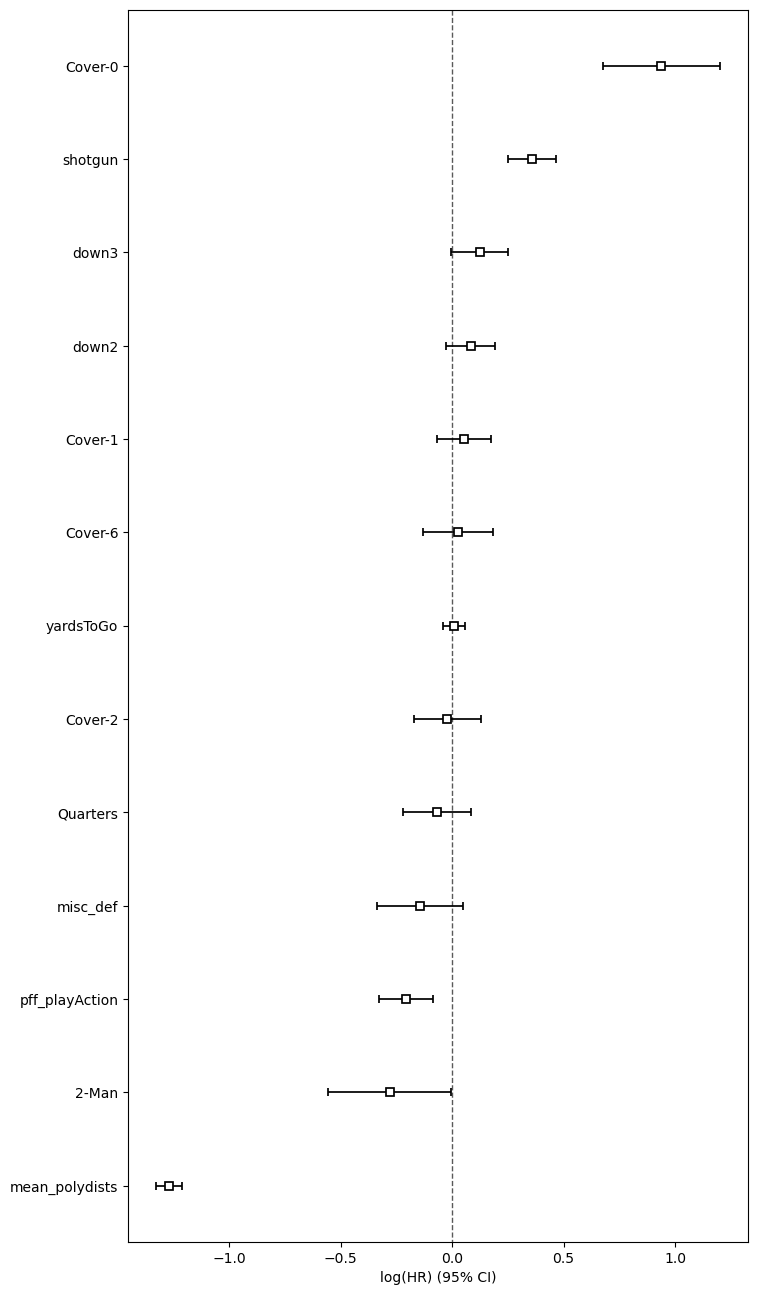

In [ ]:
plt.figure(figsize=(8, 16))
cph.plot()
plt.show()

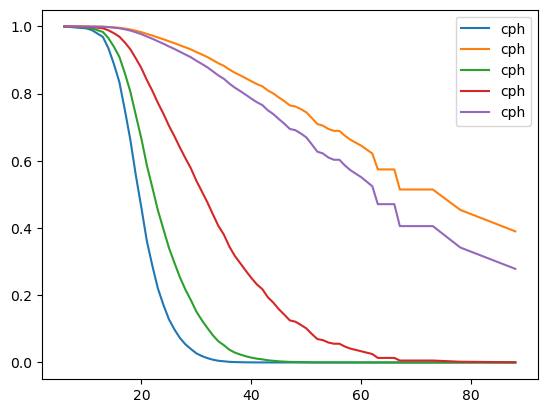

In [151]:
plt.plot(cph.predict_survival_function(Xts.iloc[:5]), label="cph")
plt.legend()
plt.show()

(0.0, 50.0)

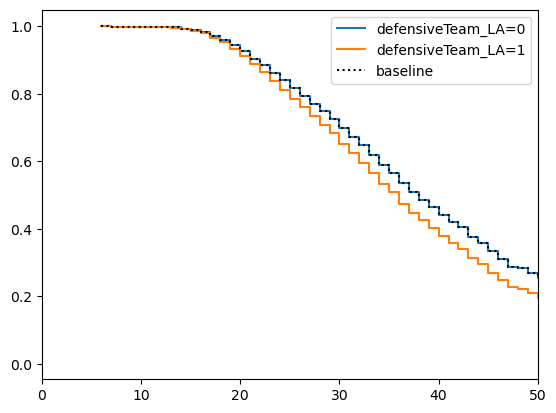

In [ ]:
# aaf.plot_partial_effects_on_outcome("x0", values=[-1, 0, 1, 2])
cph_def.plot_partial_effects_on_outcome(
    "defensiveTeam_LA",
    values=[
        0,
        1,
    ],
)
# cph.plot_partial_effects_on_outcome(["shotgun", "pff_playAction"], values=[[0, 1,],[0, 1,]])
plt.xlim(0, 50)

### Here are some rankings, but there are some wrinkles still: how to account for censoring in predicting life expectancy?

In [ ]:
pred_pocket_uptime = pd.DataFrame(
    cph_offdef.predict_expectation(X[col_subset + def_team_cols + off_team_cols])
).rename(columns={0: "expected_uptime"})
pred_pocket_uptime["actual_uptime"] = Y[["surv_frame", "pass_frame"]].min(axis=1)
pred_pocket_uptime["mean_uptime_over_expected"] = (
    pred_pocket_uptime["actual_uptime"] - pred_pocket_uptime["expected_uptime"]
)
print(pred_pocket_uptime.median(numeric_only=True))
pred_pocket_uptime = pd.concat(
    [
        pred_pocket_uptime,
        plays_with_collapse.iloc[pred_pocket_uptime.index][
            ["gameId", "playId", "possessionTeam", "defensiveTeam"]
        ],
    ],
    axis=1,
)
pred_pocket_uptime.shape

expected_uptime              34.820998
actual_uptime                24.000000
mean_uptime_over_expected    -8.509587
dtype: float64


(8204, 7)

In [ ]:
tpu_off = (
    pred_pocket_uptime.groupby("possessionTeam")[
        ["expected_uptime", "actual_uptime", "mean_uptime_over_expected"]
    ]
    .mean()
    .sort_values("mean_uptime_over_expected", ascending=False)
    .reset_index()
    .merge(
        le_df[["team", "life_expectancy_offense"]],
        left_on="possessionTeam",
        right_on="team",
    )
    .drop(columns=["team"])
)
tpu_off["diff"] = tpu_off["life_expectancy_offense"] - tpu_off["expected_uptime"]
tpu_off

,possessionTeam,expected_uptime,actual_uptime,mean_uptime_over_expected,life_expectancy_offense,diff
0,DET,33.003934,25.565495,-7.438439,30.770195,-2.233739
1,NYG,32.580762,24.775087,-7.805676,32.376395,-0.204367
2,JAX,33.672233,25.412245,-8.259988,29.381058,-4.291175
3,LV,34.199409,25.027559,-9.171850,29.482517,-4.716891
4,CAR,35.180760,25.790210,-9.390550,31.292867,-3.887893
5,DAL,34.418012,24.881890,-9.536122,31.945788,-2.472224
6,HOU,33.684596,23.931915,-9.752681,29.359838,-4.324758
7,ATL,33.871490,24.109489,-9.762001,29.567030,-4.304460
8,TEN,34.425292,24.655431,-9.769861,31.124483,-3.300809
9,LAC,34.400467,24.447876,-9.952590,30.572119,-3.828347


In [ ]:
tpu_def = (
    pred_pocket_uptime.groupby("defensiveTeam")[
        ["expected_uptime", "actual_uptime", "mean_uptime_over_expected"]
    ]
    .mean()
    .sort_values("mean_uptime_over_expected", ascending=True)
    .reset_index()
    .merge(
        le_df[["team", "life_expectancy_defense"]],
        left_on="defensiveTeam",
        right_on="team",
    )
    .drop(columns=["team"])
)
tpu_def["diff"] = tpu_def["life_expectancy_defense"] - tpu_def["expected_uptime"]
tpu_def

,defensiveTeam,expected_uptime,actual_uptime,mean_uptime_over_expected,life_expectancy_defense,diff
0,JAX,41.840940,25.920188,-15.920752,32.328720,-9.512220
1,GB,41.998335,26.494340,-15.503995,34.932079,-7.066255
2,DEN,41.070169,25.867470,-15.202699,32.005239,-9.064930
3,NYG,41.804741,26.789091,-15.015650,32.939296,-8.865445
4,CIN,41.051101,26.286604,-14.764497,32.054750,-8.996352
5,PIT,39.345568,24.842553,-14.503015,30.123296,-9.222272
6,TEN,39.825145,25.687075,-14.138070,31.628602,-8.196543
7,CHI,39.682207,25.774892,-13.907315,32.549189,-7.133018
8,ARI,39.490148,25.583673,-13.906475,32.500640,-6.989508
9,ATL,39.741491,26.684685,-13.056806,32.052377,-7.689114


In [156]:
player_pocket_uptime = pd.merge(
    scouting[scouting.pff_role.isin(["Pass", "Pass Rush", "Pass Block"])][
        ["gameId", "playId", "nflId", "pff_role"]
    ],
    pred_pocket_uptime,
    how="right",
    on=["gameId", "playId"],
)

In [ ]:
ppu = (
    player_pocket_uptime.groupby("nflId")
    .agg(
        {
            "expected_uptime": "mean",
            "actual_uptime": "mean",
            "mean_uptime_over_expected": "mean",
            "playId": "count",
        }
    )
    .rename(columns={"playId": "num_snaps"})
    .sort_values("mean_uptime_over_expected", ascending=True)
    .reset_index()
    .merge(players, on="nflId")
    .drop(columns=["collegeName", "height", "weight", "birthDate"])
)

In [ ]:
ppu[(ppu.num_snaps > 100) & (ppu.officialPosition.isin(["C", "T", "G"]))].sort_values(
    "mean_uptime_over_expected", ascending=False
).head(25)

,nflId,expected_uptime,actual_uptime,mean_uptime_over_expected,num_snaps,officialPosition,displayName
970,43695,31.173635,23.992701,-7.180934,137,C,Matt Skura
958,46090,32.010749,24.654762,-7.355987,252,C,Billy Price
953,46679,32.637719,25.232044,-7.405675,181,C,Evan Brown
947,48455,33.003934,25.565495,-7.438439,313,T,Matt Nelson
948,52483,33.003934,25.565495,-7.438439,313,G,Jonah Jackson
942,37090,32.325922,24.822222,-7.503699,270,T,Nate Solder
940,43453,33.097690,25.569132,-7.528559,311,G,Halapoulivaati Vaitai
939,53436,33.097690,25.569132,-7.528559,311,T,Penei Sewell
928,46089,33.738112,26.038462,-7.699650,130,C,Frank Ragnow
920,46103,32.580762,24.775087,-7.805676,289,G,Will Hernandez


In [ ]:
pd.DataFrame(
    cph_offdef.predict_survival_function(X[col_subset + def_team_cols + off_team_cols]),
    [30],
).T

,30
0,0.307699
1,0.725344
2,0.947927
3,0.556947
4,0.181189
...,...
8199,0.951865
8200,0.554695
8201,0.328965
8202,0.072604


## Inverse Probability of Censoring Weighting
in order to get a better estimate of "observed outcomes" we scale the observed (censoring or event) by the inverse of the probability an observation lasts that long (as can be estimated using KM)

In [ ]:
# set timepoint (e.g. 30 frames)
tau = 30
# survival probability of the pocket as predicted by cph_offdef
pred_surv_rate30 = pd.DataFrame(
    cph_offdef.predict_survival_function(X[col_subset + def_team_cols + off_team_cols]),
    [tau],
).T.rename(columns={tau: "surv_rate"})

In [ ]:
# estimate the probability of an observation to be a certain length
cens_time = Y[["surv_frame", "pass_frame"]].min(axis=1)
cens_event = Y["survived"] | Y.pass_frame.le(
    Y.surv_frame
)  # 1 if pocket did not collapse or pass frame occurs before collapse frame (inverse of coxph event thing)
censor_prob = KaplanMeierFitter().fit(
    cens_time, cens_event
)  # this schould now be an estimate of a observation being not yet censored at time t (maybe this should be a Cox model as well?)

In [162]:
cens_event.value_counts()

True     4750
False    3454
Name: count, dtype: int64

In [163]:
pred_pocket_uptime.head()

,expected_uptime,actual_uptime,mean_uptime_over_expected,gameId,playId,possessionTeam,defensiveTeam
0,20.621667,29,8.378333,2021090900,97,TB,DAL
1,35.326687,23,-12.326687,2021090900,137,DAL,TB
2,65.671927,20,-45.671927,2021090900,187,DAL,TB
3,27.241721,30,2.758279,2021090900,282,DAL,TB
4,18.016280,17,-1.016280,2021090900,349,DAL,TB


In [ ]:
# for each play: pred_surv_rate30 gives us the life expectancy
# inverse weight of censoring
w = 1 / np.maximum(
    censor_prob.survival_function_at_times(times=np.minimum(cens_time, 50)), 1e-6
)

In [ ]:
pred_pocket_uptime["weighting"] = w.values * (1 - cens_event).values

In [ ]:
pred_pocket_uptime["weighted_observed_residuals"] = (
    pred_pocket_uptime["actual_uptime"] - pred_pocket_uptime["expected_uptime"]
) * pred_pocket_uptime["weighting"]

In [167]:
pred_pocket_uptime.head()

,expected_uptime,actual_uptime,mean_uptime_over_expected,gameId,playId,possessionTeam,defensiveTeam,weighting,weighted_observed_residuals
0,20.621667,29,8.378333,2021090900,97,TB,DAL,2.261736,18.949577
1,35.326687,23,-12.326687,2021090900,137,DAL,TB,1.370361,-16.892016
2,65.671927,20,-45.671927,2021090900,187,DAL,TB,0.000000,-0.000000
3,27.241721,30,2.758279,2021090900,282,DAL,TB,2.486580,6.858682
4,18.016280,17,-1.016280,2021090900,349,DAL,TB,1.044339,-1.061340


In [ ]:
ppud = (
    pred_pocket_uptime[pred_pocket_uptime["weighting"].gt(0.0)]
    .groupby("defensiveTeam")["weighted_observed_residuals"]
    .agg(["mean", "count", "std", "sum"])
)
ppud["norm"] = ppud["mean"] / ppud["sum"]
ppud["norm2"] = ppud["mean"] / ppud["sum"].sum()
ppud.sort_values("mean")

,mean,count,std,sum,norm,norm2
defensiveTeam,,,,,,
DEN,0.425476,86,41.434388,36.590959,0.011628,0.000011
NYJ,4.449756,89,16.842578,396.028276,0.011236,0.000110
SEA,4.604584,124,52.421178,570.968452,0.008065,0.000114
PHI,6.254878,112,24.673151,700.546335,0.008929,0.000155
CHI,7.417255,88,45.685390,652.718465,0.011364,0.000183
TB,7.697748,125,37.923349,962.218507,0.008000,0.000190
BAL,8.199613,107,30.258960,877.358586,0.009346,0.000203
CAR,8.428496,122,27.148516,1028.276490,0.008197,0.000208
HOU,8.983451,95,26.183657,853.427892,0.010526,0.000222


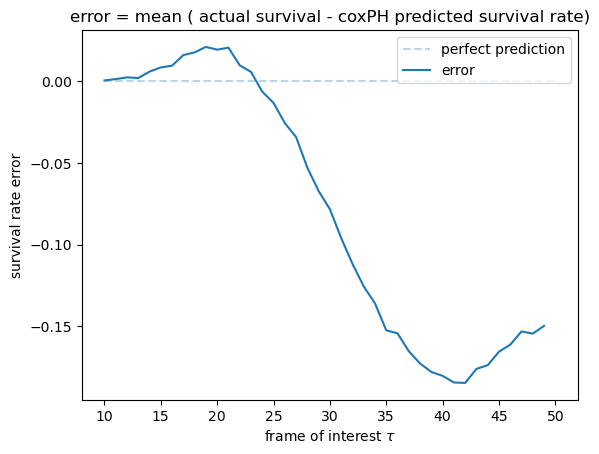

In [ ]:
taus = []
taus_masked = []
for tau in range(10, 50):
    # predict survival rate at time tau
    pred_surv_rate30 = pd.DataFrame(
        cph_offdef.predict_survival_function(
            X[col_subset + def_team_cols + off_team_cols]
        ),
        [tau],
    ).T.rename(columns={tau: "surv_rate"})
    # observe survival
    actual_survival = Y["surv_frame"] >= tau
    pred_surv_rate30["actual_surv"] = actual_survival
    # deviation: 1-surv_rate if survived, 0-surv_rate if died early, mean of surv_res: ~percentage of pockets surviving over expectation
    pred_surv_rate30["surv_res"] = actual_survival - pred_surv_rate30.surv_rate

    pred_surv_rate30 = pd.concat(
        [pred_surv_rate30, X[["defensiveTeam", "possessionTeam"]]], axis=1
    )

    # only look at those that a) collapsed or b) survived >= tau which leaves out censored before tau
    ol = (
        pred_surv_rate30[~Y["survived"] | actual_survival]
        .groupby("possessionTeam")["surv_res"]
        .agg(["mean", "count", "std"])
        .reset_index()
        .sort_values("mean", ascending=False)
        .rename(columns={"mean": "ol_resid_mean"})
    )
    dl = (
        pred_surv_rate30[~Y["survived"] | actual_survival]
        .groupby("defensiveTeam")["surv_res"]
        .agg(["mean", "count", "std"])
        .reset_index()
        .sort_values("mean", ascending=True)
        .rename(columns={"mean": "dl_resid_mean"})
    )

    taus.append(pred_surv_rate30["surv_res"].mean())
    taus_masked.append(
        pred_surv_rate30[~Y["survived"] | actual_survival]["surv_res"].mean()
    )

plt.hlines([0], 10, 50, linestyle="--", alpha=0.3, label="perfect prediction")
# plt.plot(np.arange(10, 50), taus, label="unmasked")
plt.plot(np.arange(10, 50), taus_masked, label="error")
plt.xlabel(r"frame of interest $\tau$")
plt.ylabel("survival rate error")
plt.title("error = mean ( actual survival - coxPH predicted survival rate)")
plt.legend()
plt.show()

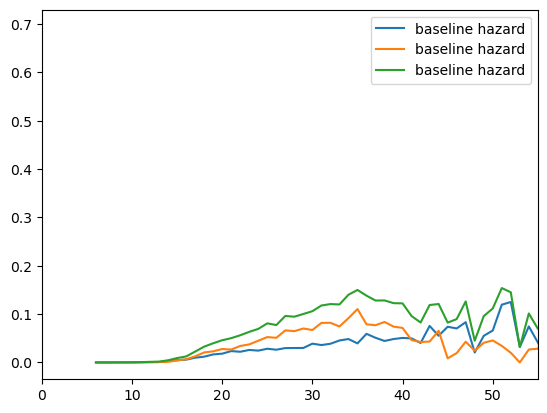

In [ ]:
fig, ax = plt.subplots(1, 1)
cph_offdef.baseline_hazard_.plot(ax=ax, label="collapse")
pass_cox_offdef.baseline_hazard_.plot(ax=ax, label="pass")
(cph_offdef.baseline_hazard_ + pass_cox_offdef.baseline_hazard_).plot(
    ax=ax, label="pass+collapse"
)
plt.legend()
plt.xlim(0, 55)
plt.show()

  0%|          | 0/40 [00:00<?, ?it/s]

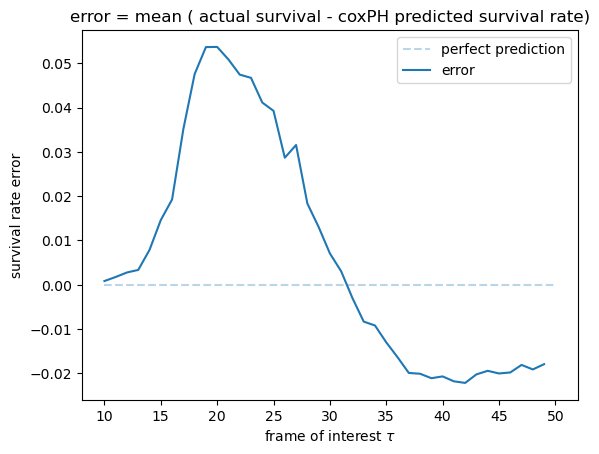

In [ ]:
taus = []
taus_masked = []
for tau in trange(10, 50):
    # predict survival rate at time tau
    pred_surv_rate30 = pd.DataFrame(
        cph_offdef.predict_cumulative_hazard(
            X[col_subset + def_team_cols + off_team_cols]
        ),
        [tau],
    ).T.rename(columns={tau: "collapse_hazard"})
    pred_surv_rate30["pass_hazard"] = pd.DataFrame(
        pass_cox_offdef.predict_cumulative_hazard(
            X[col_subset + def_team_cols + off_team_cols]
        ),
        [tau],
    ).T.rename(columns={tau: "pass_hazard"})["pass_hazard"]
    pred_surv_rate30["agg_hazards"] = (
        pred_surv_rate30["collapse_hazard"] + pred_surv_rate30["pass_hazard"]
    )
    pred_surv_rate30["surv_rate"] = np.exp(-pred_surv_rate30["agg_hazards"])

    actual_survival = (Y["surv_frame"] >= tau) & (Y["pass_frame"] >= tau)
    pred_surv_rate30["actual_surv"] = actual_survival
    # deviation: 1-surv_rate if survived, 0-surv_rate if died early, mean of surv_res: ~percentage of pockets surviving over expectation
    pred_surv_rate30["surv_res"] = actual_survival - pred_surv_rate30.surv_rate

    taus_masked.append(
        pred_surv_rate30[X["pass_event"] | X["event"] | actual_survival][
            "surv_res"
        ].mean()
    )

plt.hlines([0], 10, 50, linestyle="--", alpha=0.3, label="perfect prediction")
# plt.plot(np.arange(10, 50), taus, label="unmasked")
plt.plot(np.arange(10, 50), taus_masked, label="error")
plt.xlabel(r"frame of interest $\tau$")
plt.ylabel("survival rate error")
plt.title("error = mean ( actual survival - coxPH predicted survival rate)")
plt.legend()
plt.show()

## residual survival 

In [ ]:
tau = 25
team_feats = ["none", "off", "def", "offdef"]
col_model = [cph, cph_off, cph_def, cph_offdef]
pass_model = [pass_cox, pass_cox_off, pass_cox_def, pass_cox_offdef]

pred_surv_rate = plays_with_collapse[["gameId", "playId"]].copy()

for tau in trange(20, 51, 5):
    for cmod, pmod, team_feat in zip(col_model, pass_model, team_feats):
        pred_surv_rate[f"collapse_hazard_{tau}_{team_feat}"] = pd.DataFrame(
            cmod.predict_cumulative_hazard(
                X[col_subset + def_team_cols + off_team_cols]
            ),
            [tau],
        ).T.rename(columns={tau: "collapse_hazard"})["collapse_hazard"]
        pred_surv_rate[f"pass_hazard_{tau}_{team_feat}"] = pd.DataFrame(
            pmod.predict_cumulative_hazard(
                X[col_subset + def_team_cols + off_team_cols]
            ),
            [tau],
        ).T.rename(columns={tau: "pass_hazard"})["pass_hazard"]
        pred_surv_rate[f"agg_hazards_{tau}_{team_feat}"] = (
            pred_surv_rate[f"collapse_hazard_{tau}_{team_feat}"]
            + pred_surv_rate[f"pass_hazard_{tau}_{team_feat}"]
        )
        pred_surv_rate[f"surv_rate_{tau}_{team_feat}"] = np.exp(
            -pred_surv_rate[f"agg_hazards_{tau}_{team_feat}"]
        )

        actual_survival = (Y["surv_frame"] >= tau) & (Y["pass_frame"] >= tau)
        pred_surv_rate[f"actual_surv_{tau}_{team_feat}"] = actual_survival
        # deviation: 1-surv_rate if survived, 0-surv_rate if died early, mean of surv_res: ~percentage of pockets surviving over expectation
        pred_surv_rate[f"surv_res_{tau}_{team_feat}"] = (
            actual_survival - pred_surv_rate[f"surv_rate_{tau}_{team_feat}"]
        )

  0%|          | 0/7 [00:00<?, ?it/s]

C:\Users\mschilling\AppData\Local\Temp\ipykernel_21088\1545990126.py:13: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\mschilling\AppData\Local\Temp\ipykernel_21088\1545990126.py:16: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\mschilling\AppData\Local\Temp\ipykernel_21088\1545990126.py:18: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To ge

In [227]:
pred_surv_rate = pred_surv_rate.copy()
pred_surv_rate

,gameId,playId,collapse_hazard_20_none,pass_hazard_20_none,agg_hazards_20_none,surv_rate_20_none,actual_surv_20_none,surv_res_20_none,collapse_hazard_20_off,pass_hazard_20_off,...,agg_hazards_50_def,surv_rate_50_def,actual_surv_50_def,surv_res_50_def,collapse_hazard_50_offdef,pass_hazard_50_offdef,agg_hazards_50_offdef,surv_rate_50_offdef,actual_surv_50_offdef,surv_res_50_offdef
0,2021090900,97,0.165865,0.093251,0.259116,0.771734,True,0.228266,0.217766,0.085173,...,4.729041,0.008835,False,-0.008835,4.690798,1.614656,6.305455,1.826316e-03,False,-1.826316e-03
1,2021090900,137,0.071623,0.158395,0.230018,0.794519,True,0.205481,0.074085,0.173557,...,4.421674,0.012014,False,-0.012014,1.277970,4.296036,5.574006,3.795247e-03,False,-3.795247e-03
2,2021090900,187,0.012970,0.493594,0.506563,0.602563,True,0.397437,0.012368,0.607762,...,10.752331,0.000021,False,-0.000021,0.212834,15.685030,15.897864,1.246366e-07,False,-1.246366e-07
3,2021090900,282,0.127950,0.040356,0.168306,0.845095,True,0.154905,0.134903,0.042829,...,3.024234,0.048595,False,-0.048595,2.329355,1.045753,3.375108,3.421441e-02,False,-3.421441e-02
4,2021090900,349,0.349994,0.042453,0.392447,0.675402,False,-0.675402,0.383706,0.041518,...,7.036655,0.000879,False,-0.000879,6.798451,1.011865,7.810316,4.055298e-04,False,-4.055298e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8199,2021110100,4113,0.011612,0.323792,0.335405,0.715049,True,0.284951,0.011620,0.260310,...,5.140488,0.005855,False,-0.005855,0.196334,4.323029,4.519363,1.089596e-02,False,-1.089596e-02
8200,2021110100,4310,0.124604,0.062043,0.186647,0.829736,True,0.170264,0.134695,0.043457,...,2.750998,0.063864,False,-0.063864,2.345477,0.657401,3.002878,4.964398e-02,False,-4.964398e-02
8201,2021110100,4363,0.156946,0.079395,0.236341,0.789511,True,0.210489,0.236229,0.076067,...,3.894786,0.020348,False,-0.020348,4.424833,1.461361,5.886194,2.777527e-03,False,-2.777527e-03
8202,2021110100,4392,0.351683,0.059797,0.411479,0.662669,True,0.337331,0.548721,0.053694,...,7.186449,0.000757,False,-0.000757,10.438122,1.028554,11.466677,1.047335e-05,False,-1.047335e-05


In [ ]:
pred_surv_rate = pd.concat(
    [pred_surv_rate, X[["defensiveTeam", "possessionTeam"]]], axis=1
)

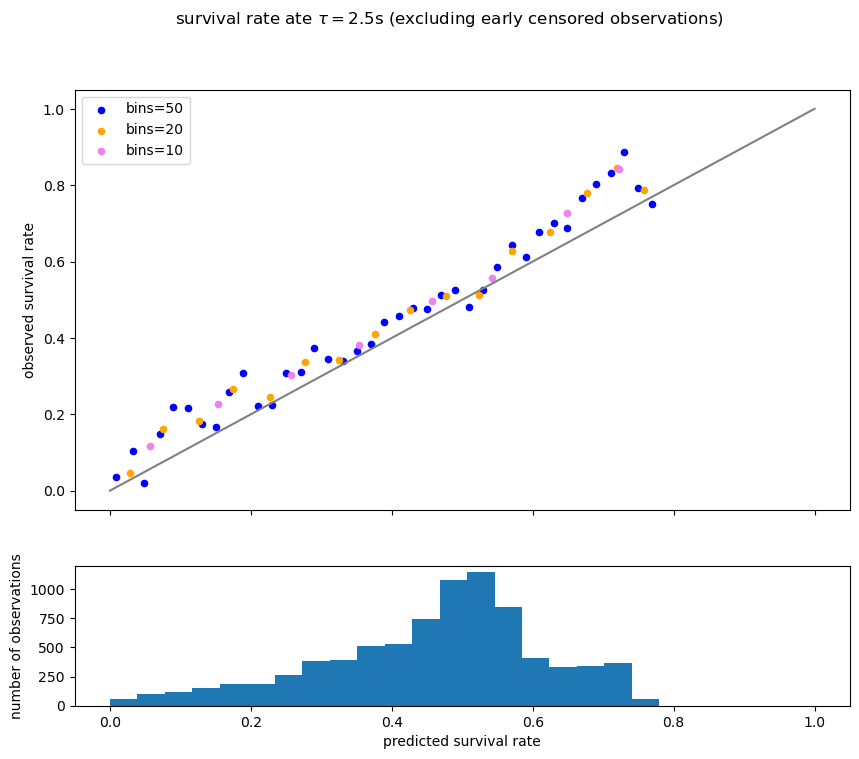

In [ ]:
tau = 25
team_feat = "none"

fig, ax = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)

pred_surv_rate[
    X["pass_event"] | X["event"] | pred_surv_rate[f"actual_surv_{tau}_{team_feat}"]
].groupby(pred_surv_rate[f"surv_rate_{tau}_{team_feat}"] * 100 // 2)[
    [f"actual_surv_{tau}_{team_feat}", f"surv_rate_{tau}_{team_feat}"]
].mean().plot.scatter(
    x=f"surv_rate_{tau}_{team_feat}",
    y=f"actual_surv_{tau}_{team_feat}",
    ax=ax[0],
    label="bins=50",
    color="blue",
)
pred_surv_rate[
    X["pass_event"] | X["event"] | pred_surv_rate[f"actual_surv_{tau}_{team_feat}"]
].groupby(pred_surv_rate[f"surv_rate_{tau}_{team_feat}"] * 100 // 5)[
    [f"actual_surv_{tau}_{team_feat}", f"surv_rate_{tau}_{team_feat}"]
].mean().plot.scatter(
    x=f"surv_rate_{tau}_{team_feat}",
    y=f"actual_surv_{tau}_{team_feat}",
    ax=ax[0],
    label="bins=20",
    color="orange",
)
pred_surv_rate[
    X["pass_event"] | X["event"] | pred_surv_rate[f"actual_surv_{tau}_{team_feat}"]
].groupby(pred_surv_rate[f"surv_rate_{tau}_{team_feat}"] * 100 // 10)[
    [f"actual_surv_{tau}_{team_feat}", f"surv_rate_{tau}_{team_feat}"]
].mean().plot.scatter(
    x=f"surv_rate_{tau}_{team_feat}",
    y=f"actual_surv_{tau}_{team_feat}",
    ax=ax[0],
    label="bins=10",
    color="violet",
)
ax[0].plot(np.linspace(0, 1, 20), np.linspace(0, 1, 20), color="gray")
ax[1].hist(pred_surv_rate[f"surv_rate_{tau}_{team_feat}"], bins=20)
ax[1].set_xlabel("predicted survival rate")
ax[0].set_ylabel("observed survival rate")
ax[1].set_ylabel("number of observations")
fig.suptitle(
    r"survival rate ate $\tau=$"
    + f"{tau/10:3.1f}s (excluding early censored observations)"
)
plt.show()

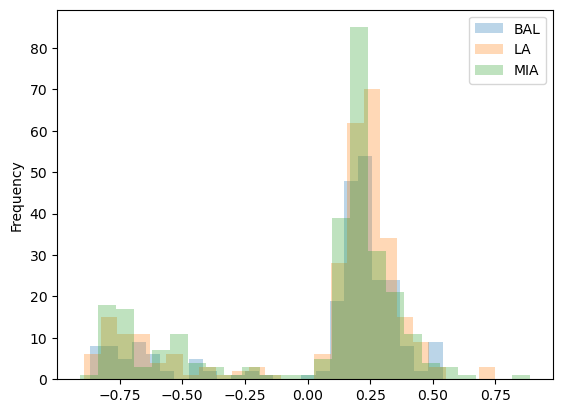

In [ ]:
tau = 20
team_feat = "off"

pred_surv_rate[
    (X["pass_event"] | X["event"] | actual_survival)
    & (pred_surv_rate["defensiveTeam"] == "BAL")
][f"surv_res_{tau}_{team_feat}"].plot.hist(bins=25, label="BAL", alpha=0.3)
pred_surv_rate[
    (X["pass_event"] | X["event"] | actual_survival)
    & (pred_surv_rate["defensiveTeam"] == "LA")
][f"surv_res_{tau}_{team_feat}"].plot.hist(bins=25, label="LA", alpha=0.3)
pred_surv_rate[
    (X["pass_event"] | X["event"] | actual_survival)
    & (pred_surv_rate["defensiveTeam"] == "MIA")
][f"surv_res_{tau}_{team_feat}"].plot.hist(bins=25, label="MIA", alpha=0.3)
plt.legend()
plt.show()

In [ ]:
tau = 20
team_feat = "off"

ol_aggs = []
dl_aggs = []

# only look at those that a) collapsed or b) survived >= tau which leaves out censored before tau
for tau in range(20, 51, 5):
    ol_aggs.append(
        pred_surv_rate[X["pass_event"] | X["event"] | actual_survival]
        .groupby("possessionTeam")[f"surv_res_{tau}_def"]
        .agg(["mean", "count"])
        .sort_values("mean", ascending=False)
        .rename(columns={"mean": f"ol_resid_mean_{tau}"})
    )
    dl_aggs.append(
        pred_surv_rate[X["pass_event"] | X["event"] | actual_survival]
        .groupby("defensiveTeam")[f"surv_res_{tau}_off"]
        .agg(["mean", "count"])
        .sort_values("mean", ascending=True)
        .rename(columns={"mean": f"dl_resid_mean_{tau}"})
    )

ol_aggs = pd.concat(ol_aggs, axis=1)
dl_aggs = pd.concat(dl_aggs, axis=1)

In [278]:
ol_aggs[[f"ol_resid_mean_{ti}" for ti in range(20, 41, 5)]].corr(method="spearman")

,ol_resid_mean_20,ol_resid_mean_25,ol_resid_mean_30,ol_resid_mean_35,ol_resid_mean_40
ol_resid_mean_20,1.000000,0.676686,0.449413,0.398827,0.357771
ol_resid_mean_25,0.676686,1.000000,0.776026,0.664223,0.486070
ol_resid_mean_30,0.449413,0.776026,1.000000,0.934384,0.735337
ol_resid_mean_35,0.398827,0.664223,0.934384,1.000000,0.863270
ol_resid_mean_40,0.357771,0.486070,0.735337,0.863270,1.000000


In [279]:
dl_aggs[[f"dl_resid_mean_{ti}" for ti in range(20, 41, 5)]].corr(method="spearman")

,dl_resid_mean_20,dl_resid_mean_25,dl_resid_mean_30,dl_resid_mean_35,dl_resid_mean_40
dl_resid_mean_20,1.000000,0.506232,0.197214,0.126833,0.093842
dl_resid_mean_25,0.506232,1.000000,0.664589,0.515762,0.248167
dl_resid_mean_30,0.197214,0.664589,1.000000,0.732771,0.565982
dl_resid_mean_35,0.126833,0.515762,0.732771,1.000000,0.767595
dl_resid_mean_40,0.093842,0.248167,0.565982,0.767595,1.000000


In [ ]:
ol_aggs[[f"ol_resid_mean_{ti}" for ti in range(20, 41, 5)]].sort_values(
    "ol_resid_mean_30", ascending=False
)

,ol_resid_mean_20,ol_resid_mean_25,ol_resid_mean_30,ol_resid_mean_35,ol_resid_mean_40
possessionTeam,,,,,
BAL,0.088706,0.128845,0.094806,0.026673,-0.011695
PHI,0.113059,0.115933,0.089759,0.061062,0.024950
CLE,0.066199,0.103692,0.084342,0.027032,-0.002897
NO,0.104328,0.148468,0.081442,0.063528,0.038396
ARI,0.066287,0.075052,0.069913,0.026462,0.001249
KC,0.038132,0.034171,0.052669,0.043077,0.009413
LA,0.022751,0.075570,0.050530,0.022123,-0.024699
IND,0.064089,0.073932,0.037933,-0.006892,-0.031673
BUF,0.044239,0.080741,0.027025,-0.013266,-0.029326


In [ ]:
dl_aggs[[f"dl_resid_mean_{ti}" for ti in range(20, 41, 5)]].sort_values(
    "dl_resid_mean_30", ascending=True
)

,dl_resid_mean_20,dl_resid_mean_25,dl_resid_mean_30,dl_resid_mean_35,dl_resid_mean_40
defensiveTeam,,,,,
PIT,0.072772,-0.065120,-0.087319,-0.051382,-0.039296
PHI,0.026028,-0.034885,-0.077882,-0.050347,-0.036394
CAR,-0.014707,-0.084054,-0.061529,-0.026524,-0.030771
WAS,0.024460,-0.020155,-0.050594,-0.061628,-0.048645
NYJ,0.080374,0.017209,-0.040269,-0.049530,-0.031502
MIN,0.075123,0.079985,-0.039427,-0.047653,-0.052979
BAL,0.066111,-0.013430,-0.036658,-0.017572,-0.024798
HOU,0.062210,0.011803,-0.035713,-0.060423,-0.045291
ATL,0.062369,-0.013160,-0.028851,-0.025233,-0.027651


#### now we got "overall survival based on pass hazard and collapse hazard", what we are actually interested in is the likelihood of failing due to pocket collapse by $\tau$

In [ ]:
# def cum_collapse_prob(X:pd.DataFrame, collapse_cox, pass_cox, tau:int=30):
# (including .T) computes dataframe of shape num_samples x num_timesteps
feat_cols = [
    col_subset,
    col_subset + off_team_cols,
    col_subset + def_team_cols,
    col_subset + def_team_cols + off_team_cols,
]


for tau in trange(20, 51, 5):
    for cmod, pmod, team_feat, mcols in zip(
        col_model, pass_model, team_feats, feat_cols
    ):
        times = np.arange(tau + 1)

        cum_hazard_collapse = cmod.predict_cumulative_hazard(X[mcols], times=times).T
        diff_hazard_collapse = cum_hazard_collapse.diff(axis=1).fillna(0.0)

        cum_hazard_pass = pmod.predict_cumulative_hazard(X[mcols], times=times).T
        diff_hazard_pass = cum_hazard_pass.diff(axis=1).fillna(0.0)

        cum_hazard_agg = cum_hazard_pass + cum_hazard_collapse
        diff_hazard_agg = cum_hazard_agg.diff(axis=1).fillna(0.0)
        agg_survival = np.exp(-cum_hazard_agg).shift(axis=1, periods=1, fill_value=1.0)

        cif_c = (
            agg_survival
            * (1 - np.exp(-diff_hazard_agg))
            * diff_hazard_collapse
            / diff_hazard_agg
        ).sum(axis=1)
        cif_p = (
            agg_survival
            * (1 - np.exp(-diff_hazard_agg))
            * diff_hazard_pass
            / diff_hazard_agg
        ).sum(axis=1)

        pred_surv_rate[f"cif_c_{tau}_{team_feat}"] = cif_c
        pred_surv_rate[f"cif_p_{tau}_{team_feat}"] = cif_p
        pred_surv_rate[f"tilt_expected_{tau}_{team_feat}"] = cif_c / (cif_c + cif_p)

        pred_surv_rate[f"collapse_before_tau_{tau}_{team_feat}"] = Y["surv_frame"].le(
            tau
        ) & Y["surv_frame"].lt(Y["pass_frame"])
        pred_surv_rate[f"pass_before_tau_{tau}_{team_feat}"] = Y["pass_frame"].le(
            tau
        ) & Y["pass_frame"].le(Y["surv_frame"])
        pred_surv_rate[f"surv_tau_{tau}_{team_feat}"] = Y["surv_frame"].gt(tau) & Y[
            "pass_frame"
        ].gt(tau)

        pred_surv_rate[f"pass_residual_{tau}_{team_feat}"] = (
            pred_surv_rate[f"pass_before_tau_{tau}_{team_feat}"] - cif_p
        )  # pass - expected collapse
        pred_surv_rate[f"collapse_residual_{tau}_{team_feat}"] = (
            pred_surv_rate[f"collapse_before_tau_{tau}_{team_feat}"] - cif_c
        )  # collapse - expected collapse
        pred_surv_rate[f"surv_residual_{tau}_{team_feat}"] = pred_surv_rate[
            f"surv_tau_{tau}_{team_feat}"
        ] - (
            1 - cif_p - cif_c
        )  # survived - survival prob
        # shit does not add up

pred_surv_rate = pred_surv_rate.copy()
## sanity check:
for tau in trange(20, 51, 5):
    for cmod, pmod, team_feat, mcols in zip(
        col_model, pass_model, team_feats, feat_cols
    ):
        if (
            abs(
                pred_surv_rate[f"pass_residual_{tau}_{team_feat}"]
                + pred_surv_rate[f"collapse_residual_{tau}_{team_feat}"]
                + pred_surv_rate[f"surv_residual_{tau}_{team_feat}"]
            )
            > 1e-9
        ):
            print(f"res_sum_{tau}_{team_feat}")
        if (
            pred_surv_rate[f"cif_p_{tau}_{team_feat}"]
            + pred_surv_rate[f"cif_c_{tau}_{team_feat}"]
        ).abs() > 1:
            print(f"cif_sum_{tau}_{team_feat}")

  0%|          | 0/7 [00:00<?, ?it/s]

count    8.204000e+03
mean    -1.707447e-19
std      2.645548e-17
min     -1.110223e-16
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.110223e-16
dtype: float64
count    8204.000000
mean        0.878502
std         0.102171
min         0.488613
25%         0.828054
50%         0.899848
75%         0.959931
max         0.998983
dtype: float64


In [ ]:
for tau in trange(20, 51, 5):
    for cmod, pmod, team_feat, mcols in zip(
        col_model, pass_model, team_feats, feat_cols
    ):
        if (
            pred_surv_rate[f"pass_residual_{tau}_{team_feat}"]
            + pred_surv_rate[f"collapse_residual_{tau}_{team_feat}"]
            + pred_surv_rate[f"surv_residual_{tau}_{team_feat}"]
        ).between(-1e-9, 1e-9).sum() < (len(pred_surv_rate)):
            print(f"res_sum_{tau}_{team_feat}")
        if (
            pred_surv_rate[f"cif_p_{tau}_{team_feat}"]
            + pred_surv_rate[f"cif_c_{tau}_{team_feat}"]
        ).between(0, 1, inclusive="both").sum() < (len(pred_surv_rate)):
            print(f"cif_sum_{tau}_{team_feat}")

  0%|          | 0/7 [00:00<?, ?it/s]

In [362]:
tau = 35

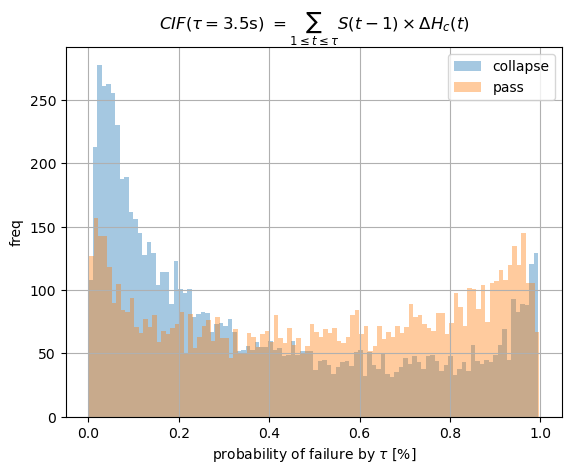

In [ ]:
pred_surv_rate.loc[
    (X["pass_event"] | X["event"] | actual_survival), f"cif_c_{tau}_offdef"
].hist(bins=100, label="collapse", alpha=0.4)
pred_surv_rate.loc[
    (X["pass_event"] | X["event"] | actual_survival), f"cif_p_{tau}_offdef"
].hist(bins=100, label="pass", alpha=0.4)
plt.title(
    r"$CIF(\tau=$"
    + f"{tau/10:3.1f}s)"
    + r" $= \sum_{1 \leq t \leq \tau} S(t-1) \times \Delta H_c (t)$"
)
plt.ylabel("freq")
plt.xlabel(r"probability of failure by $\tau$ [%]")
plt.legend()
plt.show()

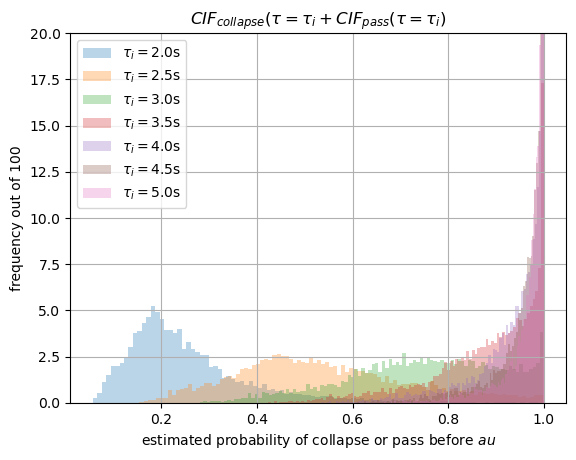

In [ ]:
for tau in range(20, 51, 5):
    (
        pred_surv_rate[f"cif_c_{tau}_{team_feat}"]
        + pred_surv_rate[f"cif_p_{tau}_{team_feat}"]
    ).hist(bins=100, density=True, label=r"$\tau_i=$" + f"{tau/10:3.1f}s", alpha=0.3)
plt.title(r"$CIF_{collapse}(\tau=\tau_i + CIF_{pass} (\tau=\tau_i)$")
plt.xlabel("estimated probability of collapse or pass before $\tau$")
plt.ylabel("frequency out of 100")
plt.ylim(0, 20)
plt.legend()
plt.show()

## first, we analyse which teams are expected to have longer or shorter pocket collapses (based on opponent + game context ) 

In [ ]:
cct_off = pred_surv_rate.groupby("possessionTeam")[
    [f"cif_c_{tau}_def" for tau in range(20, 51, 5)]
    + [f"cif_p_{tau}_def" for tau in range(20, 51, 5)]
].mean()
for tau in range(20, 51, 5):
    cct_off[f"tilt_{tau}"] = cct_off[f"cif_c_{tau}_def"] / (
        cct_off[f"cif_c_{tau}_def"] + cct_off[f"cif_p_{tau}_def"]
    )  # risk of collapse vs pass
cct_off.sort_values("tilt_30", ascending=True)

,cif_c_20_def,cif_c_25_def,cif_c_30_def,cif_c_35_def,cif_c_40_def,cif_c_45_def,cif_c_50_def,cif_p_20_def,cif_p_25_def,cif_p_30_def,...,cif_p_40_def,cif_p_45_def,cif_p_50_def,tilt_20,tilt_25,tilt_30,tilt_35,tilt_40,tilt_45,tilt_50
possessionTeam,,,,,,,,,,,,,,,,,,,,,
PIT,0.065214,0.137178,0.187688,0.222227,0.242248,0.254207,0.261350,0.166446,0.378507,0.553366,...,0.694109,0.705197,0.711030,0.281507,0.266010,0.253272,0.253054,0.258713,0.264964,0.268774
TB,0.083116,0.169811,0.228630,0.267905,0.290520,0.304082,0.312192,0.158682,0.357028,0.516640,...,0.642841,0.652830,0.658070,0.343743,0.322320,0.306775,0.305635,0.311262,0.317774,0.321761
BAL,0.084639,0.172220,0.230579,0.269579,0.292325,0.306209,0.314683,0.154444,0.344244,0.498007,...,0.627560,0.639090,0.645545,0.354014,0.333460,0.316475,0.313397,0.317784,0.323928,0.327717
LA,0.096430,0.191417,0.250968,0.288275,0.308650,0.320415,0.327349,0.157740,0.351566,0.506632,...,0.629342,0.639133,0.644353,0.379390,0.352528,0.331268,0.325981,0.329054,0.333923,0.336882
ARI,0.109447,0.210565,0.272561,0.312024,0.334183,0.347135,0.354671,0.144118,0.325932,0.475413,...,0.598563,0.608867,0.614499,0.431633,0.392481,0.364399,0.356038,0.358278,0.363111,0.365954
KC,0.107689,0.212781,0.280379,0.323596,0.347470,0.361232,0.369187,0.149886,0.333291,0.477949,...,0.589682,0.598368,0.602910,0.418089,0.389658,0.369734,0.366334,0.370772,0.376440,0.379784
GB,0.111417,0.216781,0.285388,0.331027,0.357530,0.373447,0.382859,0.135226,0.306839,0.449569,...,0.569294,0.579319,0.584641,0.451734,0.414005,0.388306,0.381881,0.385758,0.391961,0.395720
CLE,0.117418,0.231758,0.303101,0.347309,0.370885,0.384008,0.391441,0.138668,0.309910,0.450325,...,0.565172,0.574649,0.579749,0.458509,0.427860,0.402297,0.394338,0.396220,0.400569,0.403053
BUF,0.126689,0.239631,0.308680,0.352387,0.377012,0.391658,0.400325,0.140973,0.312949,0.449090,...,0.557191,0.565878,0.570408,0.473316,0.433659,0.407353,0.400425,0.403565,0.409027,0.412395


In [ ]:
cct_def = pred_surv_rate.groupby("defensiveTeam")[
    [f"cif_c_{tau}_off" for tau in range(20, 51, 5)]
    + [f"cif_p_{tau}_off" for tau in range(20, 51, 5)]
].mean()
for tau in range(20, 51, 5):
    cct_def[f"tilt_{tau}"] = cct_def[f"cif_c_{tau}_off"] / (
        cct_def[f"cif_c_{tau}_off"] + cct_def[f"cif_p_{tau}_off"]
    )  # risk of collapse vs pass
cct_def.sort_values("tilt_30", ascending=False)

,cif_c_20_off,cif_c_25_off,cif_c_30_off,cif_c_35_off,cif_c_40_off,cif_c_45_off,cif_c_50_off,cif_p_20_off,cif_p_25_off,cif_p_30_off,...,cif_p_40_off,cif_p_45_off,cif_p_50_off,tilt_20,tilt_25,tilt_30,tilt_35,tilt_40,tilt_45,tilt_50
defensiveTeam,,,,,,,,,,,,,,,,,,,,,
PHI,0.145737,0.288505,0.378222,0.434060,0.463056,0.478144,0.486311,0.110170,0.253733,0.377398,...,0.481857,0.489901,0.493755,0.569493,0.532063,0.500545,0.489244,0.490051,0.493927,0.496202
HOU,0.141498,0.273610,0.355775,0.409549,0.440511,0.458809,0.469943,0.099118,0.233609,0.357501,...,0.476379,0.487302,0.493085,0.588067,0.539432,0.498790,0.481505,0.480440,0.484942,0.487985
MIA,0.154052,0.284975,0.363169,0.411837,0.438252,0.453036,0.461649,0.119911,0.270782,0.396411,...,0.501094,0.509436,0.513558,0.562310,0.512769,0.478118,0.465916,0.466550,0.470701,0.473385
CAR,0.165101,0.295602,0.366970,0.408305,0.429486,0.440968,0.447642,0.123058,0.278843,0.409163,...,0.516724,0.525216,0.529545,0.572951,0.514587,0.472818,0.455943,0.453901,0.456402,0.458093
TEN,0.136374,0.262575,0.340614,0.391208,0.419955,0.436689,0.446729,0.108385,0.253807,0.384562,...,0.503887,0.514306,0.519776,0.557177,0.508491,0.469699,0.454588,0.454575,0.459192,0.462211
IND,0.142786,0.271989,0.349157,0.396992,0.422875,0.437413,0.446010,0.115658,0.265332,0.394532,...,0.508218,0.518018,0.523186,0.552484,0.506195,0.469494,0.454916,0.454171,0.457818,0.460186
KC,0.128443,0.252482,0.329285,0.378020,0.405075,0.420707,0.430262,0.116500,0.260873,0.387678,...,0.508876,0.520566,0.527066,0.524378,0.491828,0.459277,0.444562,0.443213,0.446955,0.449440
WAS,0.135181,0.261343,0.339610,0.388851,0.415425,0.430148,0.438702,0.119556,0.274222,0.407158,...,0.521084,0.530347,0.535030,0.530670,0.487976,0.454774,0.442842,0.443589,0.447840,0.450536
MIN,0.125619,0.246433,0.321755,0.369720,0.396111,0.411083,0.420030,0.111193,0.261997,0.400073,...,0.529061,0.540484,0.546525,0.530457,0.484695,0.445750,0.429339,0.428148,0.432007,0.434564


In [ ]:
tau = 30
agg_cols = [
    f"cif_p_{tau}_def",
    f"cif_c_{tau}_def",
    f"tilt_expected_{tau}_def",
    f"pass_before_tau_{tau}_def",
    f"pass_residual_{tau}_def",
    f"collapse_before_tau_{tau}_def",
    f"collapse_residual_{tau}_def",
    f"surv_tau_{tau}_def",
    f"surv_residual_{tau}_def",
]

res_off = pred_surv_rate.groupby("possessionTeam")[agg_cols].mean()
res_off["tilt_actual"] = res_off[f"collapse_before_tau_{tau}_def"] / (
    res_off[f"collapse_before_tau_{tau}_def"] + res_off[f"pass_before_tau_{tau}_def"]
)
res_off.sort_values(f"tilt_actual", ascending=True)

,cif_p_30_def,cif_c_30_def,tilt_expected_30_def,pass_before_tau_30_def,pass_residual_30_def,collapse_before_tau_30_def,collapse_residual_30_def,surv_tau_30_def,surv_residual_30_def,tilt_actual
possessionTeam,,,,,,,,,,
PIT,0.553366,0.187688,0.265448,0.606987,0.053621,0.288210,0.100521,0.104803,-0.154142,0.321951
CIN,0.439734,0.302717,0.403905,0.552846,0.113111,0.288618,-0.014099,0.158537,-0.099012,0.342995
TB,0.516640,0.228630,0.318310,0.528239,0.011599,0.285714,0.057085,0.186047,-0.068684,0.351020
GB,0.449569,0.285388,0.390499,0.506977,0.057407,0.274419,-0.010969,0.218605,-0.046438,0.351190
CLE,0.450325,0.303101,0.396870,0.463203,0.012879,0.251082,-0.052019,0.285714,0.039140,0.351515
DEN,0.385168,0.354531,0.461691,0.487365,0.102197,0.267148,-0.087383,0.245487,-0.014814,0.354067
CHI,0.416949,0.314770,0.415416,0.483193,0.066244,0.273109,-0.041661,0.243697,-0.024583,0.361111
LA,0.506632,0.250968,0.332277,0.475410,-0.031222,0.278689,0.027720,0.245902,0.003502,0.369565
ATL,0.415066,0.358649,0.452249,0.532847,0.117780,0.332117,-0.026532,0.135036,-0.091248,0.383966


In [ ]:
tau = 25
agg_cols_def = [
    f"cif_p_{tau}_off",
    f"cif_c_{tau}_off",
    f"tilt_expected_{tau}_def",
    f"pass_before_tau_{tau}_off",
    f"pass_residual_{tau}_off",
    f"collapse_before_tau_{tau}_off",
    f"collapse_residual_{tau}_off",
    f"surv_tau_{tau}_off",
    f"surv_residual_{tau}_off",
]

res_def = pred_surv_rate.groupby("defensiveTeam")[agg_cols_def].mean()
res_def.sort_values(f"collapse_residual_{tau}_off", ascending=False)

,cif_p_25_off,cif_c_25_off,tilt_expected_25_def,pass_before_tau_25_off,pass_residual_25_off,collapse_before_tau_25_off,collapse_residual_25_off,surv_tau_25_off,surv_residual_25_off
defensiveTeam,,,,,,,,,
CAR,0.278843,0.295602,0.503261,0.339921,0.061078,0.363636,0.068034,0.296443,-0.129112
CLE,0.292946,0.259719,0.447564,0.303644,0.010697,0.315789,0.056071,0.380567,-0.066768
ATL,0.273470,0.216222,0.417035,0.247748,-0.025722,0.261261,0.045040,0.490991,-0.019317
DAL,0.303745,0.254284,0.447025,0.287402,-0.016344,0.295276,0.040992,0.417323,-0.024648
MIA,0.270782,0.284975,0.497581,0.277193,0.006411,0.315789,0.030814,0.407018,-0.037226
BAL,0.303904,0.258097,0.469414,0.334677,0.030774,0.286290,0.028193,0.379032,-0.058967
TEN,0.253807,0.262575,0.447468,0.289116,0.035309,0.285714,0.023139,0.425170,-0.058448
KC,0.260873,0.252482,0.464543,0.282869,0.021995,0.274900,0.022418,0.442231,-0.044414
MIN,0.261997,0.246433,0.484873,0.262500,0.000503,0.266667,0.020234,0.470833,-0.020737


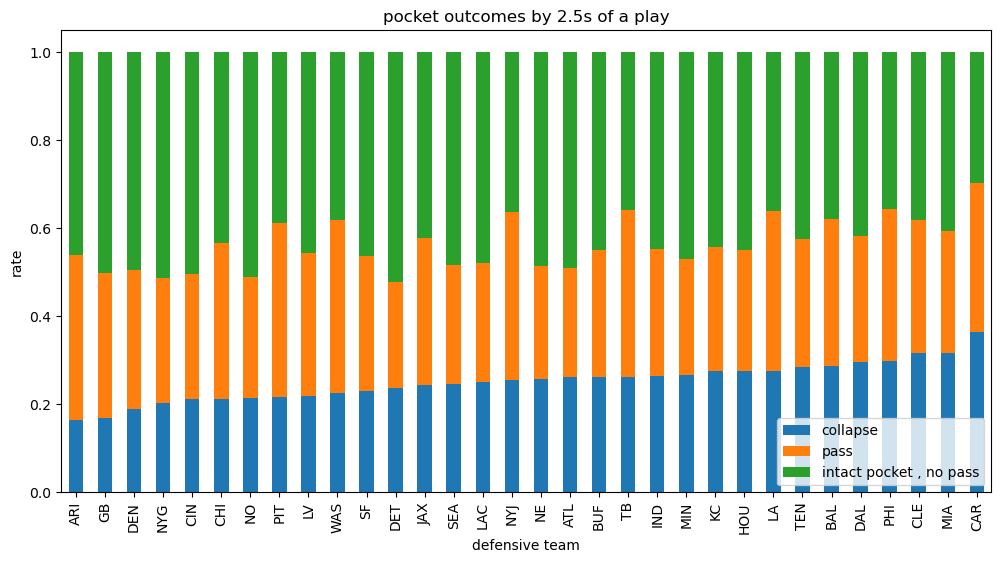

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
res_def[
    [
        f"collapse_before_tau_{tau}_off",
        f"pass_before_tau_{tau}_off",
        f"surv_tau_{tau}_off",
    ]
].sort_values(f"collapse_before_tau_{tau}_off").plot.bar(stacked=True, ax=ax)
ax.legend(["collapse", "pass", "intact pocket , no pass"], loc="lower right")
plt.xlabel("defensive team")
plt.ylabel("rate")
plt.title(f"pocket outcomes by {tau/10:3.1f}s of a play")
plt.show()

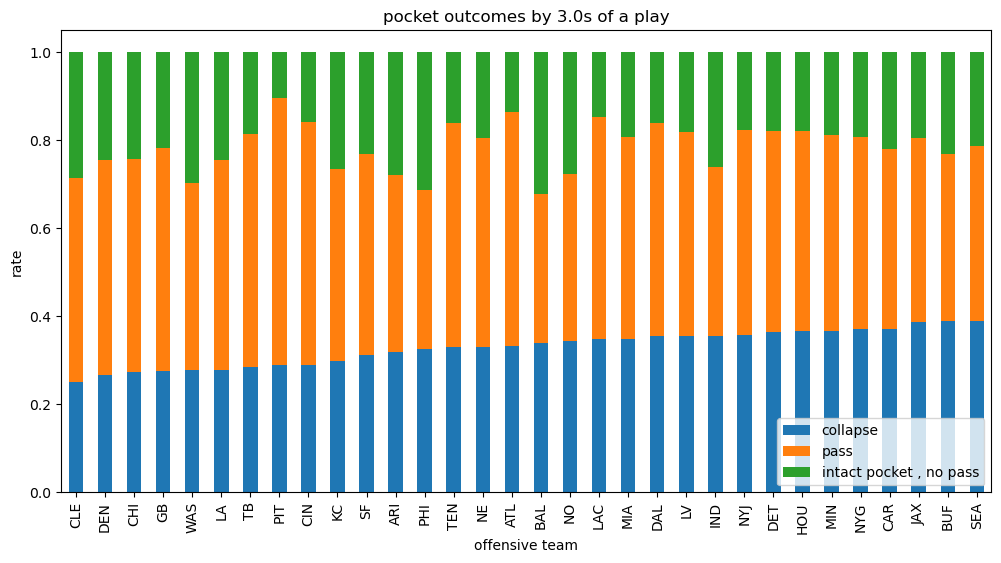

In [ ]:
tau = 30
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
res_off[
    [
        f"collapse_before_tau_{tau}_def",
        f"pass_before_tau_{tau}_def",
        f"surv_tau_{tau}_def",
    ]
].sort_values(f"collapse_before_tau_{tau}_def").plot.bar(stacked=True, ax=ax)
ax.legend(["collapse", "pass", "intact pocket , no pass"], loc="lower right")
plt.xlabel("offensive team")
plt.ylabel("rate")
plt.title(f"pocket outcomes by {tau/10:3.1f}s of a play")
plt.show()

In [370]:
player_pocket_uptime = pd.merge(
    scouting[scouting.pff_role.isin(["Pass", "Pass Rush", "Pass Block"])][
        ["gameId", "playId", "nflId", "pff_role"]
    ],
    pred_surv_rate,
    how="right",
    on=["gameId", "playId"],
)

In [ ]:
def_time_delta = []

for tau in range(20, 41, 5):
    agg_cols_delta_def = [
        f"cif_p_{tau}_off",
        f"cif_c_{tau}_off",
        f"pass_before_tau_{tau}_off",
        f"collapse_before_tau_{tau}_off",
        f"surv_tau_{tau}_off",
    ]

    delta_def = pred_surv_rate.groupby("defensiveTeam")[agg_cols_delta_def].mean()
    delta_def["tau"] = tau / 10
    delta_def["exp_surv"] = (
        1 - delta_def[f"cif_p_{tau}_off"] - delta_def[f"cif_c_{tau}_off"]
    )
    delta_def.rename(columns={c: c[:-7] for c in agg_cols_delta_def}, inplace=True)
    def_time_delta.append(delta_def.reset_index())

delta_def = pd.concat(def_time_delta, ignore_index=True)

In [ ]:
delta_def["collapse_res"] = delta_def.collapse_before_tau - delta_def.cif_c
delta_def[delta_def.tau == 3].sort_values("exp_surv", ascending=False).drop(
    columns=["tau"]
)

,defensiveTeam,cif_p,cif_c,pass_before_tau,collapse_before_tau,surv_tau,exp_surv,collapse_res
65,ATL,0.414811,0.288232,0.445946,0.306306,0.247748,0.296957,0.018075
81,LAC,0.392895,0.312418,0.390698,0.316279,0.293023,0.294688,0.003862
76,HOU,0.357501,0.355775,0.435556,0.346667,0.217778,0.286725,-0.009108
74,DET,0.405684,0.309094,0.398148,0.305556,0.296296,0.285221,-0.003539
79,KC,0.387678,0.329285,0.394422,0.342629,0.262948,0.283037,0.013345
84,MIN,0.400073,0.321755,0.425000,0.358333,0.216667,0.278172,0.036579
94,TEN,0.384562,0.340614,0.418367,0.357143,0.224490,0.274824,0.016529
87,NYG,0.431312,0.294216,0.458182,0.272727,0.269091,0.274473,-0.021488
92,SF,0.426726,0.300380,0.441441,0.337838,0.220721,0.272894,0.037457
90,PIT,0.457067,0.270341,0.557447,0.289362,0.153191,0.272593,0.019021


In [ ]:
# team logos are from nflgamedata.com
logo_dict = {
    tname: imread(f"team_logos/{tname}.png")
    for tname in delta_def.defensiveTeam.unique()
}

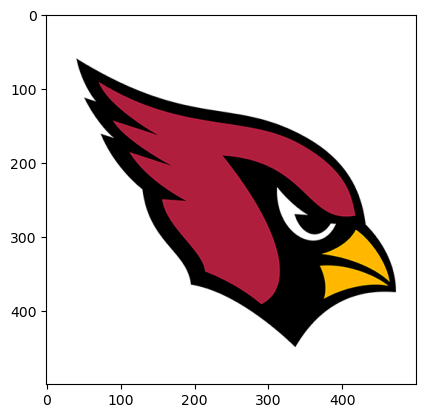

In [797]:
plt.imshow(logo_dict["ARI"])

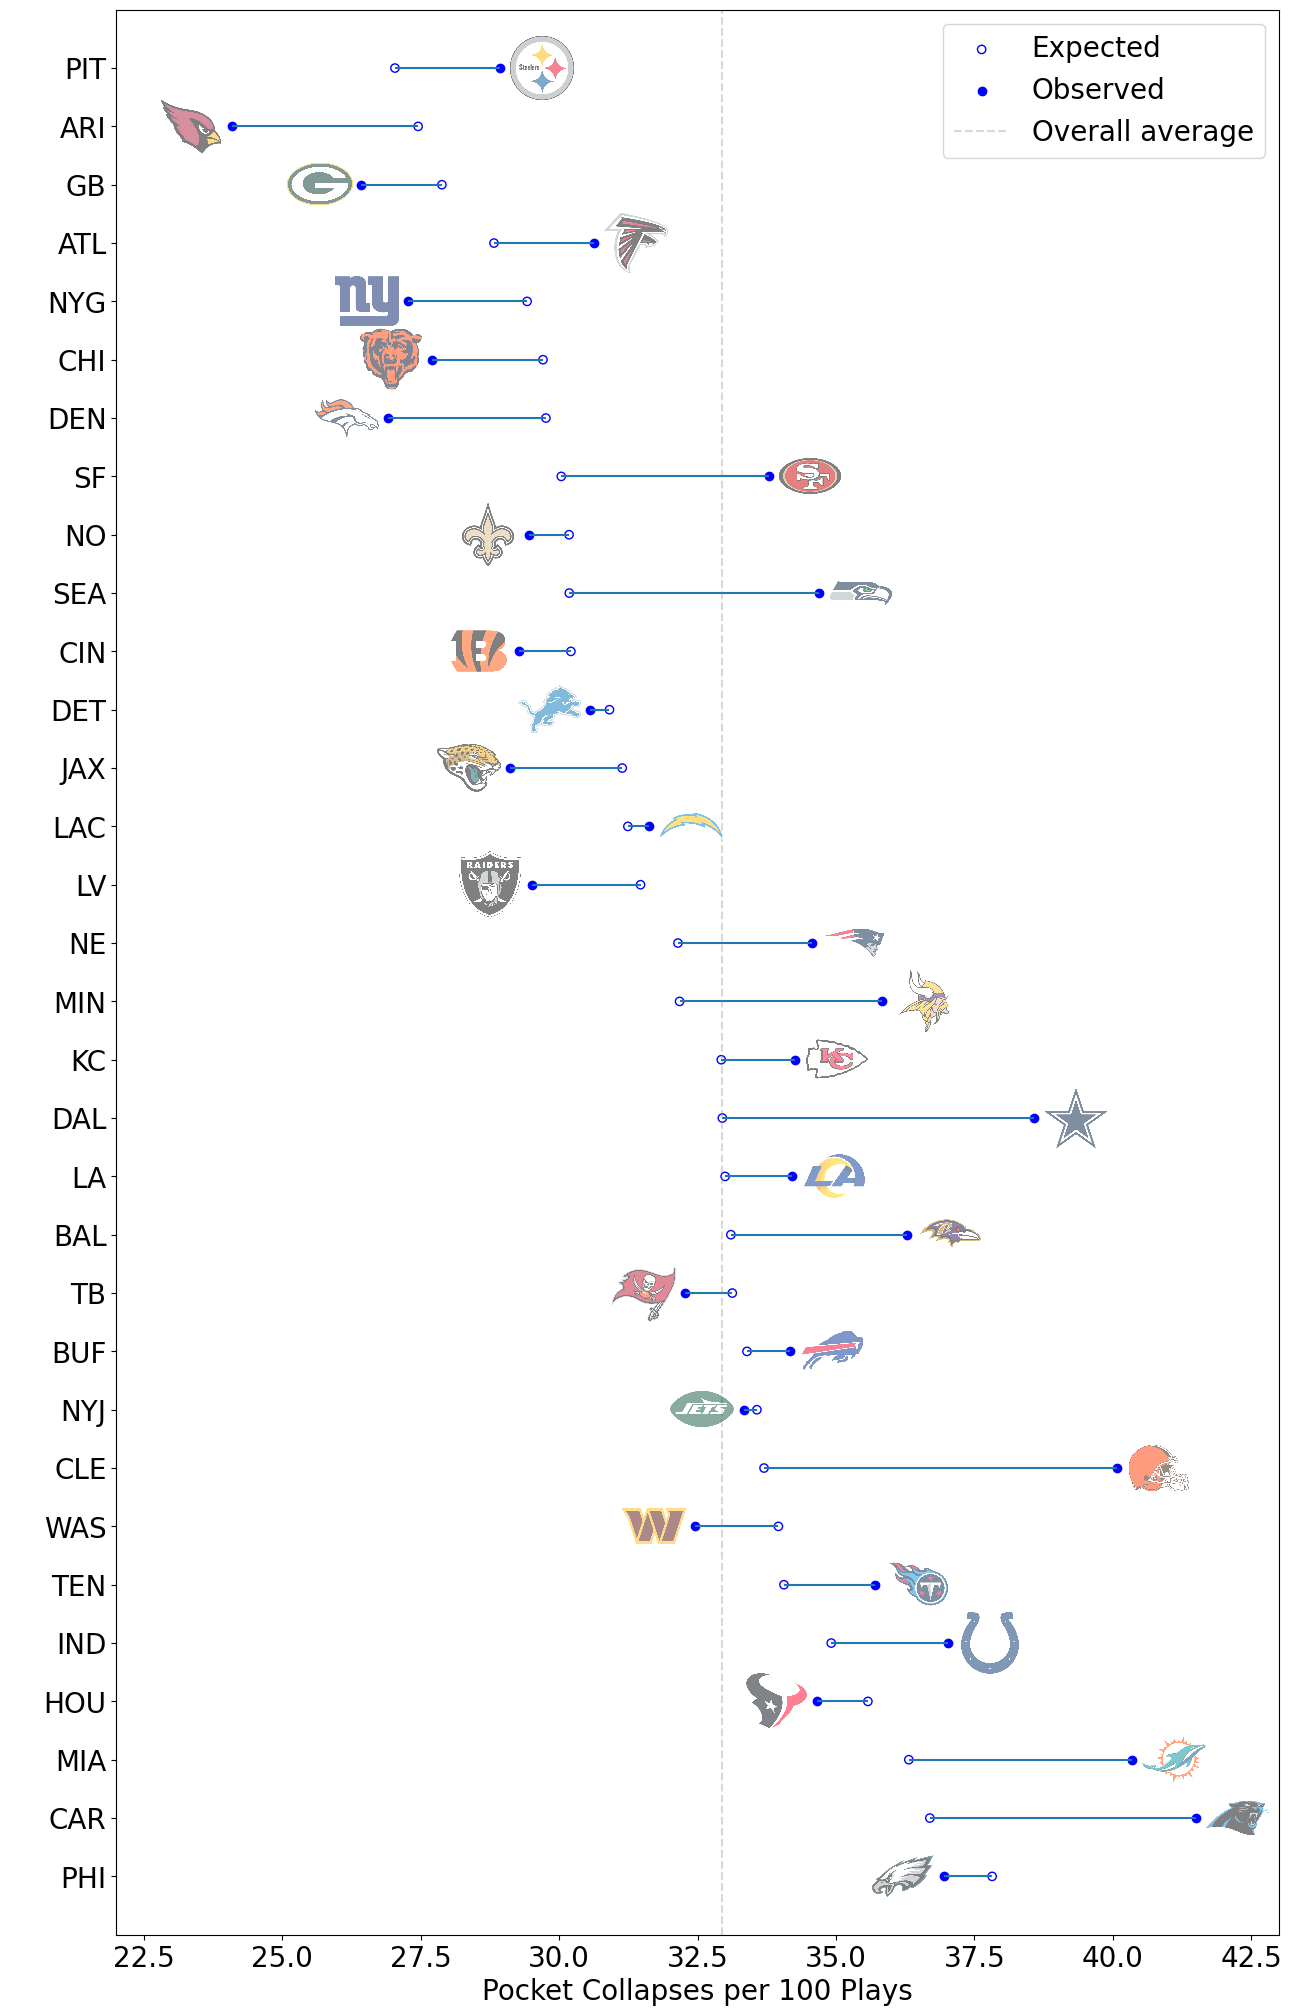

In [ ]:
plotdata = delta_def[delta_def.tau == 3].sort_values("cif_c", ascending=False)
with plt.style.context({"font.size": 20}):
    fig, ax = plt.subplots(figsize=(15, 25))

    for i, (ix, row) in enumerate(plotdata.iterrows()):
        abbr = row["defensiveTeam"]
        x0 = float(row["cif_c"] * 100)
        x1 = float(row["collapse_before_tau"] * 100)
        if x0 > x1:
            x = x1 - 0.75
        else:
            x = x1 + 0.75
        if abbr in logo_dict and os.path.exists(f"team_logos/{abbr}.png"):
            if abbr in ["LV", "GB"]:
                zm = 0.0125
            else:
                zm = 0.1
            im = OffsetImage(logo_dict[abbr], zoom=zm, alpha=0.5)
            ab = AnnotationBbox(
                im,
                (x, i),
                frameon=False,
                box_alignment=(0.5, 0.5),
                bboxprops=dict(alpha=0.5),
            )
            ax.add_artist(ab)
        else:
            ax.plot(x, i, "o", markersize=8)

    ax.hlines(
        y=np.arange(32),
        xmin=plotdata.cif_c.values * 100,
        xmax=plotdata.collapse_before_tau.values * 100,
    )

    ax.scatter(
        x=plotdata.cif_c.values * 100,
        y=np.arange(32),
        marker="o",
        label="Expected",
        color="blue",
        facecolor="none",
    )

    ax.scatter(
        x=plotdata.collapse_before_tau.values * 100,
        y=np.arange(32),
        marker="o",
        label="Observed",
        color="blue",
    )

    ax.vlines(
        [pred_surv_rate.collapse_before_tau_30_off.mean() * 100],
        -1,
        33,
        alpha=0.3,
        color="gray",
        linestyle="dashed",
        label="Overall average",
    )

    ax.set_yticks(np.arange(32))
    ax.set_yticklabels(plotdata.defensiveTeam.values)

    plt.legend()
    plt.ylim(-1, 32)
    plt.xlim(22, 43)
    plt.ylabel(" ")
    plt.xlabel("Pocket Collapses per 100 Plays")
    plt.show()

C:\Users\mschilling\AppData\Local\Temp\ipykernel_21088\2118892731.py:17: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



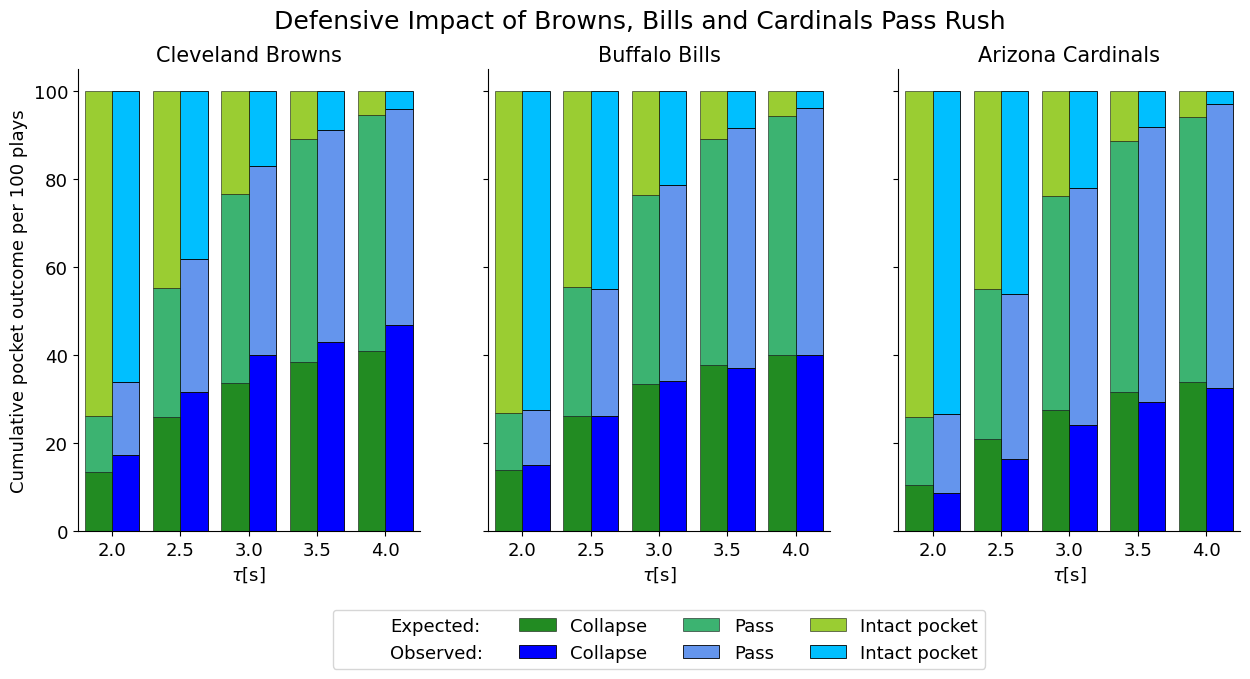

In [ ]:
with plt.style.context({"font.size": 13}):
    fig, ax = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

    delta_def.loc[
        delta_def.defensiveTeam == "CLE",
        ["collapse_before_tau", "pass_before_tau", "surv_tau", "tau"],
    ].set_index("tau").plot.bar(
        stacked=True,
        ax=ax[0],
        legend=False,
        width=0.4,
        rot=0,
        align="edge",
        color=["blue", "cornflowerblue", "deepskyblue"],
        edgecolor="k",
        linewidth=0.6,
    )
    delta_def.loc[
        delta_def.defensiveTeam == "BUF",
        ["collapse_before_tau", "pass_before_tau", "surv_tau", "tau"],
    ].set_index("tau").plot.bar(
        stacked=True,
        ax=ax[1],
        width=0.4,
        rot=0,
        align="edge",
        color=["blue", "cornflowerblue", "deepskyblue"],
        edgecolor="k",
        linewidth=0.6,
    )
    delta_def.loc[
        delta_def.defensiveTeam == "ARI",
        ["collapse_before_tau", "pass_before_tau", "surv_tau", "tau"],
    ].set_index("tau").plot.bar(
        stacked=True,
        ax=ax[2],
        legend=False,
        width=0.4,
        rot=0,
        align="edge",
        color=["blue", "cornflowerblue", "deepskyblue"],
        edgecolor="k",
        linewidth=0.6,
    )

    delta_def.loc[
        delta_def.defensiveTeam == "CLE", ["cif_c", "cif_p", "exp_surv", "tau"]
    ].set_index("tau").plot.bar(
        stacked=True,
        ax=ax[0],
        legend=False,
        width=-0.4,
        rot=0,
        align="edge",
        color=["forestgreen", "mediumseagreen", "yellowgreen"],
        edgecolor=(0, 0, 0, 0.6),
        linewidth=0.6,
    )
    delta_def.loc[
        delta_def.defensiveTeam == "BUF", ["cif_c", "cif_p", "exp_surv", "tau"]
    ].set_index("tau").plot.bar(
        stacked=True,
        ax=ax[1],
        width=-0.4,
        rot=0,
        align="edge",
        color=["forestgreen", "mediumseagreen", "yellowgreen"],
        edgecolor=(0, 0, 0, 0.6),
        linewidth=0.6,
    )
    delta_def.loc[
        delta_def.defensiveTeam == "ARI", ["cif_c", "cif_p", "exp_surv", "tau"]
    ].set_index("tau").plot.bar(
        stacked=True,
        ax=ax[2],
        legend=False,
        width=-0.4,
        rot=0,
        align="edge",
        color=["forestgreen", "mediumseagreen", "yellowgreen"],
        edgecolor=(0, 0, 0, 0.6),
        linewidth=0.6,
    )

    ax[0].set_title("Cleveland Browns", fontsize=15)
    ax[0].tick_params("x")
    ax[0].set_xlabel(r"$\tau$[s]")
    ax[0].spines["top"].set_visible(False)
    ax[0].spines["right"].set_visible(False)
    ax[0].set_yticklabels(["0", "20", "40", "60", "80", "100"])
    ax[0].set_ylabel("Cumulative pocket outcome per 100 plays")
    ax[0].set_xlim(-0.5, 4.5)
    # s0 = ax[0].secondary_xaxis(location = 0)
    # s0.set_xticks([-0.25, .25, .75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75, 4.25], ["Ex", "Obs"]*5)
    # s0.tick_params("x", length=0)

    ax[1].set_title("Buffalo Bills", fontsize=15)
    ax[1].tick_params("x")
    ax[1].set_xlabel(r"$\tau$[s]")
    ax[1].spines["top"].set_visible(False)
    ax[1].spines["right"].set_visible(False)
    lbls = ["Collapse", "Pass", "Intact pocket", "Collapse", "Pass", "Intact pocket"]
    row_titles = ["Expected:", "Observed:"]
    hdls, _ = ax[1].get_legend_handles_labels()
    dummy_handles = [
        plt.Line2D([], [], linestyle="", marker=""),
        plt.Line2D([], [], linestyle="", marker=""),
    ]
    hdls = hdls + dummy_handles
    lbls = lbls + row_titles
    ixs = [6, 7, 3, 0, 4, 1, 5, 2]
    ax[1].legend(
        [hdls[i] for i in ixs],
        [lbls[i] for i in ixs],
        loc="upper center",
        ncols=4,
        bbox_to_anchor=(0.5, -0.15),
    )

    ax[1].set_xlim(-0.5, 4.5)
    # s1 = ax[1].secondary_xaxis(location = 0)
    # s1.set_xticks([-0.25, .25, .75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75, 4.25], ["Ex", "Obs"]*5)
    # s1.tick_params("x", length=0)

    ax[2].set_title("Arizona Cardinals", fontsize=15)
    ax[2].tick_params("x")
    ax[2].set_xlabel(r"$\tau$[s]")
    ax[2].spines["top"].set_visible(False)
    ax[2].spines["right"].set_visible(False)

    ax[2].set_xlim(-0.5, 4.5)
    # s2 = ax[2].secondary_xaxis(location = 0)
    # s2.set_xticks([-0.25, .25, .75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75, 4.25], ["Ex", "Obs"]*5)
    # s2.tick_params("x", length=0)

    fig.suptitle(
        "Defensive Impact of Browns, Bills and Cardinals Pass Rush", fontsize=18
    )
    plt.savefig("stacked_outcomes.svg", dpi=600)

In [727]:
delta_def

,defensiveTeam,cif_p,cif_c,pass_before_tau,collapse_before_tau,surv_tau,tau,exp_surv
0,ARI,0.154160,0.104887,0.179592,0.085714,0.734694,2.0,0.740953
1,BUF,0.129612,0.138673,0.125000,0.150000,0.725000,2.0,0.731716
2,CLE,0.129461,0.133413,0.165992,0.174089,0.659919,2.0,0.737126
3,ARI,0.340881,0.208736,0.375510,0.163265,0.461224,2.5,0.450383
4,BUF,0.294175,0.261163,0.287500,0.262500,0.450000,2.5,0.444662
5,CLE,0.292946,0.259719,0.303644,0.315789,0.380567,2.5,0.447335
6,ARI,0.487966,0.274530,0.538776,0.240816,0.220408,3.0,0.237504
7,BUF,0.431272,0.333932,0.445833,0.341667,0.212500,3.0,0.234796
8,CLE,0.428215,0.337015,0.429150,0.400810,0.170040,3.0,0.234770
9,ARI,0.571683,0.316103,0.624490,0.293878,0.081633,3.5,0.112215


In [647]:
hdls, lbls = ax[1].get_legend_handles_labels()

In [654]:
ixs

[3, 0, 4, 1, 5, 2]

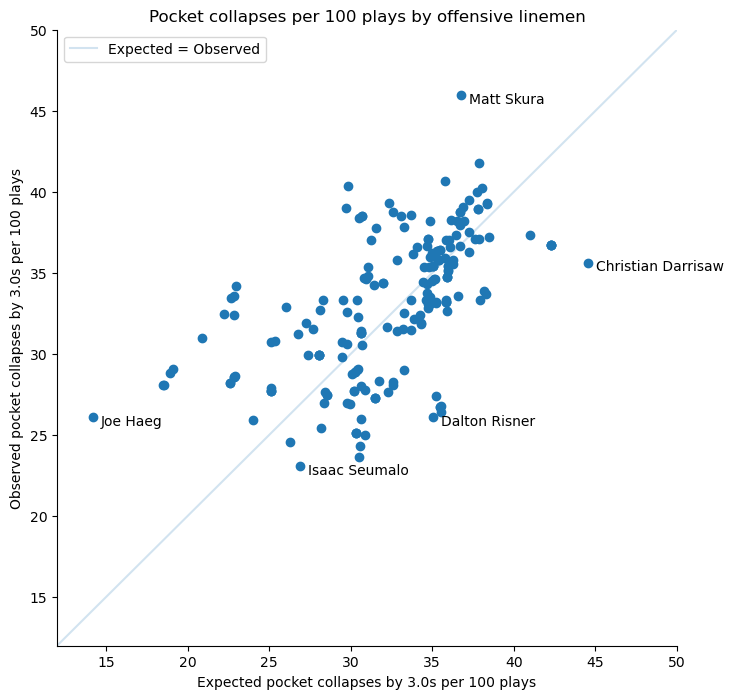

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(
    ppu.loc[
        (ppu.num_snaps > 50) & (ppu.officialPosition.isin(["C", "T", "G"])),
        f"cif_c_{ppu_tau}_def",
    ].values
    * 100,
    ppu.loc[
        (ppu.num_snaps > 50) & (ppu.officialPosition.isin(["C", "T", "G"])),
        f"collapse_before_tau_{ppu_tau}_def",
    ].values
    * 100,
)


# plt.axis("equal")
plt.xlabel(f"Expected pocket collapses by {ppu_tau/10:3.1f}s per 100 plays")
plt.ylabel(f"Observed pocket collapses by {ppu_tau/10:3.1f}s per 100 plays")
plt.title("Pocket collapses per 100 plays by offensive linemen")
plt.plot([0, 100], [0, 100], alpha=0.2, label="Expected = Observed")
plt.xlim(12, 50)
plt.ylim(12, 50)

annotation_df = pd.concat(
    [
        ppu.loc[(ppu.num_snaps > 50) & (ppu.officialPosition.isin(["C", "T", "G"]))]
        .sort_values(f"collapse_before_tau_{ppu_tau}_def", ascending=True)
        .head(1),
        ppu.loc[(ppu.num_snaps > 50) & (ppu.officialPosition.isin(["C", "T", "G"]))]
        .sort_values(f"collapse_before_tau_{ppu_tau}_def", ascending=False)
        .head(1),
        ppu.loc[(ppu.num_snaps > 50) & (ppu.officialPosition.isin(["C", "T", "G"]))]
        .sort_values(f"cif_c_{ppu_tau}_def", ascending=True)
        .head(1),
        ppu.loc[(ppu.num_snaps > 50) & (ppu.officialPosition.isin(["C", "T", "G"]))]
        .sort_values(f"cif_c_{ppu_tau}_def", ascending=True)
        .tail(1),
        ppu[ppu.displayName.isin(["Dalton Risner"])],
    ]
)

for ix, plyr in annotation_df.iterrows():
    plt.annotate(
        text=plyr["displayName"],
        xy=plyr[[f"cif_c_{ppu_tau}_def", f"collapse_before_tau_{ppu_tau}_def"]].values
        * 100
        + (0.5, -0.5),
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.legend()
plt.savefig("olines.svg", dpi=600)

In [ ]:
ppu_tau = 30
ppu_team_feat = "def"
ppu = (
    player_pocket_uptime.groupby("nflId")
    .agg(
        {
            f"cif_p_{ppu_tau}_{ppu_team_feat}": "mean",
            f"cif_c_{ppu_tau}_{ppu_team_feat}": "mean",
            f"pass_before_tau_{ppu_tau}_{ppu_team_feat}": "mean",
            f"pass_residual_{ppu_tau}_{ppu_team_feat}": "mean",
            f"collapse_before_tau_{ppu_tau}_{ppu_team_feat}": "mean",
            f"collapse_residual_{ppu_tau}_{ppu_team_feat}": "mean",
            f"surv_tau_{ppu_tau}_{ppu_team_feat}": "mean",
            f"surv_residual_{ppu_tau}_{ppu_team_feat}": "mean",
            f"playId": "count",
            "defensiveTeam": pd.Series.mode,
            "possessionTeam": pd.Series.mode,
        }
    )
    .rename(columns={"playId": "num_snaps"})
    .sort_values(f"collapse_residual_{ppu_tau}_{ppu_team_feat}", ascending=True)
    .reset_index()
    .merge(players, on="nflId")
    .drop(columns=["collegeName", "height", "weight", "birthDate"])
)

In [ ]:
ppu[
    (ppu.num_snaps > 50) & (ppu.officialPosition.isin(["C", "T", "G", "TE", "RB"]))
].sort_values(f"collapse_residual_{ppu_tau}_{ppu_team_feat}", ascending=True).head(
    25
).drop(
    columns=["nflId", "defensiveTeam"]
)[
    [
        "displayName",
        "possessionTeam",
        f"collapse_residual_{ppu_tau}_{ppu_team_feat}",
        f"cif_c_{ppu_tau}_{ppu_team_feat}",
        f"collapse_before_tau_{ppu_tau}_{ppu_team_feat}",
    ]
]

,displayName,possessionTeam,collapse_residual_30_def,cif_c_30_def,collapse_before_tau_30_def
189,Graham Glasgow,DEN,-0.091287,0.355536,0.264249
198,Dalton Risner,DEN,-0.089564,0.350433,0.260870
202,Christian Darrisaw,MIN,-0.088823,0.445144,0.356322
208,Garett Bolles,DEN,-0.087952,0.355610,0.267658
210,Lloyd Cushenberry,DEN,-0.087383,0.354531,0.267148
211,Bobby Massie,DEN,-0.087383,0.354531,0.267148
229,Netane Muti,DEN,-0.078412,0.352222,0.273810
249,Elijah Wilkinson,CHI,-0.068872,0.305235,0.236364
268,Jack Conklin,CLE,-0.062501,0.305556,0.243056
284,Elgton Jenkins,GB,-0.058581,0.308581,0.250000


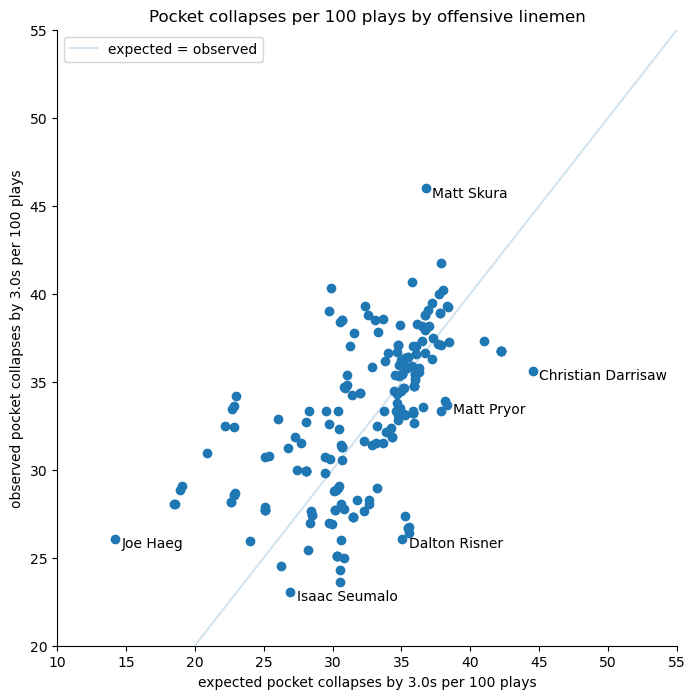

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(
    ppu.loc[
        (ppu.num_snaps > 50) & (ppu.officialPosition.isin(["C", "T", "G"])),
        f"cif_c_{ppu_tau}_def",
    ].values
    * 100,
    ppu.loc[
        (ppu.num_snaps > 50) & (ppu.officialPosition.isin(["C", "T", "G"])),
        f"collapse_before_tau_{ppu_tau}_def",
    ].values
    * 100,
)


# plt.axis("equal")
plt.xlabel(f"expected pocket collapses by {ppu_tau:3.1f}s per 100 plays")
plt.ylabel(f"observed pocket collapses by {ppu_tau:3.1f}s per 100 plays")
plt.title("Pocket collapses per 100 plays by offensive linemen")
plt.plot([0, 100], [0, 100], alpha=0.2, label="expected = observed")
plt.xlim(10, 55)
plt.ylim(20, 55)

annotation_df = pd.concat(
    [
        ppu.loc[(ppu.num_snaps > 50) & (ppu.officialPosition.isin(["C", "T", "G"]))]
        .sort_values(f"collapse_before_tau_{ppu_tau}_def", ascending=True)
        .head(1),
        ppu.loc[(ppu.num_snaps > 50) & (ppu.officialPosition.isin(["C", "T", "G"]))]
        .sort_values(f"collapse_before_tau_{ppu_tau}_def", ascending=False)
        .head(1),
        ppu.loc[(ppu.num_snaps > 50) & (ppu.officialPosition.isin(["C", "T", "G"]))]
        .sort_values(f"cif_c_{ppu_tau}_def", ascending=True)
        .head(1),
        ppu.loc[(ppu.num_snaps > 50) & (ppu.officialPosition.isin(["C", "T", "G"]))]
        .sort_values(f"cif_c_{ppu_tau}_def", ascending=True)
        .tail(1),
        ppu[ppu.displayName.isin(["Matt Pryor", "Dalton Risner"])],
    ]
)

for ix, plyr in annotation_df.iterrows():
    plt.annotate(
        text=plyr["displayName"],
        xy=plyr[[f"cif_c_{ppu_tau}_def", f"collapse_before_tau_{ppu_tau}_def"]].values
        * 100
        + (0.5, -0.5),
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.legend()
plt.savefig("olines.svg")

In [ ]:
ppu[
    (ppu.num_snaps > 100) & (ppu.officialPosition.isin(["DT", "OLB", "ILB", "DE"]))
].sort_values(f"collapse_residual_{ppu_tau}_{ppu_team_feat}", ascending=0).head(
    25
).drop(
    columns=["nflId", "possessionTeam"]
)

,cif_p_25_def,cif_c_25_def,pass_before_tau_25_def,pass_residual_25_def,collapse_before_tau_25_def,collapse_residual_25_def,surv_tau_25_def,surv_residual_25_def,num_snaps,defensiveTeam,officialPosition,displayName
1041,0.295523,0.279168,0.323529,0.028007,0.352941,0.073774,0.323529,-0.101780,102,DAL,OLB,Micah Parsons
1034,0.265757,0.212828,0.240223,-0.025533,0.284916,0.072088,0.474860,-0.046555,179,ATL,DT,Grady Jarrett
1005,0.327014,0.222715,0.387387,0.060373,0.279279,0.056564,0.333333,-0.116937,111,JAX,DT,Malcom Brown
1000,0.251441,0.257555,0.276923,0.025482,0.312821,0.055265,0.410256,-0.080747,195,TEN,DE,Denico Autry
986,0.260294,0.267374,0.274336,0.014042,0.318584,0.051210,0.407080,-0.065252,113,KC,DE,Frank Clark
983,0.297926,0.271370,0.315789,0.017863,0.321637,0.050267,0.362573,-0.068131,171,DAL,DT,Osa Odighizuwa
982,0.340399,0.209558,0.381679,0.041280,0.259542,0.049984,0.358779,-0.091264,131,PIT,OLB,Alex Highsmith
979,0.245539,0.206630,0.218182,-0.027357,0.254545,0.047916,0.527273,-0.020558,110,ATL,OLB,Dante Fowler
955,0.304017,0.280503,0.298343,-0.005674,0.325967,0.045464,0.375691,-0.039789,181,CLE,DT,Malik Jackson
945,0.289985,0.270317,0.297872,0.007887,0.312057,0.041739,0.390071,-0.049627,141,DAL,DE,Randy Gregory


In [ ]:
ppu[ppu.displayName == "Maxx Crosby"]

,nflId,cif_p_25_def,cif_c_25_def,pass_before_tau_25_def,pass_residual_25_def,collapse_before_tau_25_def,collapse_residual_25_def,surv_tau_25_def,surv_residual_25_def,num_snaps,defensiveTeam,possessionTeam,officialPosition,displayName
701,47889,0.278968,0.229312,0.328431,0.049463,0.235294,0.005982,0.436275,-0.055445,204,LV,DEN,DE,Maxx Crosby


In [ ]:
ppu[ppu.displayName == "Aaron Donald"]

,nflId,cif_p_25_def,cif_c_25_def,pass_before_tau_25_def,pass_residual_25_def,collapse_before_tau_25_def,collapse_residual_25_def,surv_tau_25_def,surv_residual_25_def,num_snaps,defensiveTeam,possessionTeam,officialPosition,displayName
732,41239,0.289881,0.281134,0.376518,0.086637,0.291498,0.010364,0.331984,-0.097002,247,LA,TB,DT,Aaron Donald


In [ ]:
fig = px.scatter(
    ppu[(ppu.num_snaps > 100) & (ppu.officialPosition.isin(["C", "T", "G"]))],
    x="pass_residual",
    y="surv_residual",
    size="num_snaps",
    height=600,
    hover_data=[
        "displayName",
        "possessionTeam",
        "officialPosition",
        "cif_p",
        "cif_c",
        "pass_residual",
    ],
)
fig.show()

In [206]:
fig = px.scatter(
    ppu[(ppu.num_snaps > 100) & (ppu.officialPosition.isin(["C", "T", "G"]))],
    x="collapse_residual",
    y="pass_residual",
    size="num_snaps",
    height=600,
    hover_data=[
        "displayName",
        "possessionTeam",
        "officialPosition",
        "cif_p",
        "cif_c",
        "pass_residual",
    ],
)
fig.show()

Text(0, 0.5, 'pocket survival rate over expectation')

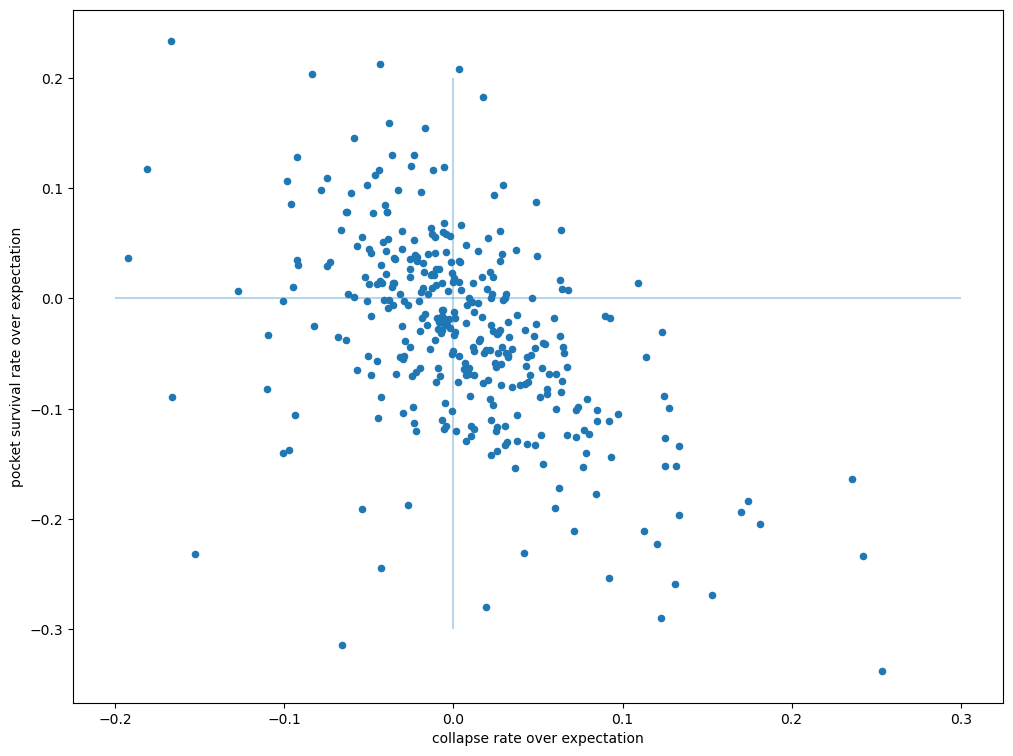

In [ ]:
ppu[
    (ppu.num_snaps > 10) & (ppu.officialPosition.isin(["DT", "OLB", "ILB", "DE"]))
].plot.scatter(x="collapse_residual", y="surv_residual", figsize=(12, 9))
plt.hlines([0], xmin=-0.2, xmax=0.3, alpha=0.3)
plt.vlines([0], ymin=-0.3, ymax=0.2, alpha=0.3)
plt.xlabel("collapse rate over expectation")
plt.ylabel("pocket survival rate over expectation")

##### In this plot, we can see the following: the collapse rate compared to the expectation tells us, how much more often the pocket collapsed, the pocket survival rate over expectation tells us how much more often (or less often) the pocket survived past 3.0 seconds. Combining this allows us to identify players, which are collapsing the pocket at a higher rate and how much of that translates to a loss in pocket survival, as opposed to passing.

In [ ]:
import plotly.express as px

pff_pb_df = pd.read_csv("offense_pass_blocking.csv")
pff_pr_df = pd.read_csv("pass_rush_summary.csv")

In [209]:
pr_comp = pff_pr_df.merge(ppu, how="inner", left_on="player", right_on="displayName")
print(pr_comp.shape)
pb_comp = pff_pb_df.merge(ppu, how="inner", left_on="player", right_on="displayName")
print(pb_comp.shape)

(644, 49)
(539, 45)


<Axes: xlabel='surv_residual', ylabel='grades_pass_block'>

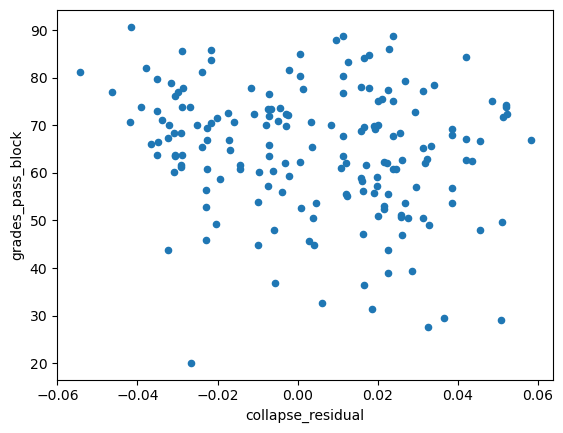

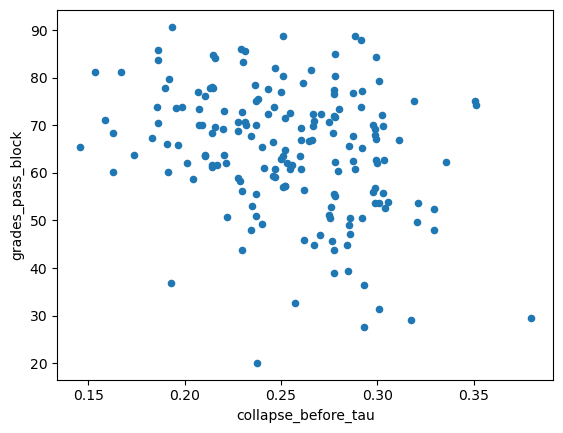

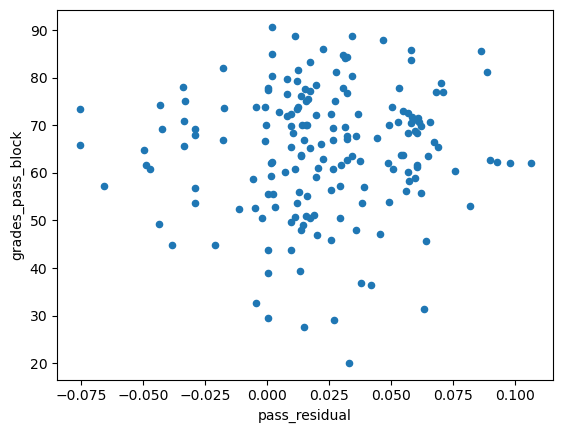

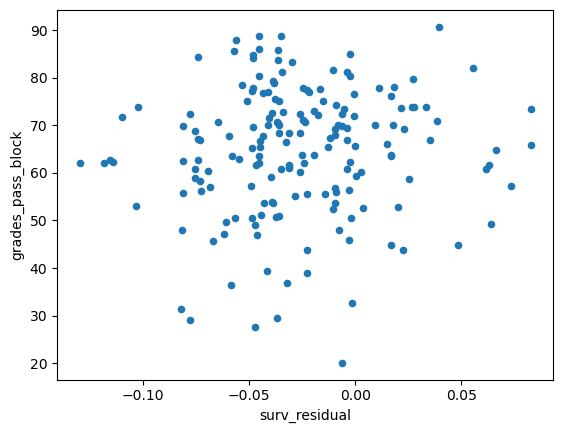

In [ ]:
pb_comp[pb_comp.num_snaps > 100].plot.scatter(
    y="grades_pass_block", x="collapse_residual"
)
pb_comp[pb_comp.num_snaps > 100].plot.scatter(
    y="grades_pass_block", x="collapse_before_tau"
)
pb_comp[pb_comp.num_snaps > 100].plot.scatter(y="grades_pass_block", x="pass_residual")
pb_comp[pb_comp.num_snaps > 100].plot.scatter(y="grades_pass_block", x="surv_residual")

In [ ]:
pr_comp.loc[
    pr_comp.num_snaps > 50,
    [
        "pass_rush_win_rate",
        "grades_pass_rush_defense",
        "cif_p",
        "pass_before_tau",
        "pass_residual",
        "cif_c",
        "collapse_before_tau",
        "collapse_residual",
        "surv_tau",
        "surv_residual",
    ],
].corr()

,pass_rush_win_rate,grades_pass_rush_defense,cif_p,pass_before_tau,pass_residual,cif_c,collapse_before_tau,collapse_residual,surv_tau,surv_residual
pass_rush_win_rate,1.000000,0.874376,-0.091266,0.066049,0.125355,0.052852,0.028905,-0.000658,-0.073198,-0.101676
grades_pass_rush_defense,0.874376,1.000000,-0.127087,0.108640,0.192434,0.118274,0.052460,-0.018815,-0.124120,-0.145405
cif_p,-0.091266,-0.127087,1.000000,0.395978,-0.172423,-0.547160,-0.419851,-0.164300,0.010143,0.238942
pass_before_tau,0.066049,0.108640,0.395978,1.000000,0.836231,-0.126691,-0.150184,-0.113194,-0.663287,-0.613010
pass_residual,0.125355,0.192434,-0.172423,0.836231,1.000000,0.190857,0.089627,-0.023305,-0.717569,-0.800273
cif_c,0.052852,0.118274,-0.547160,-0.126691,0.190857,1.000000,0.730598,0.248169,-0.454592,-0.304257
collapse_before_tau,0.028905,0.052460,-0.419851,-0.150184,0.089627,0.730598,1.000000,0.842759,-0.640262,-0.578465
collapse_residual,-0.000658,-0.018815,-0.164300,-0.113194,-0.023305,0.248169,0.842759,1.000000,-0.549979,-0.580822
surv_tau,-0.073198,-0.124120,0.010143,-0.663287,-0.717569,-0.454592,-0.640262,-0.549979,1.000000,0.914159
surv_residual,-0.101676,-0.145405,0.238942,-0.613010,-0.800273,-0.304257,-0.578465,-0.580822,0.914159,1.000000


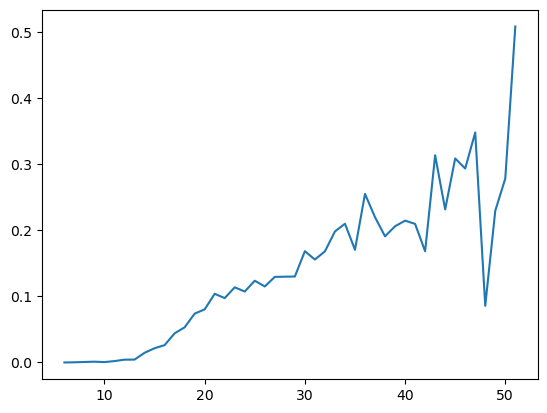

In [ ]:
cph_off.predict_cumulative_hazard(X[17:18]).iloc[:45].diff().fillna(0.0).plot(
    label=False
)
plt.show()

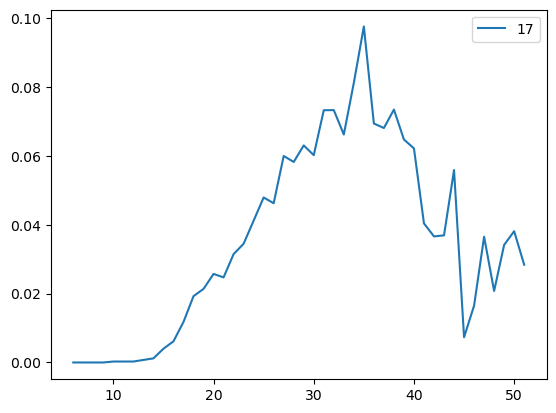

In [ ]:
pass_cox_off.predict_cumulative_hazard(X[17:18]).iloc[:45].diff().fillna(0.0).plot(
    label=False
)
plt.show()

In [ ]:
pb_comp.loc[
    pb_comp.num_snaps > 100,
    [
        "grades_pass_block",
        "cif_p",
        "pass_before_tau",
        "pass_residual",
        "cif_c",
        "collapse_before_tau",
        "collapse_residual",
        "surv_tau",
        "surv_residual",
    ],
].corr()

,grades_pass_block,cif_p,pass_before_tau,pass_residual,cif_c,collapse_before_tau,collapse_residual,surv_tau,surv_residual
grades_pass_block,1.000000,0.025171,0.057189,0.063285,-0.219099,-0.293645,-0.199024,0.133447,0.076614
cif_p,0.025171,1.000000,0.821243,-0.027472,-0.167595,-0.039594,0.152527,-0.684481,-0.076746
pass_before_tau,0.057189,0.821243,1.000000,0.547802,-0.190060,-0.123938,0.042784,-0.786321,-0.497854
pass_residual,0.063285,-0.027472,0.547802,1.000000,-0.087239,-0.159079,-0.148687,-0.373974,-0.759684
cif_c,-0.219099,-0.167595,-0.190060,-0.087239,1.000000,0.794646,0.009691,-0.330648,0.068432
collapse_before_tau,-0.293645,-0.039594,-0.123938,-0.159079,0.794646,1.000000,0.614745,-0.515600,-0.267853
collapse_residual,-0.199024,0.152527,0.042784,-0.148687,0.009691,0.614745,1.000000,-0.419695,-0.530108
surv_tau,0.133447,-0.684481,-0.786321,-0.373974,-0.330648,-0.515600,-0.419695,1.000000,0.596660
surv_residual,0.076614,-0.076746,-0.497854,-0.759684,0.068432,-0.267853,-0.530108,0.596660,1.000000
